In [1]:
import numpy as np
import skexplain
import pickle
import seaborn as sns
import plotting_config
import itertools
import scipy
import xarray as xr
import matplotlib as mpl
import matplotlib.colors as mcolors
from sklearn.ensemble import RandomForestRegressor

from time_series_deconfounder import *
from utils.evaluation_utils import load_data, save_data
from loguru import logger

2026-01-16 07:16:11.086747: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-16 07:16:11.139159: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-16 07:16:11.880568: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
INFO:Using GPU with memory growth
2026-01-16 07:16:12.963783: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46681 MB memory:  

Number of devices: 1


统一大图代码

In [2]:
from matplotlib import gridspec
from matplotlib.gridspec import GridSpecFromSubplotSpec

In [3]:
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 6,          # Nature: 5–7 pt
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

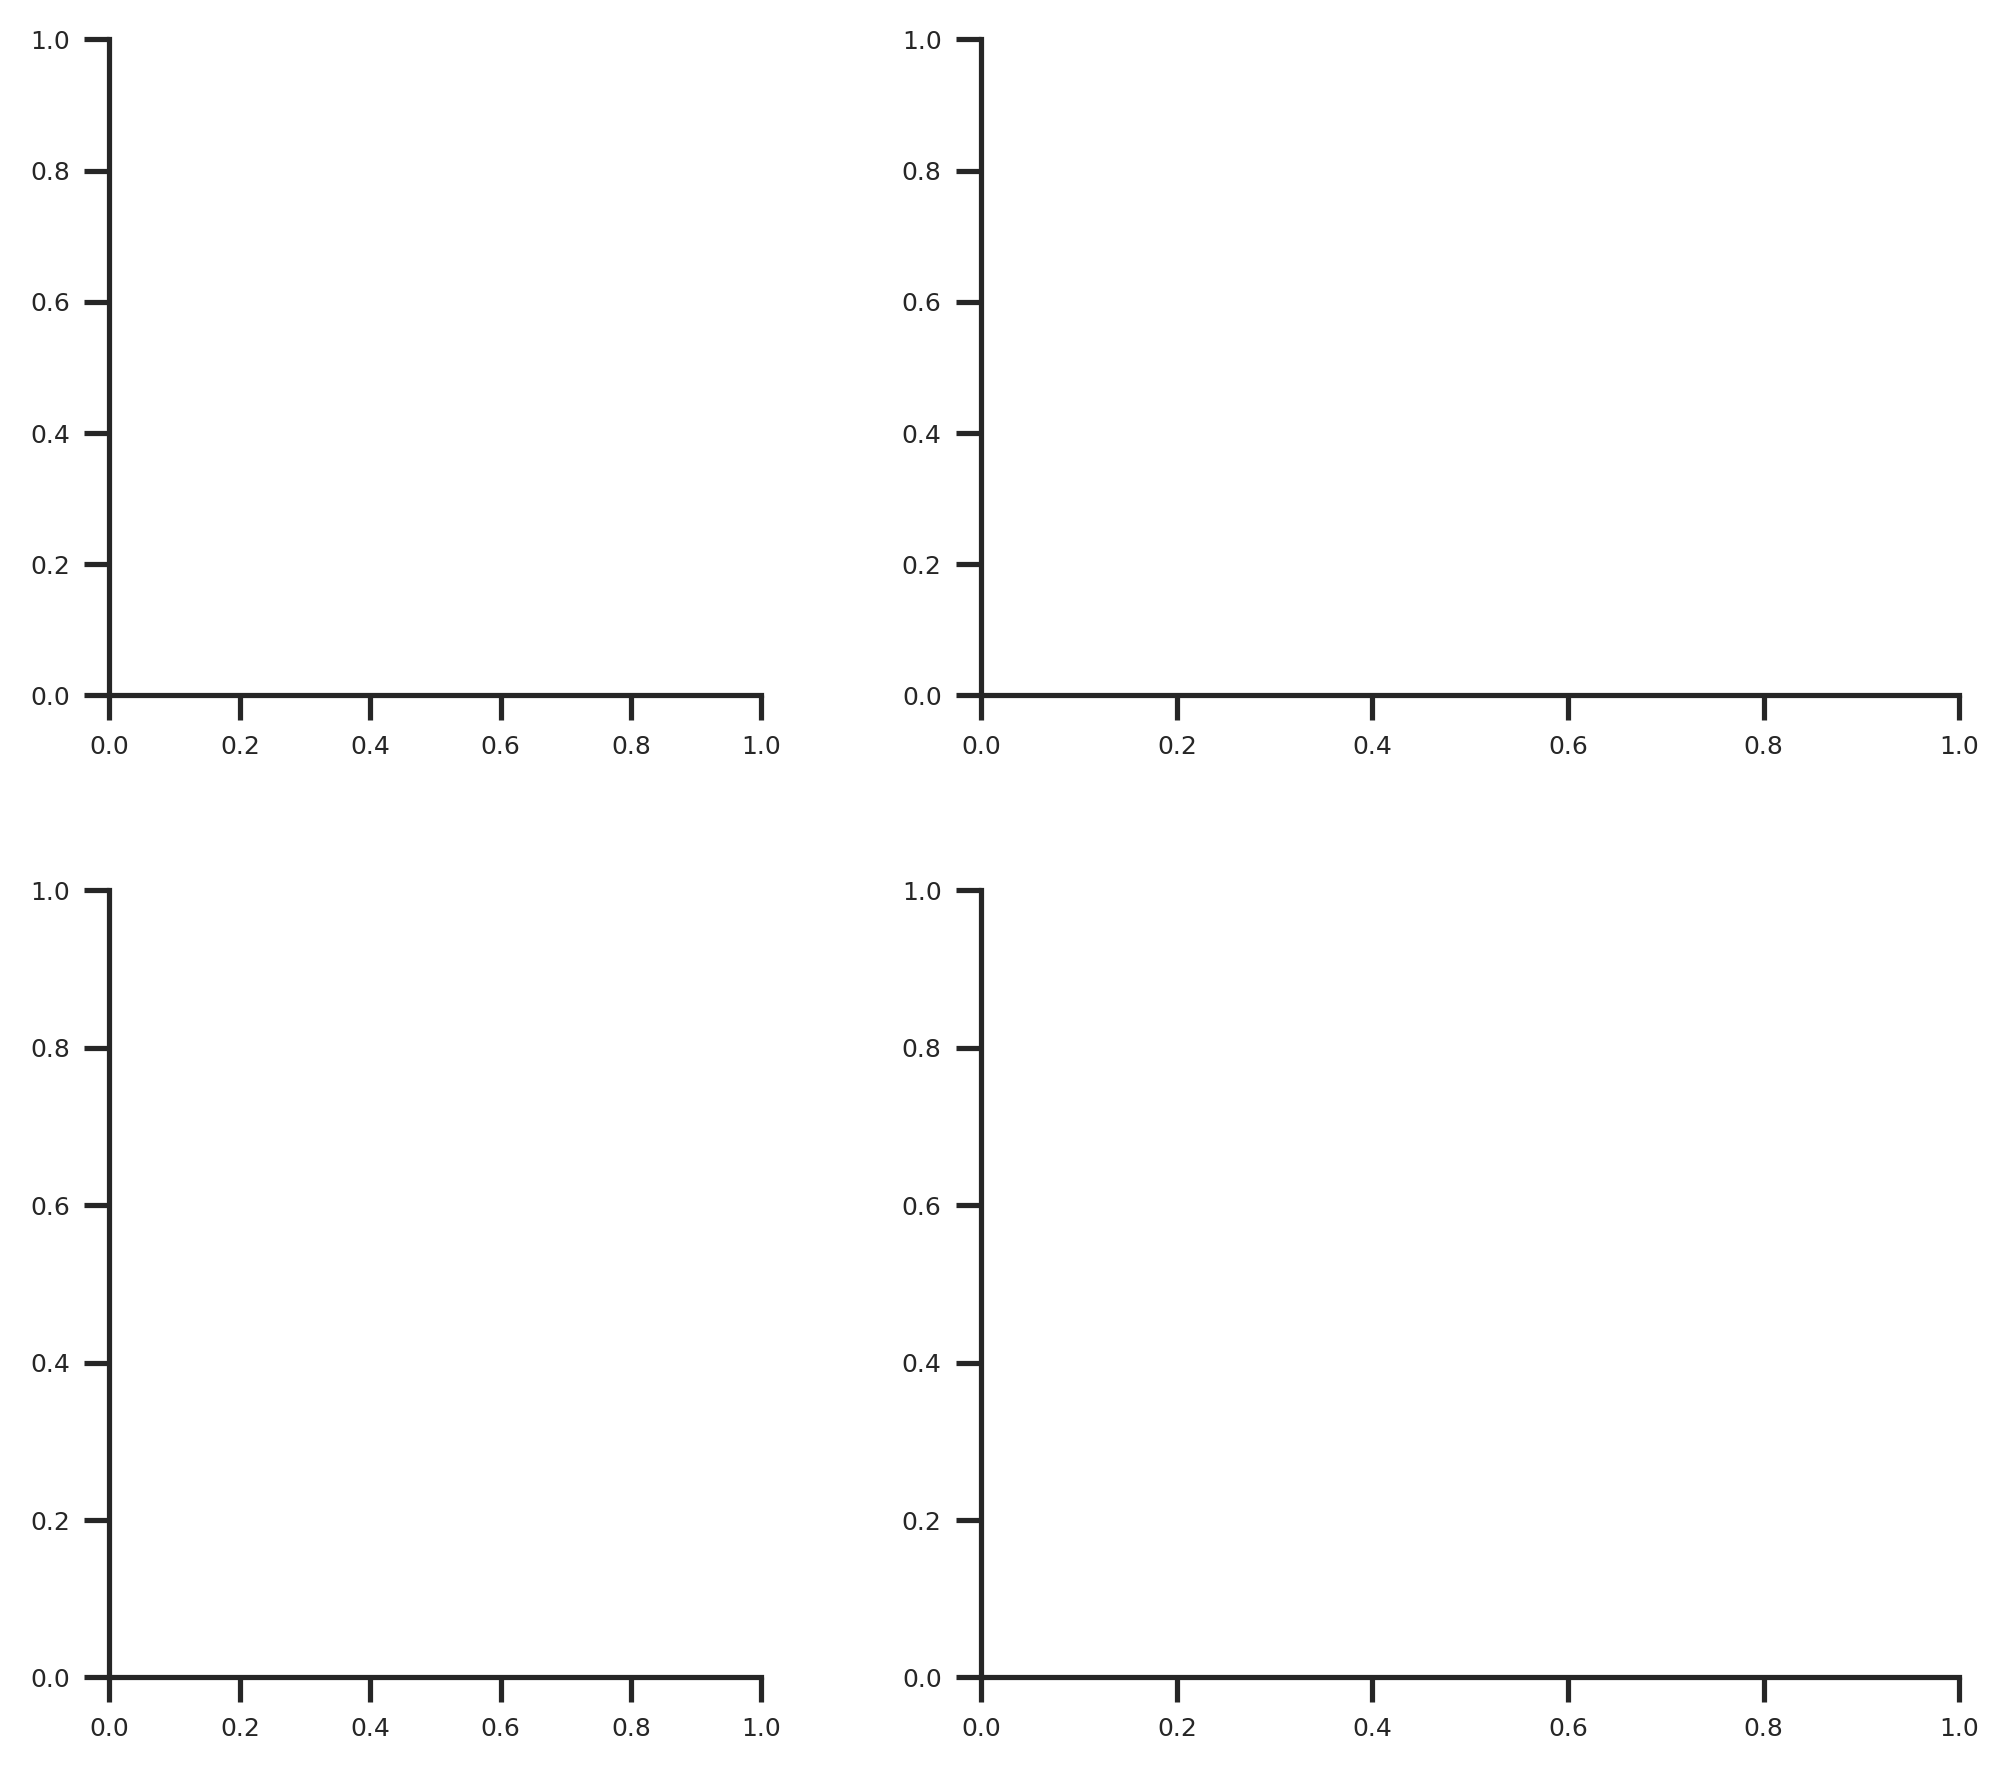

In [4]:
fig = plt.figure(figsize=(180/25.4, 6.5), dpi=300)

gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    height_ratios=[1, 1.2],
    width_ratios=[1, 1.5],
    hspace=0.27,
    wspace=0.27
)

fig.subplots_adjust(
    left=0.11,
    right=0.98,
    bottom=0.10,
    top=0.94
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

# figure 2a
基于ALE variance的特征重要性：量化特征的整体重要程度，提供特征排名，用于特征选择和模型简化
- 高方差：表示特征在不同取值下对模型预测的影响变化很大，说明该特征很重要
- 低方差：表示特征对模型预测的影响相对稳定，重要性较低
- 零方差：表示特征对模型预测没有影响

## 计算生成

In [5]:
# 数据导入与预处理
dataset = load_data("../data/sample_3w2_add.h5")

index_to_remove = dataset['covariates'].shape[2] - 5
dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

index_to_remove = dataset['covariates'].shape[2] - 5
dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

# 模型编号
exp_name = "base_model_optimal_v2"

# 定义要计算的特征
features = ['conformity', 'gender','age','income','weekday_0','weekday_1','weekday_2','weekday_3','weekday_4', 'weekday_5', 'weekday_6',
            'voluntary','festivals','year_0','year_1','year_2','edu','married','dist_yes','density','temperature','percipit','E1','E2']

KeyboardInterrupt: 

In [3]:
# 对每个特征分别计算其ale
def compute_ale_for_features(
    dataset,
    features,
    exp_name,
    *,
    n_sample=1000,
    treatment_feature_name="conformity",
    covariate_tensor_key="covariates",
    treatment_tensor_key="treatments",
):
    """
    返回：
      - ALE_1ST:        {feature -> np.ndarray (n_bins 或 [n_bootstrap, n_bins])}
      - ALE_1ST_bin:    {feature -> np.ndarray (分箱中心值)}
      - feature_values: {feature -> np.ndarray (原始特征取值, shape [N, T] 或已拉平)}
    """

    ALE_1ST, ALE_1ST_bin, feature_values = {}, {}, {}

    for feature in features:
    # for feature in ['conformity', 'gender','age','income','voluntary','festivals','edu','married','density','temperature','percipit']:
        # n_bootstrap = 1
        sub_dataset = dataset_sampling(dataset, n_sample)
        # for _ in range(n_bootstrap):
        _, ale_1st, quantiles_tmp = compute_ale(sub_dataset, f'rmsn_{exp_name}', b_use_predicted_confounders=False, features = [feature])
        ALE_1ST[feature] = ale_1st
        
        quantiles_tmp = (quantiles_tmp[:-1] + quantiles_tmp[1:]) / 2
        ALE_1ST_bin[feature] = quantiles_tmp
        
        if feature == 'conformity':
            feature_values[feature]=dataset['treatments'][:,:,0]
        else:
            feature_index = features.index(feature) - 1
            feature_value = dataset['covariates'][:,:,feature_index]
            # feature_values[feature] = np.repeat(feature_value, 3, axis=0)
            feature_values[feature] = feature_value
            
            
    for key in ALE_1ST.keys():
        ALE_1ST[key] = np.array(ALE_1ST[key])

    for key in ALE_1ST_bin.keys():
        ALE_1ST_bin[key] = np.array(ALE_1ST_bin[key])

    for key in feature_values.keys():
        feature_values[key] = np.array(feature_values[key])
    
    return ALE_1ST, ALE_1ST_bin, feature_values



In [4]:
# data transformation
def build_ale_xarray_dataset(
    ALE_1ST, ALE_1ST_bin, feature_values, features, *, model_name="RNN_Model"
):
# model_name = 'RNN_Model'

    data_vars = {}
    for feature in features:
    # for feature in ['conformity', 'gender','age','income','voluntary','festivals','edu','married','density','temperature','percipit']:
        ale = ALE_1ST[feature]
        if ale.ndim == 1:
            ale = ale[np.newaxis, :]
        data_vars[f"{feature}__{model_name}__ale"] = (["n_bootstrap", f"n_bins__{feature}"], ale)
        
        quantiles = ALE_1ST_bin[feature]
        data_vars[f"{feature}__bin_values"] = ([f"n_bins__{feature}"], quantiles)
        
        feature_value = feature_values[feature]
        if feature_value.ndim > 1:
            flattened_value = feature_value.reshape(-1)
        else:
            flattened_value = feature_value
        data_vars[feature] = (["n_X"], flattened_value)

        
    ale_1d_dataset = xr.Dataset(
        data_vars=data_vars,
        #coords={
        #    "n_bootstrap": np.arange(ale.shape[0]), 
        #    f"n_bins__{feature_name}": np.arange(quantiles.shape[0]),  
        #    "n_X": np.arange(flattened_values.shape[0]),  
        #},
        attrs={
            "estimator_output": "raw",
            "estimators used": [model_name],
            "method": "ale",
            "dimension": "1D",
            "features used": features,
        }
    )

    for key in feature_values.keys():
        if feature_values[key].ndim > 1:
            feature_values[key] = feature_values[key].reshape(-1)
        feature_values[key] = pd.Series(feature_values[key])

    X = pd.DataFrame()
    X = X.assign(**feature_values)

    y = pd.Series(dataset['outcomes'][:,:,0].flatten())

    return ale_1d_dataset, X, y


In [5]:
def ale_variance_and_plot(
    X,
    y,
    ale_1d_dataset,
    *,
    model_name="RNN_Model",
    extra_estimators=(),
    figsize=(8, 6),
    ax=None,
    show_topN=None, # take None or [start:stop]
    save_path="./figures/fig_1a_feature_importance_all_var.png",
    show=False,
):
    """
    执行：
      1) 计算 ALE 方差（特征重要性）
      2) 绘制水平条形图并保存
    返回：
      - ale_var_result: skexplain 的结果字典
    """
    estimators = (model_name, *extra_estimators)
    explainer = skexplain.ExplainToolkit(estimators=estimators, X=X, y=y)
    ale_var_result = explainer.ale_variance(ale=ale_1d_dataset)

    # 取排名和分数
    features_ale_var = ale_var_result['ale_variance_rankings__RNN_Model']
    scores_ale_var = ale_var_result['ale_variance_scores__RNN_Model'][:,0]

    if show_topN is not None:
        if isinstance(show_topN, (list, tuple)) and len(show_topN) == 2:
            start, stop = show_topN
            features_ale_var = features_ale_var[start:stop]
            scores_ale_var = scores_ale_var[start:stop]
        else:
            raise ValueError("show_topN 必须是形如 [start, stop] 的列表或元组，例如 [0, 10]")

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    # 画图（保持你原有风格）
    palette = sns.cubehelix_palette(n_colors=len(features_ale_var), reverse=True)

    bars = ax.barh(features_ale_var, scores_ale_var, color=palette)

    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f"{width:.3f}", va='center', ha='left')

    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance')
    ax.set_xlim(0, float(scores_ale_var.max()) * 1.1 if len(scores_ale_var) else 1.0)
    ax.grid(True, linestyle='--', linewidth=0.5, which='major', axis='x')
    # ax.tick_params(axis='both', which='major', labelsize=10, tick1On=False, tick2On=False)
    ax.tick_params(axis='both', which='major', tick1On=False, tick2On=False)
    ax.spines['bottom'].set_visible(False)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
    if show:
        plt.show()

    return ale_var_result, fig, ax

2026-01-13 05:45:38.176 | DEBUG    | ale:_first_order_ale_quant:394 - Quantiles: [ 0.         3.2124264  3.6727045  3.9696817  4.201267   4.3909993
  4.556315   4.707239   4.8478928  4.9827747  5.11757    5.2520823
  5.3870864  5.527382   5.670992   5.8355546  6.0204177  6.2424
  6.538466   7.0179014 12.4287   ].


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 0it [00:00, ?it/s]2026-01-13 05:45:39.717265: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
Predicting rnn_propensity_weighted: 16it [00:01, 11.51it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 17.24it/s]
2026-01-13 05:45:42.839 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [ 0.         3.2124264  3.6727045  3.9696817  4.201267   4.3909993
  4.556315   4.707239   4.8478928  4.9827747  5.11757    5.2520823
  5.3870864  5.527382   5.670992   5.8355546  6.0204177  6.2424
  6.538466   7.0179014 12.4287   ].


...

INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 17.52it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 17.11it/s]
2026-01-13 05:47:46.534 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [0. 1.].


[0.5]


Degrees of freedom <= 0 for slice.


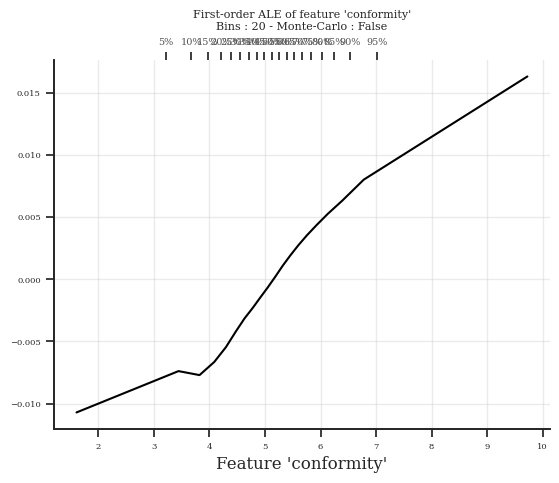

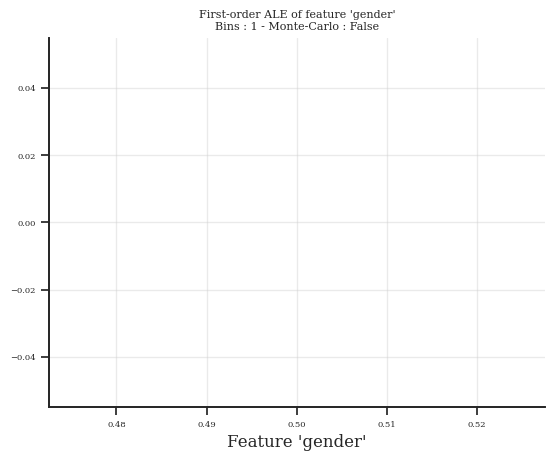

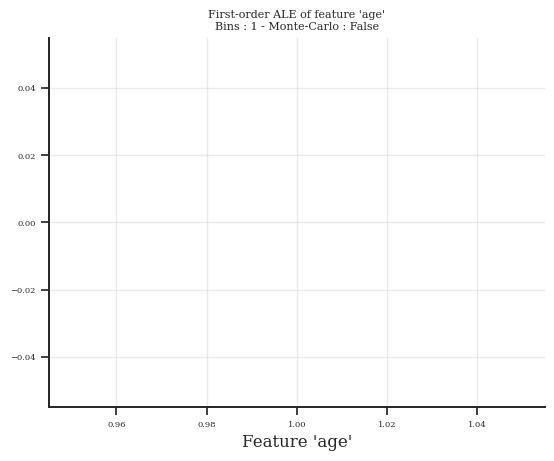

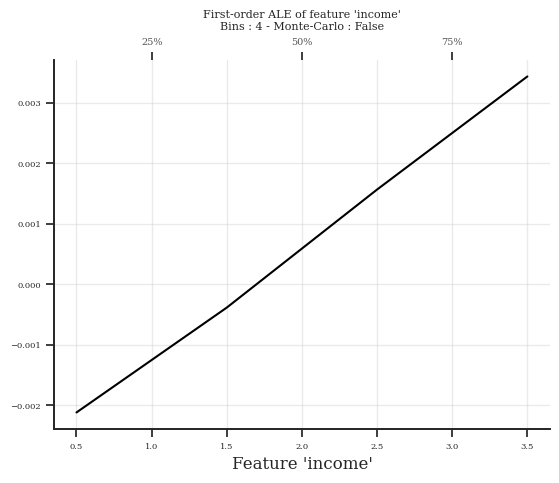

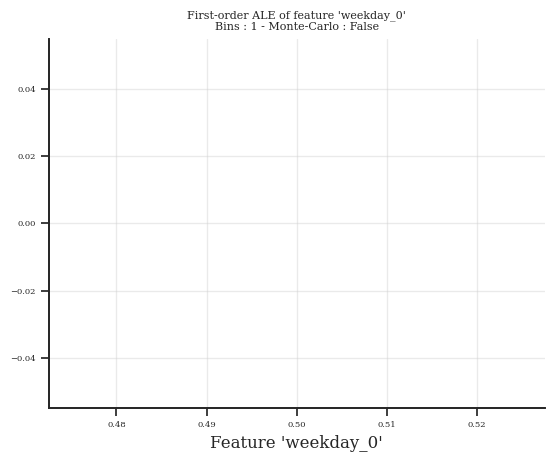

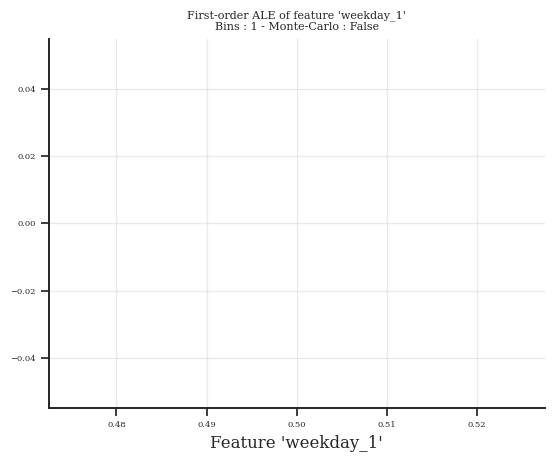

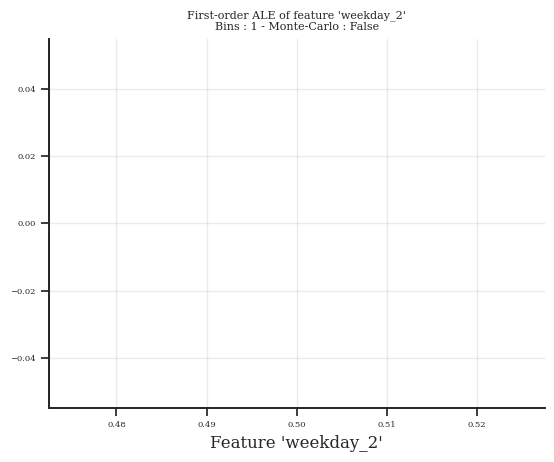

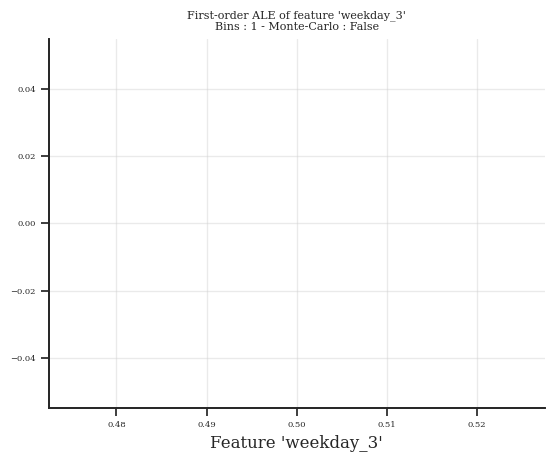

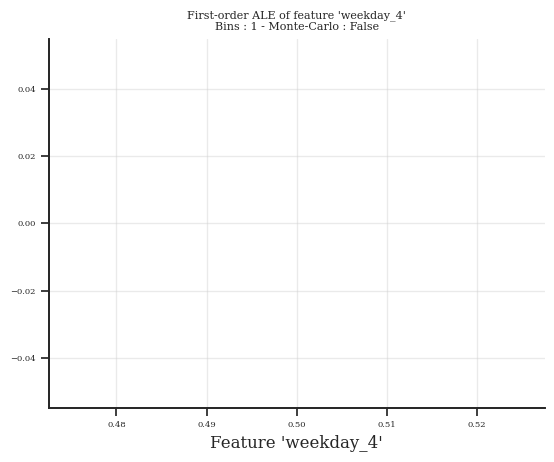

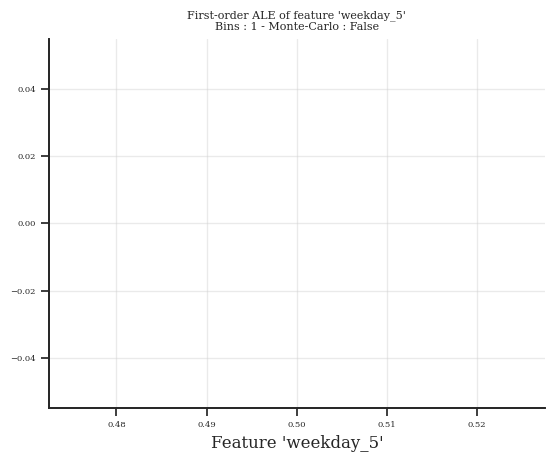

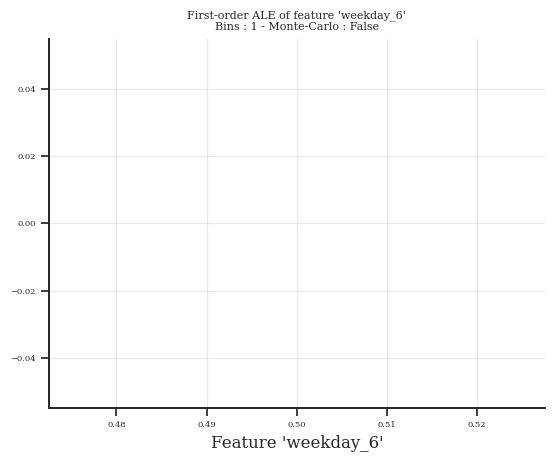

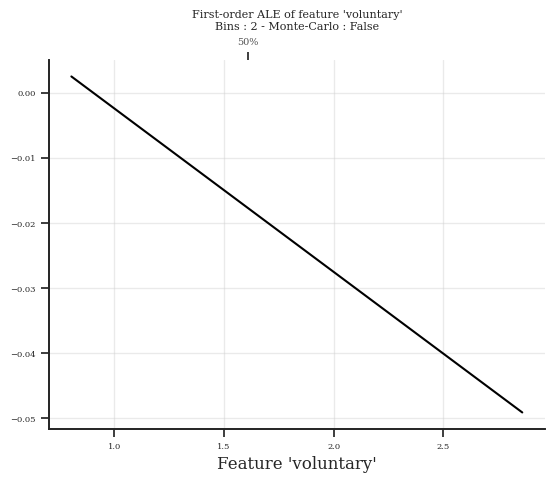

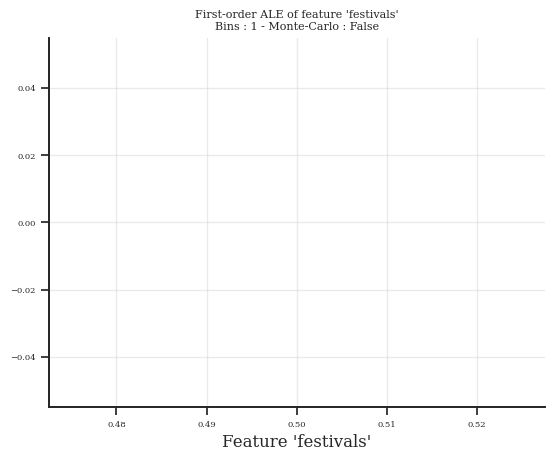

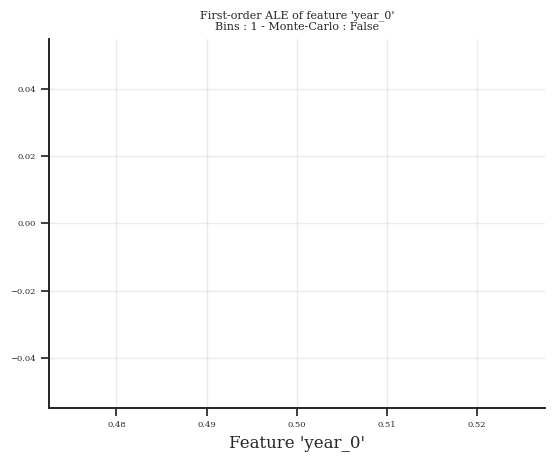

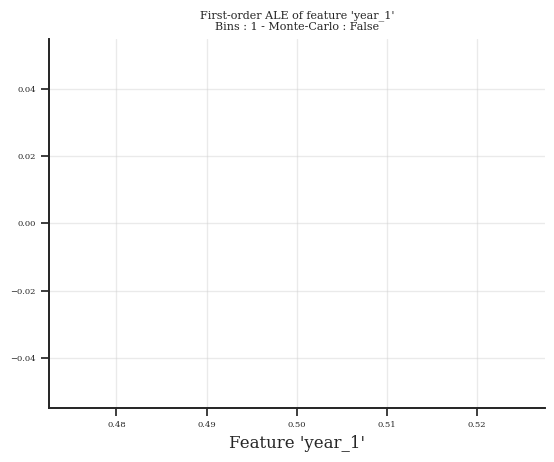

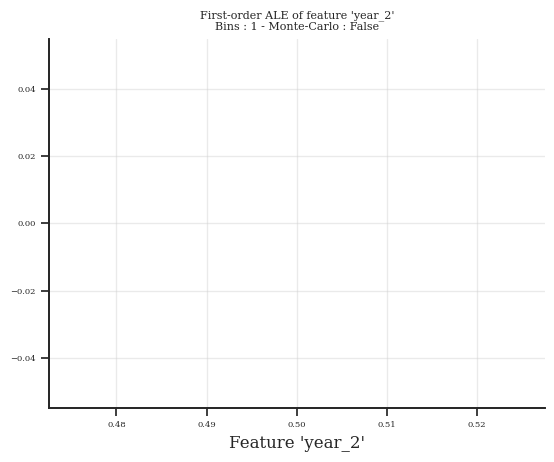

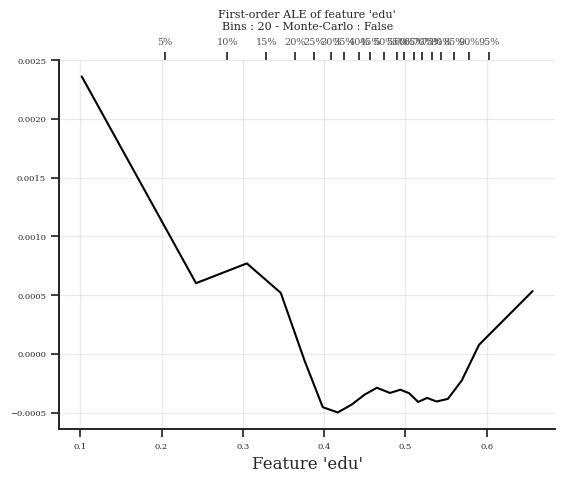

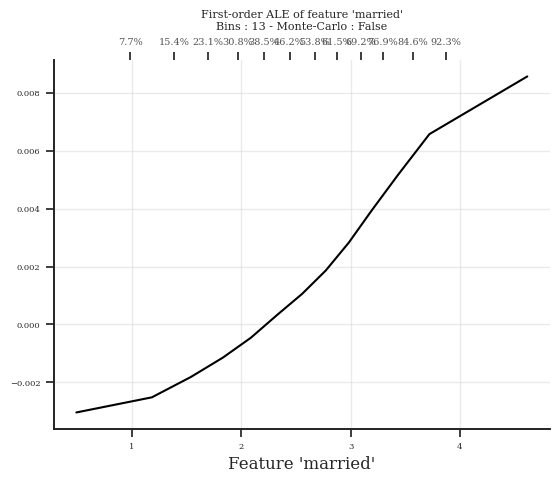

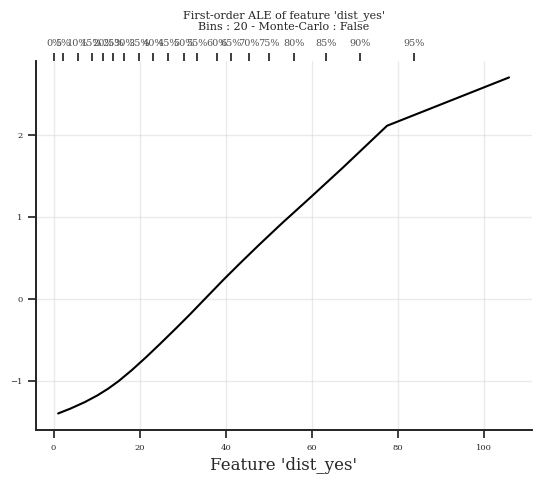

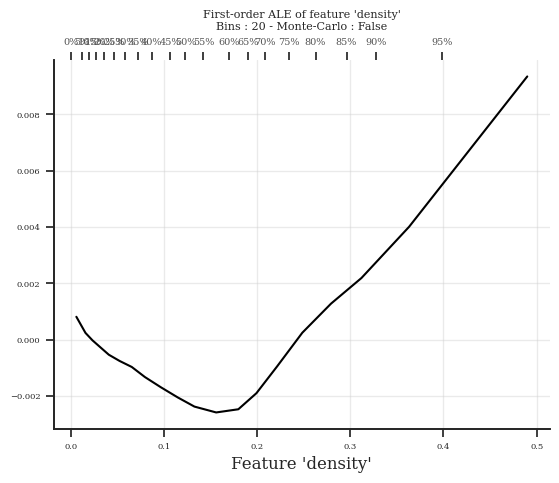

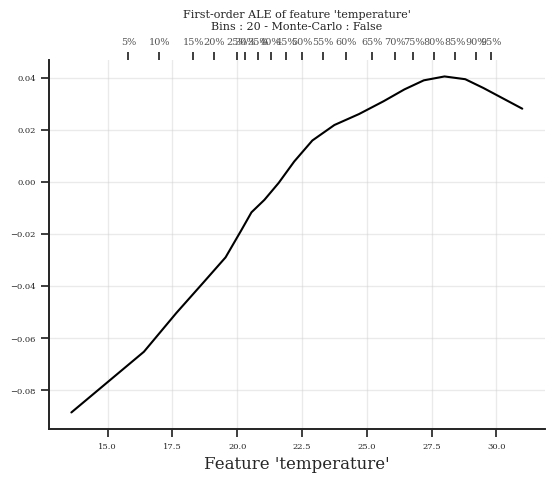

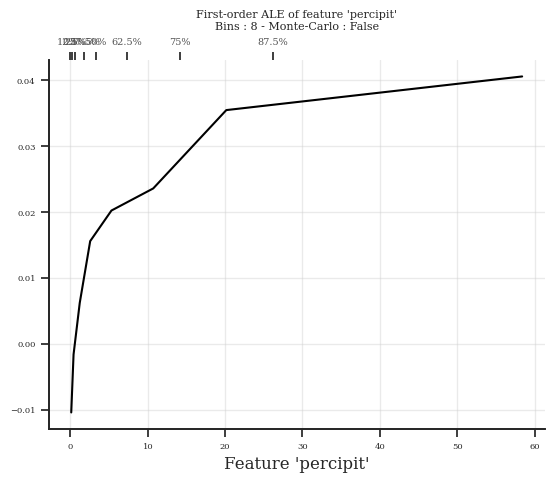

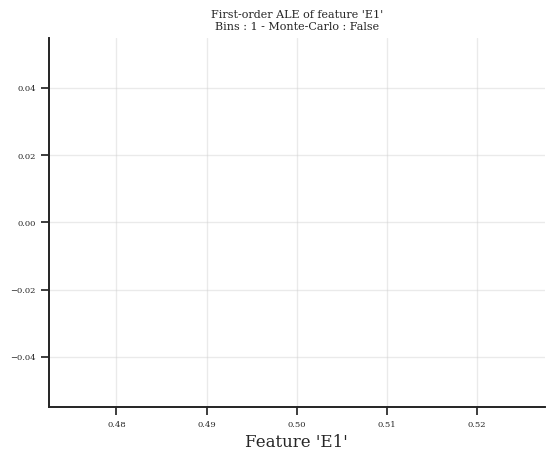

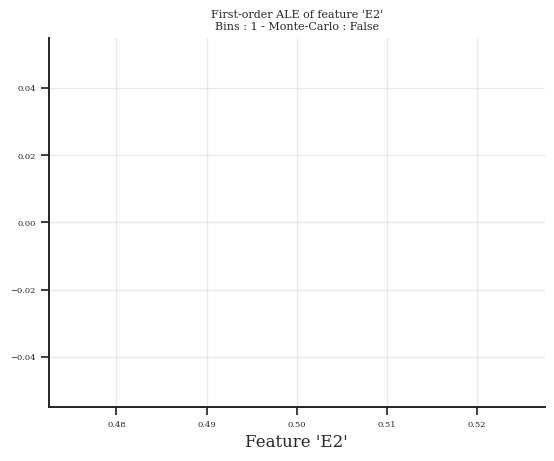

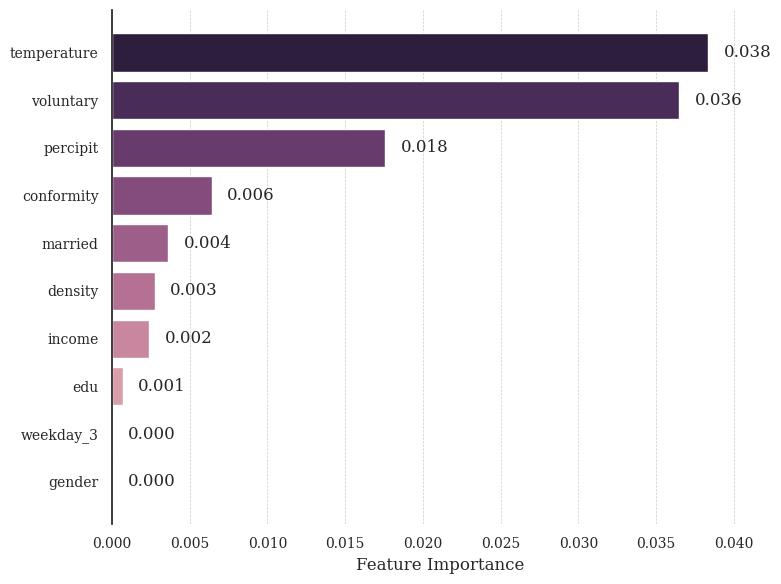

In [6]:
ALE_1ST, ALE_1ST_bin, feature_values = compute_ale_for_features(
        dataset, features, exp_name,
        n_sample=1000, treatment_feature_name="conformity"
    )

ale_ds, X, y = build_ale_xarray_dataset(
    ALE_1ST, ALE_1ST_bin, feature_values, features
)

ale_var_result, global_fig, ax = ale_variance_and_plot(
        X, y, ale_ds,
        model_name='RNN_Model',
        extra_estimators=(RandomForestRegressor(),),
        save_path=False,
        show=False,
        show_topN=[1,11]
    )

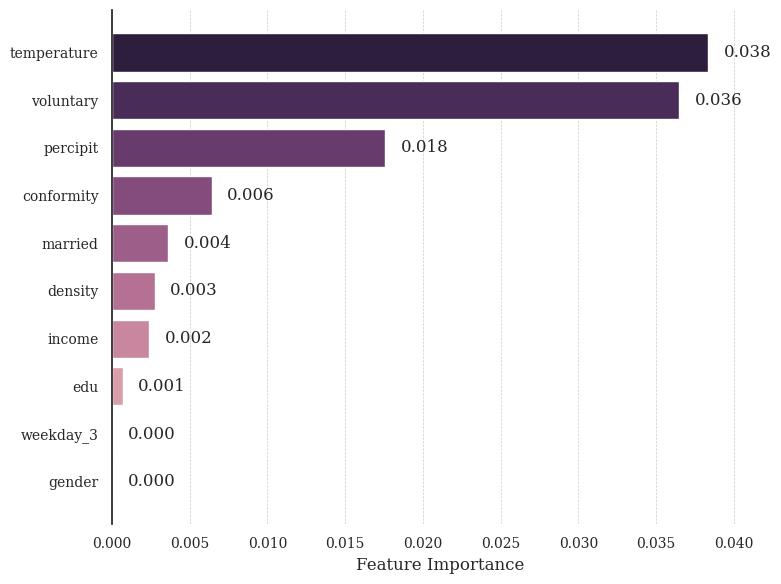

In [7]:
global_fig

In [8]:
# save_data
# 构建保存字典
ale_data_dict = {
    "X": X,
    "y": y,
    "ale_dataset": ale_ds,
}

# 保存为二进制文件（推荐 .pkl 格式）
save_path = "figures/figure_data/fig_2a_global_importance.pkl"
with open(save_path, "wb") as f:
    pickle.dump(ale_data_dict, f)

In [9]:
# 先划分数据集
column_2019 = 12  # index of year 2019 indicator
column_2020 = 13  # index of year 2020 indicator
column_2023 = 14  # index of year 2023 indicator

dataset19 = obtain_dataset(dataset, column_2019)
dataset20 = obtain_dataset(dataset, column_2020)
dataset23 = obtain_dataset(dataset, column_2023)

# 这里要删掉与年份相关的变量以及非疫情年中与疫情相关的变量
features_19 = [f for f in features if f not in ['voluntary', 'year_0', 'year_1', 'year_2', 'E1', 'E2']]
features_20 = [f for f in features if f not in ['voluntary', 'year_0', 'year_1', 'year_2']]

Processing 2019 dataset...


2026-01-13 05:48:56.562 | DEBUG    | ale:_first_order_ale_quant:394 - Quantiles: [ 0.         3.3812864  3.817773   4.0857577  4.284527   4.448262
  4.592219   4.730316   4.8566446  4.9811454  5.102364   5.2268095
  5.3543158  5.4841743  5.63424    5.806121   6.0083127  6.272064
  6.6024084  7.094702  12.749301 ].


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 16.61it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


...

INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 17.56it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 17.47it/s]
2026-01-13 05:54:06.906 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [ 0.   0.3  0.5  1.5  2.5  5.5  8.4 18.  44.2 90.6].


[ 0.15  0.4   1.    2.    4.    6.95 13.2  31.1  67.4 ]


Degrees of freedom <= 0 for slice.


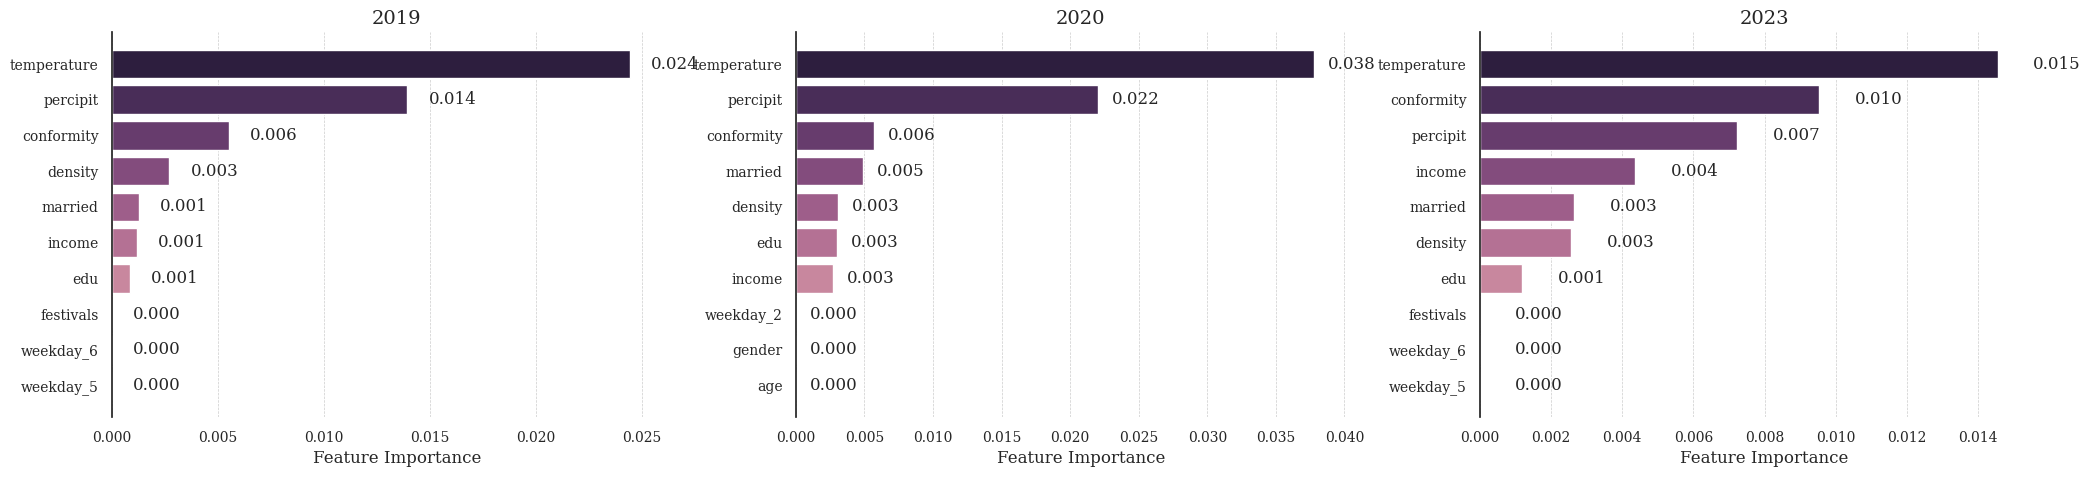

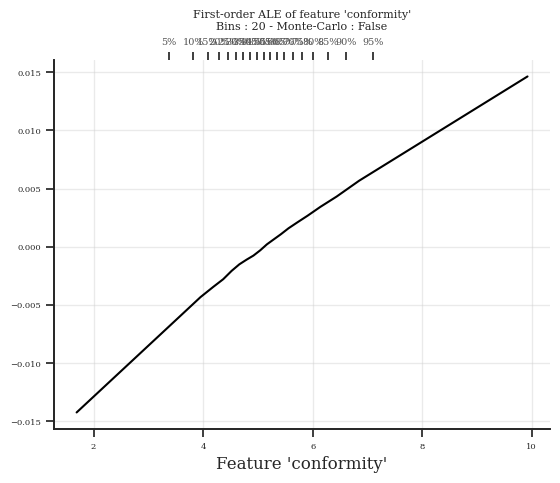

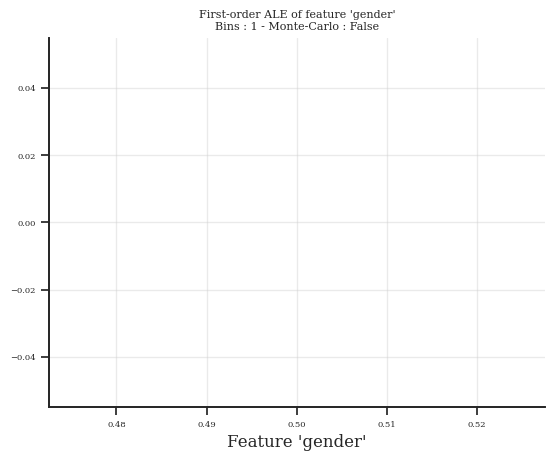

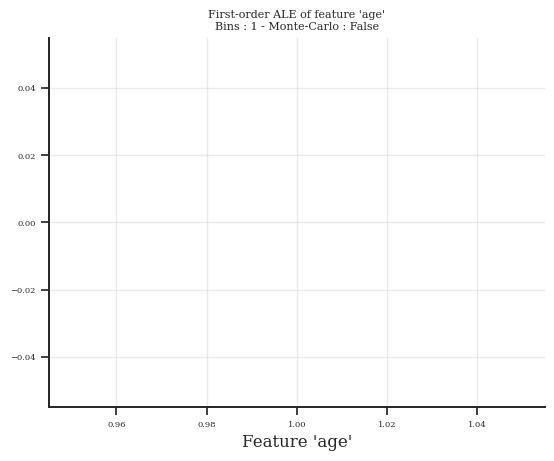

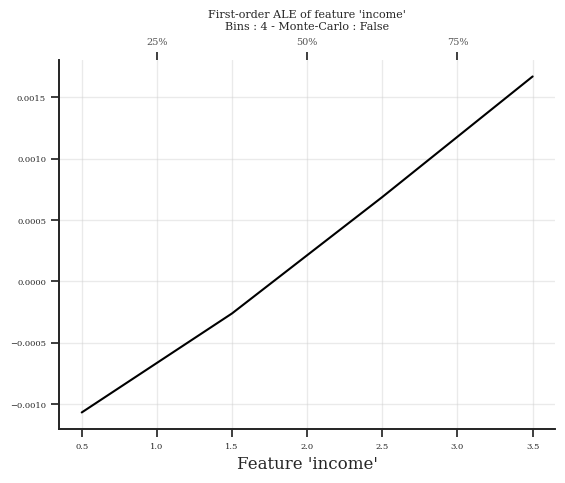

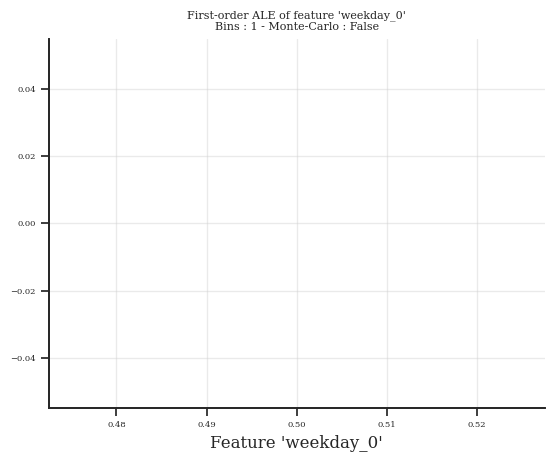

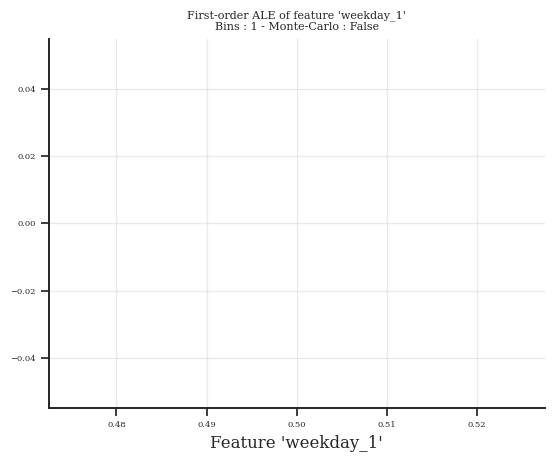

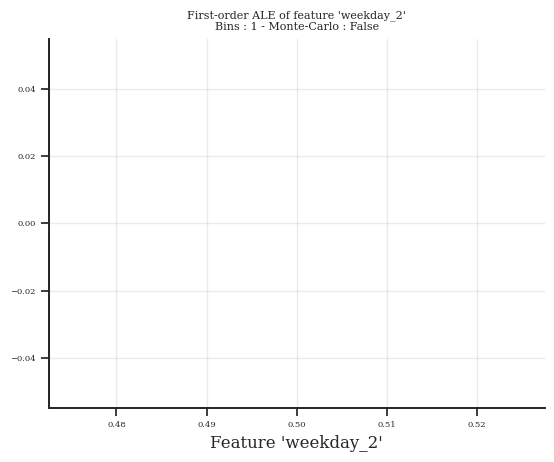

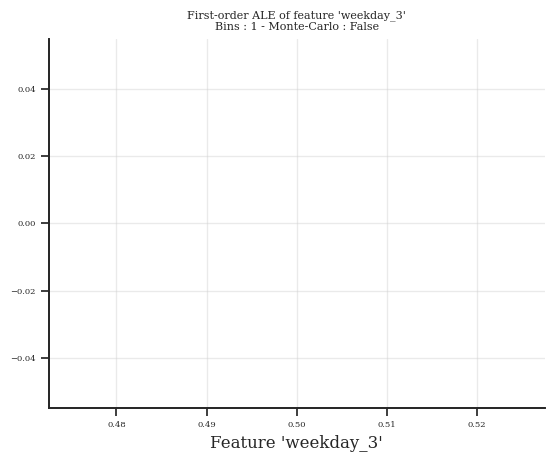

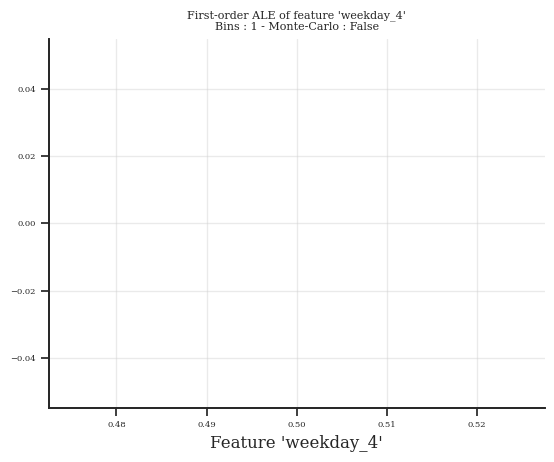

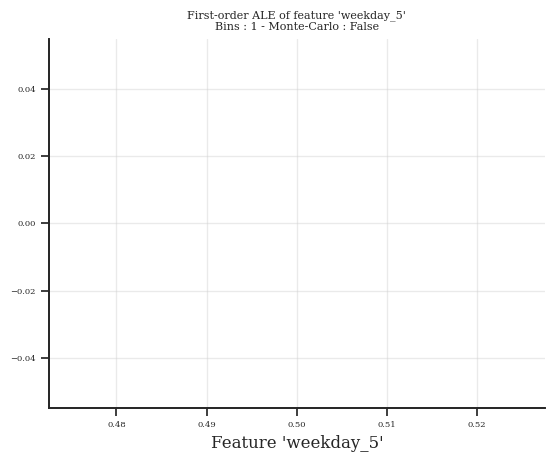

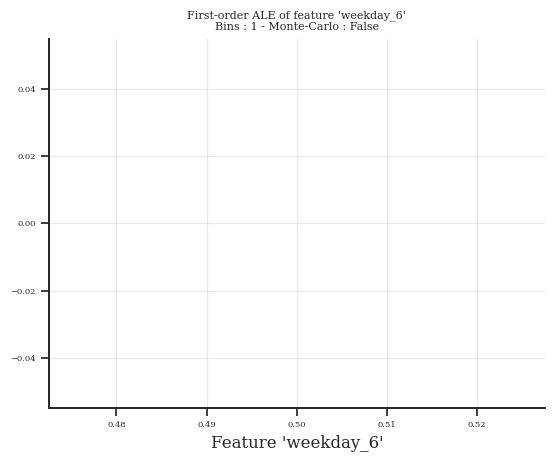

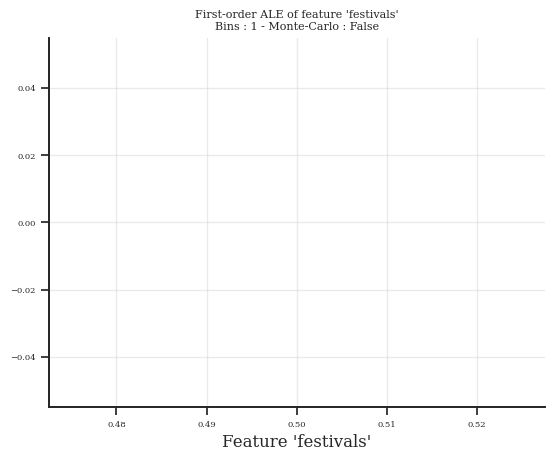

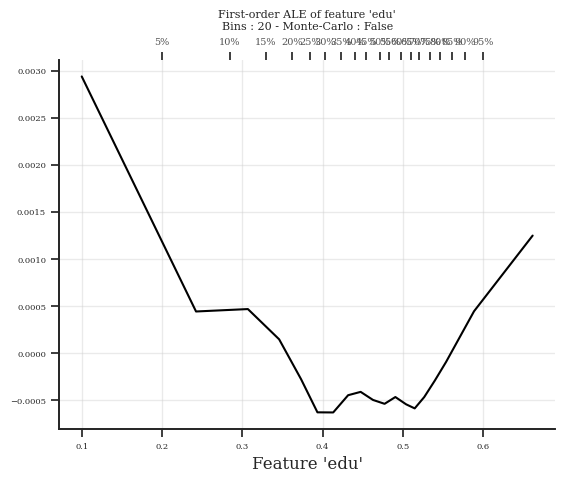

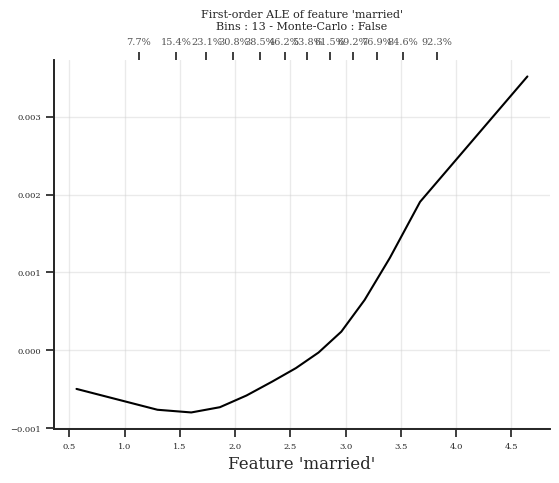

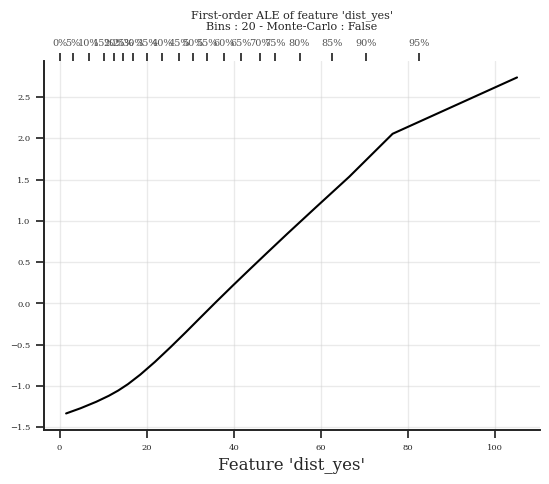

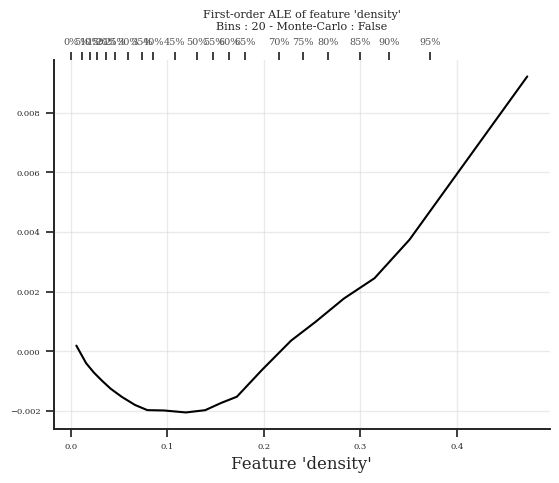

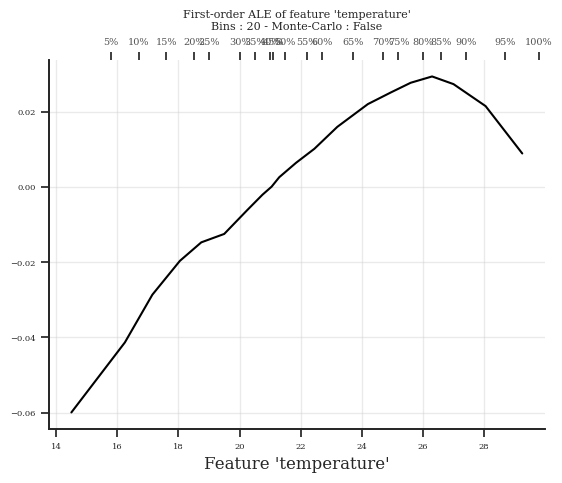

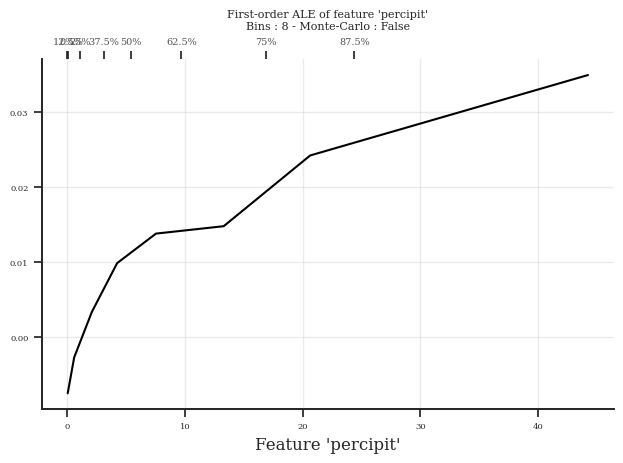

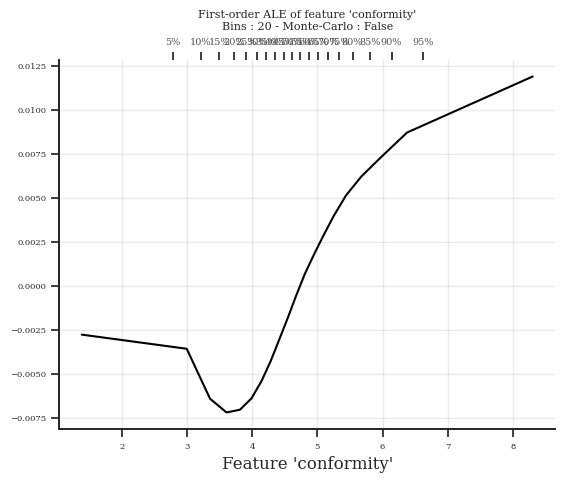

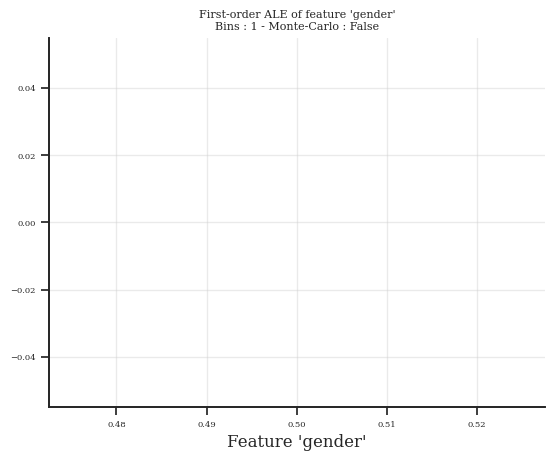

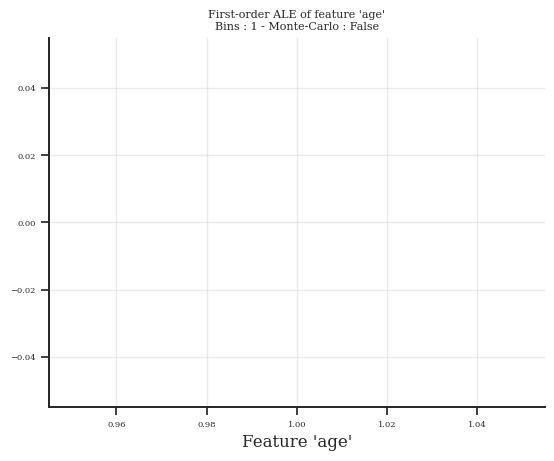

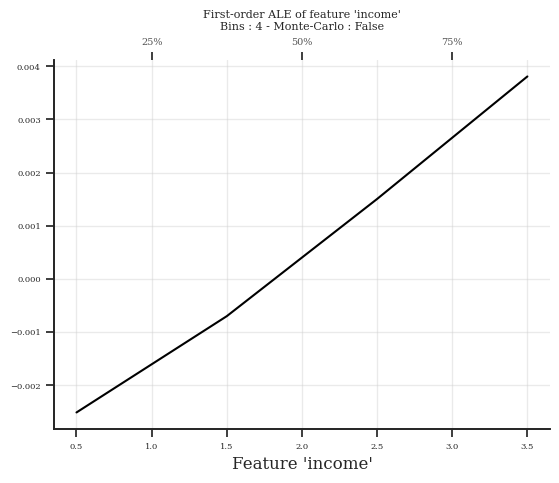

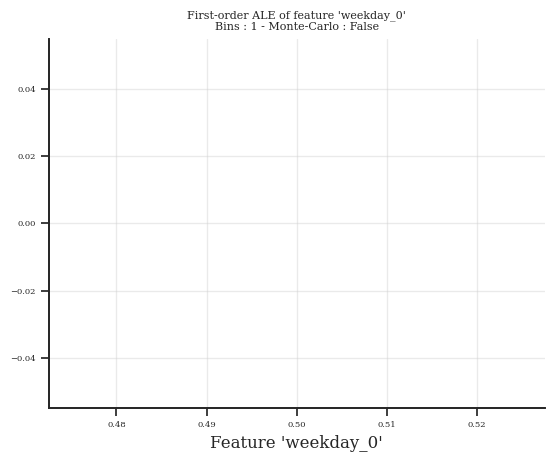

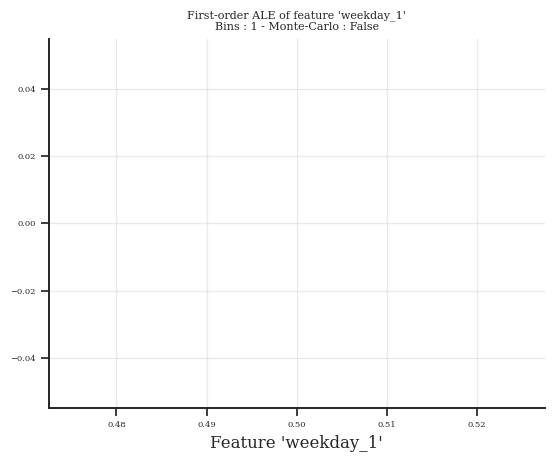

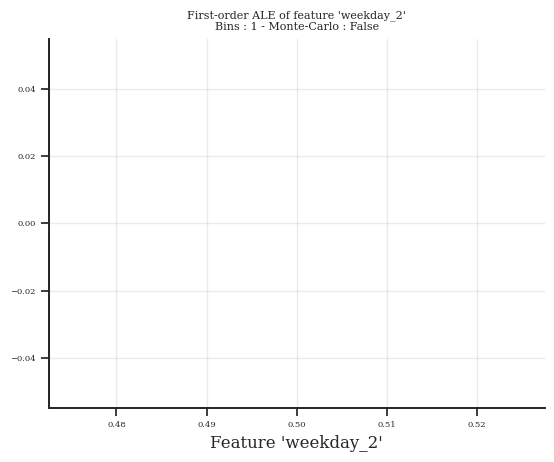

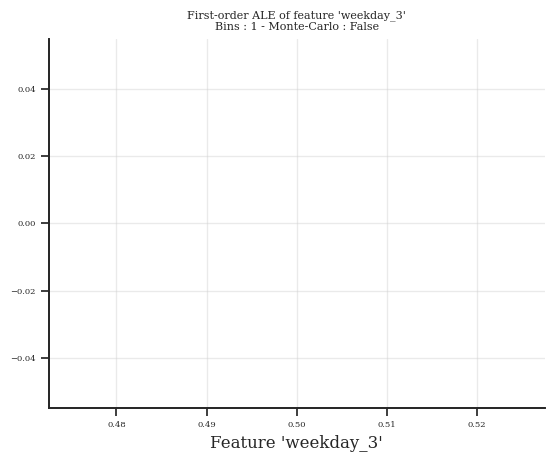

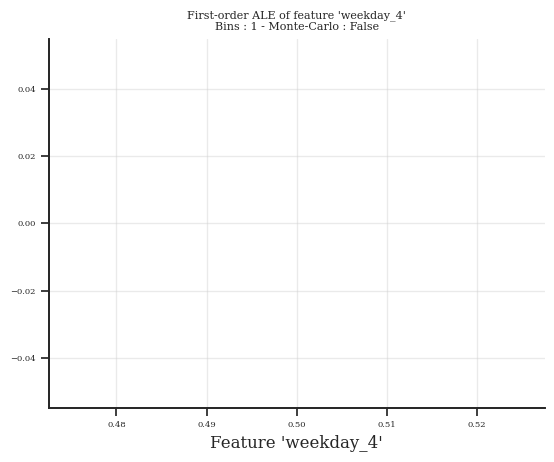

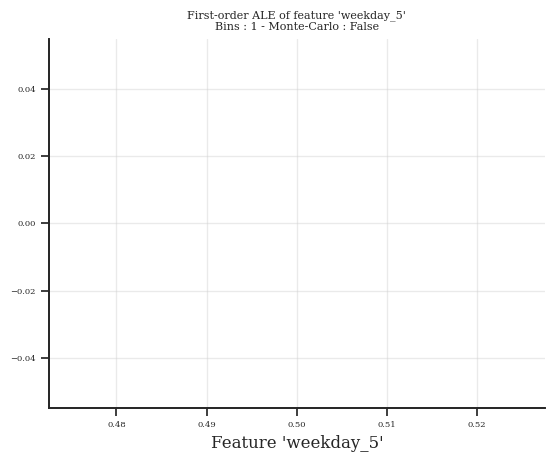

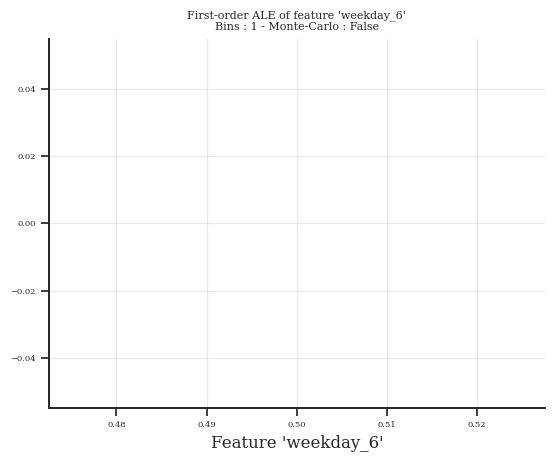

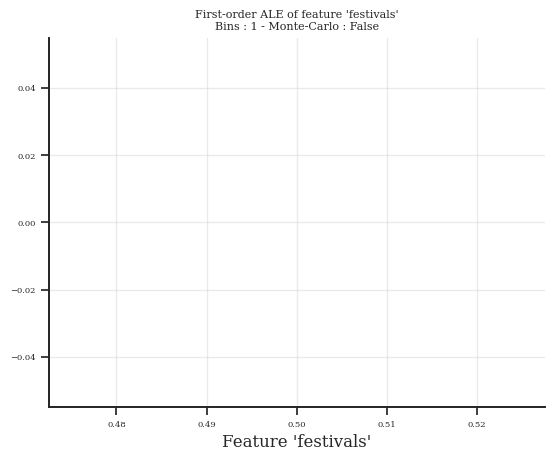

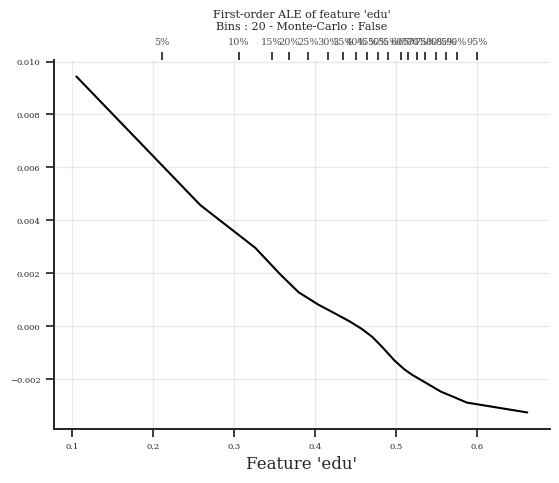

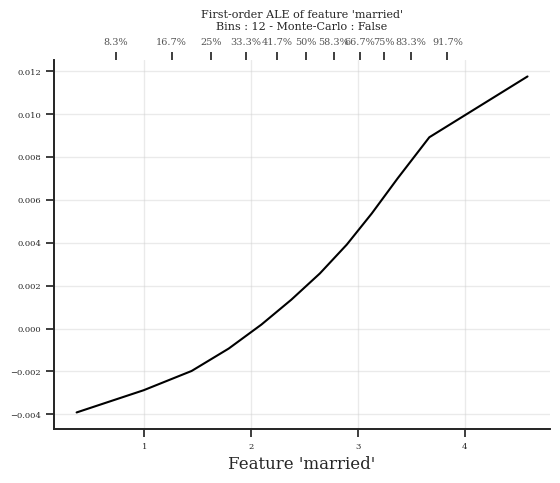

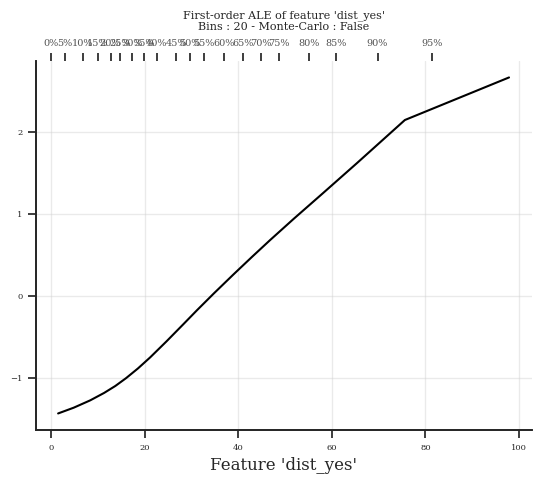

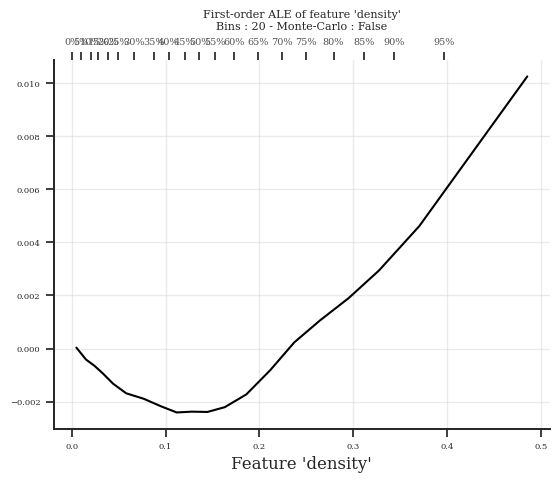

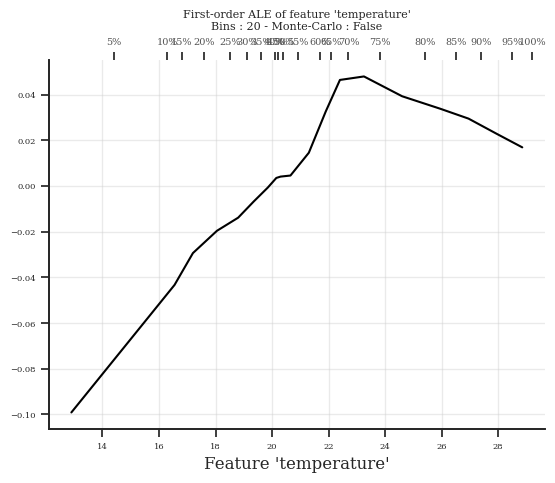

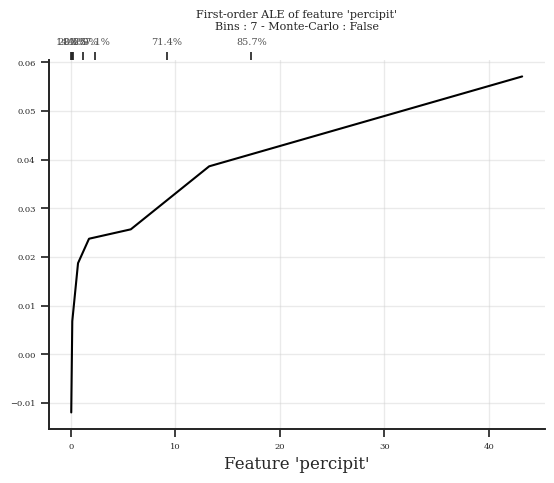

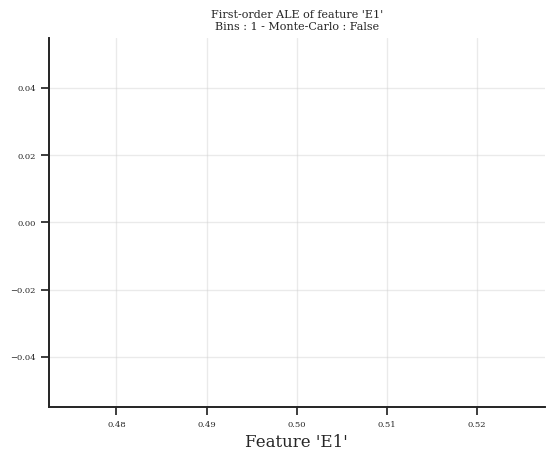

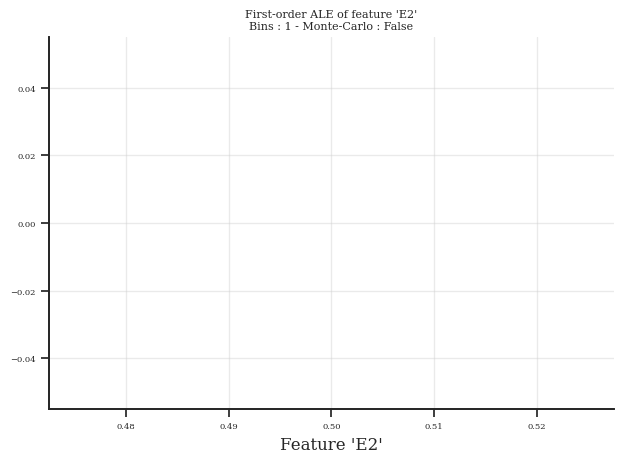

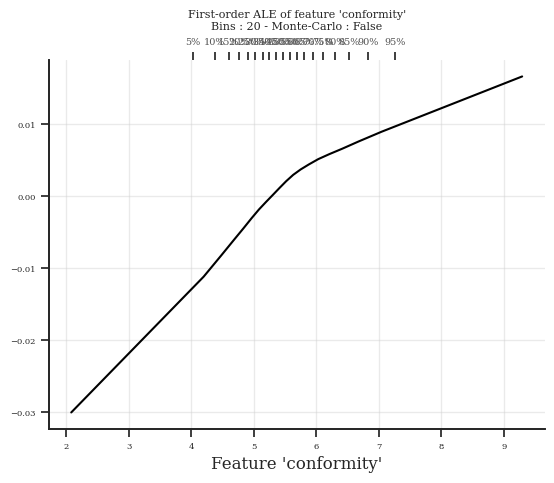

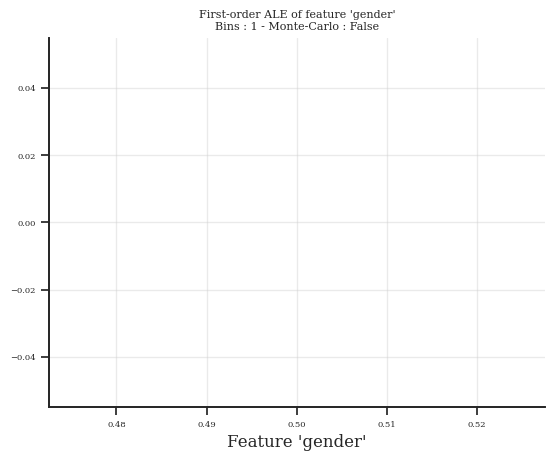

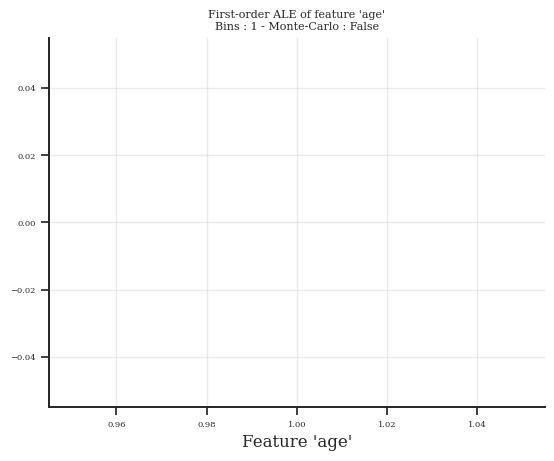

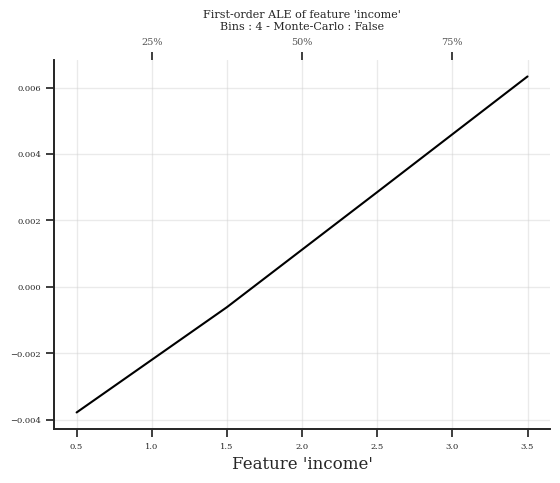

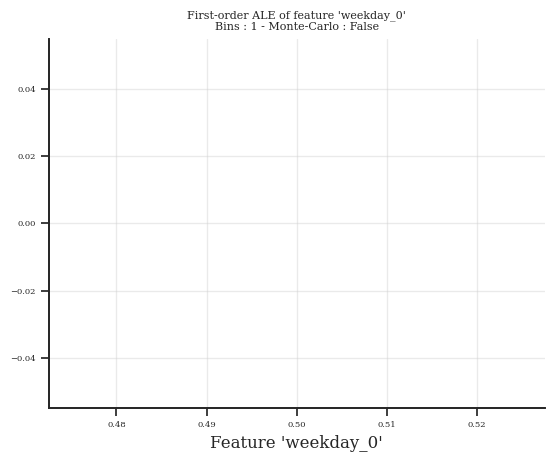

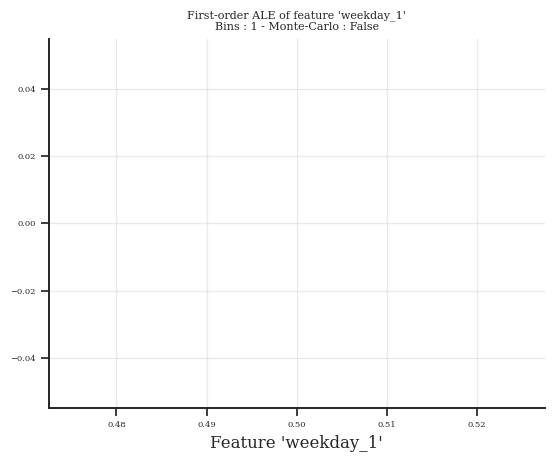

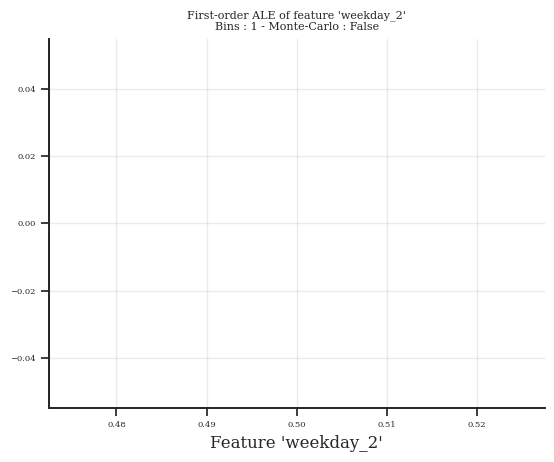

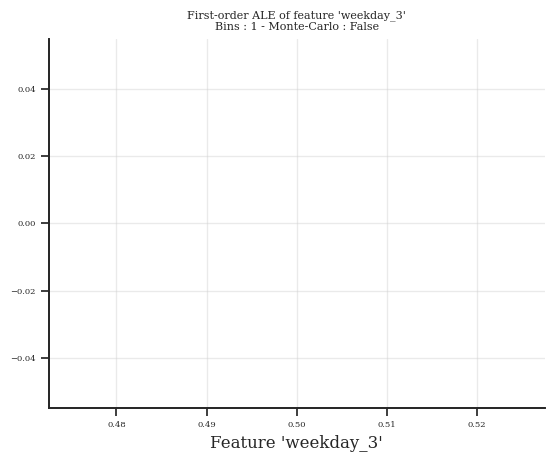

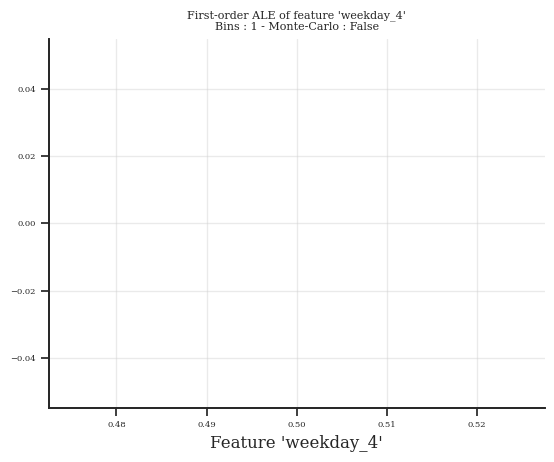

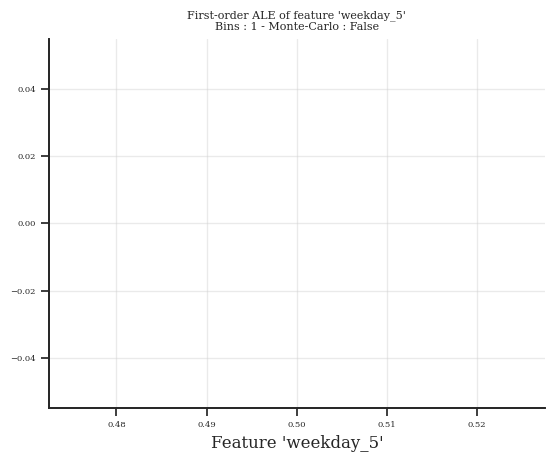

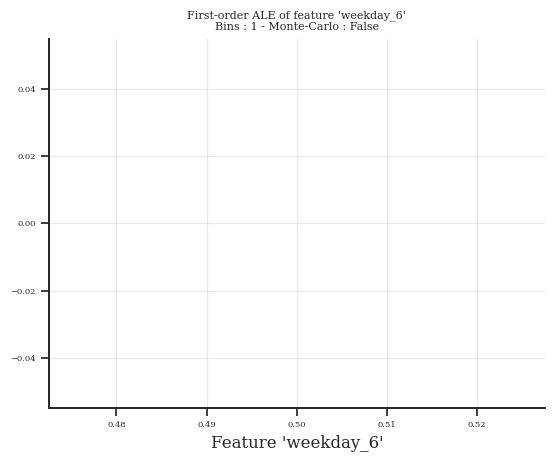

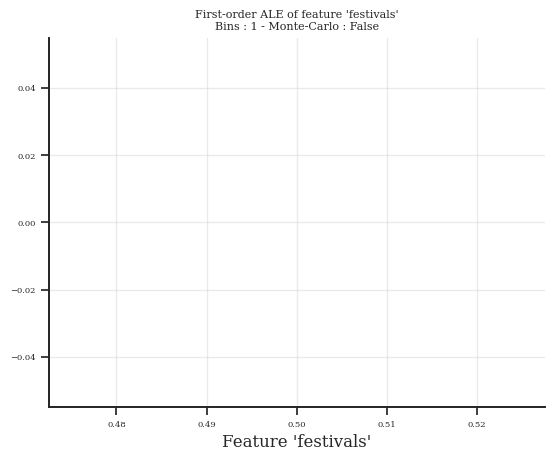

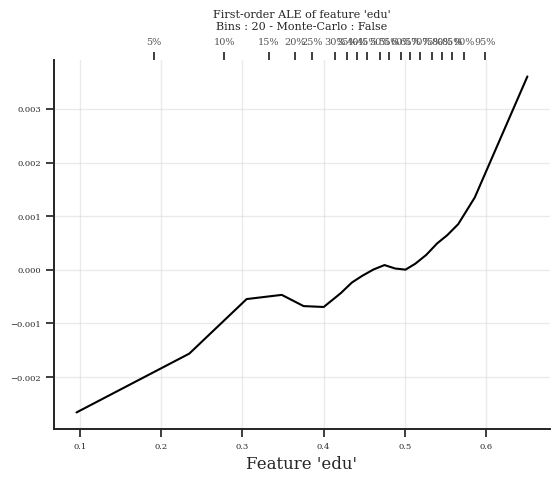

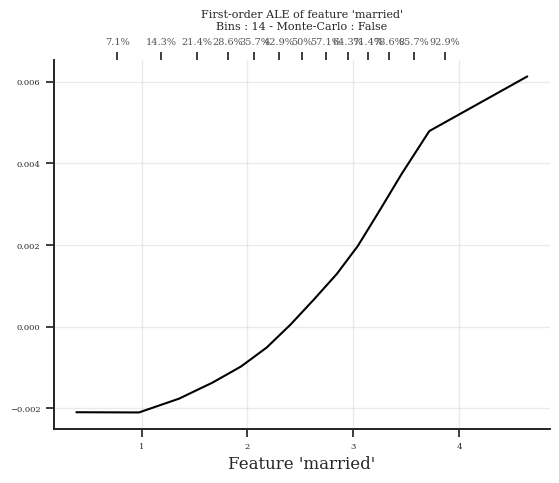

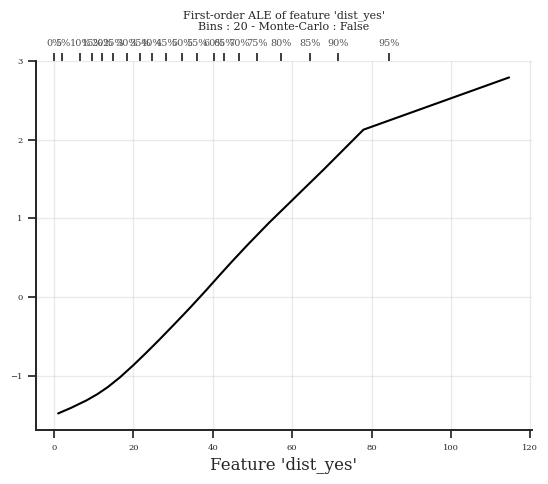

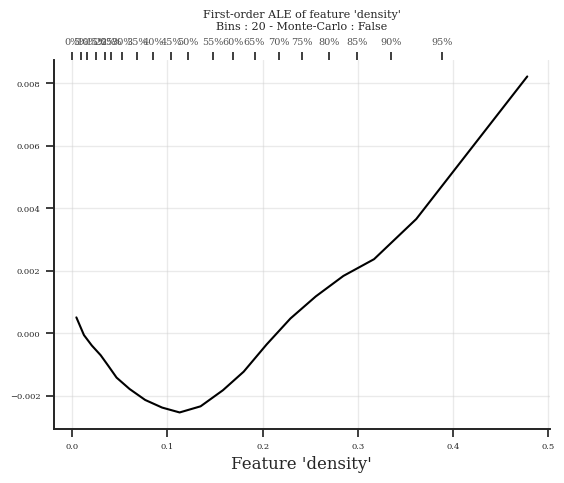

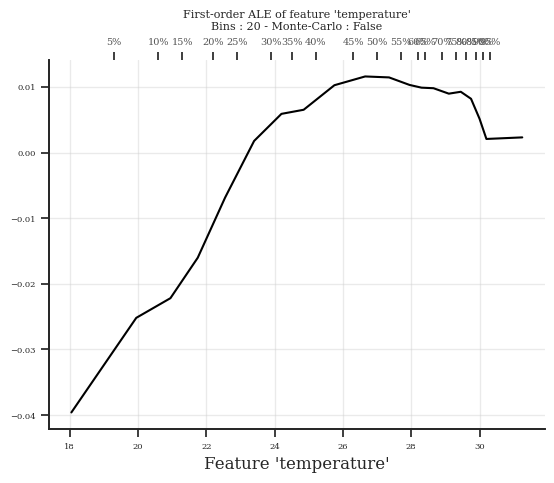

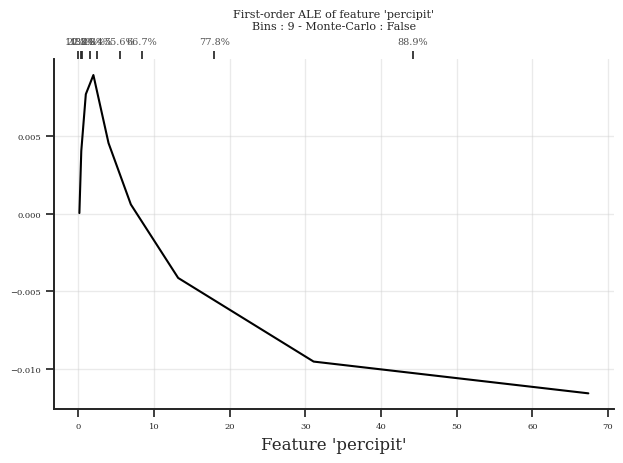

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(25, 5))  # 一行三列大图

for i, (dataset, year) in enumerate(zip([dataset19, dataset20, dataset23], ["2019", "2020", "2023"])):
    print(f"Processing {year} dataset...")
    if year != "2020":
        features_this_year = features_19
    else:
        features_this_year = features_20
        # index_to_remove = [-1,-2]
        # dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

    ALE_1ST, ALE_1ST_bin, feature_values = compute_ale_for_features(
        dataset, features_this_year, exp_name,
        n_sample=1000, treatment_feature_name="conformity",
    )

    ale_ds, X, y = build_ale_xarray_dataset(
        ALE_1ST, ALE_1ST_bin, feature_values, features_this_year
    )

    ale_var_result, global_fig, global_ax = ale_variance_and_plot(
        X, y, ale_ds,
        model_name='RNN_Model',
        extra_estimators=(RandomForestRegressor(),),
        save_path=False,
        show=False,
        ax=axes[i],
        show_topN = [1,11],
        figsize=(7,6)
    )

    axes[i].set_title(year, fontsize=14)
    
    ale_data_dict = {
        "X": X,
        "y": y,
        "ale_dataset": ale_ds,
    }

    save_path = f"figures/figure_data/fig2a_{year}_importance.pkl"
    with open(save_path, "wb") as f:
        pickle.dump(ale_data_dict, f)

# plt.tight_layout()
# plt.show()

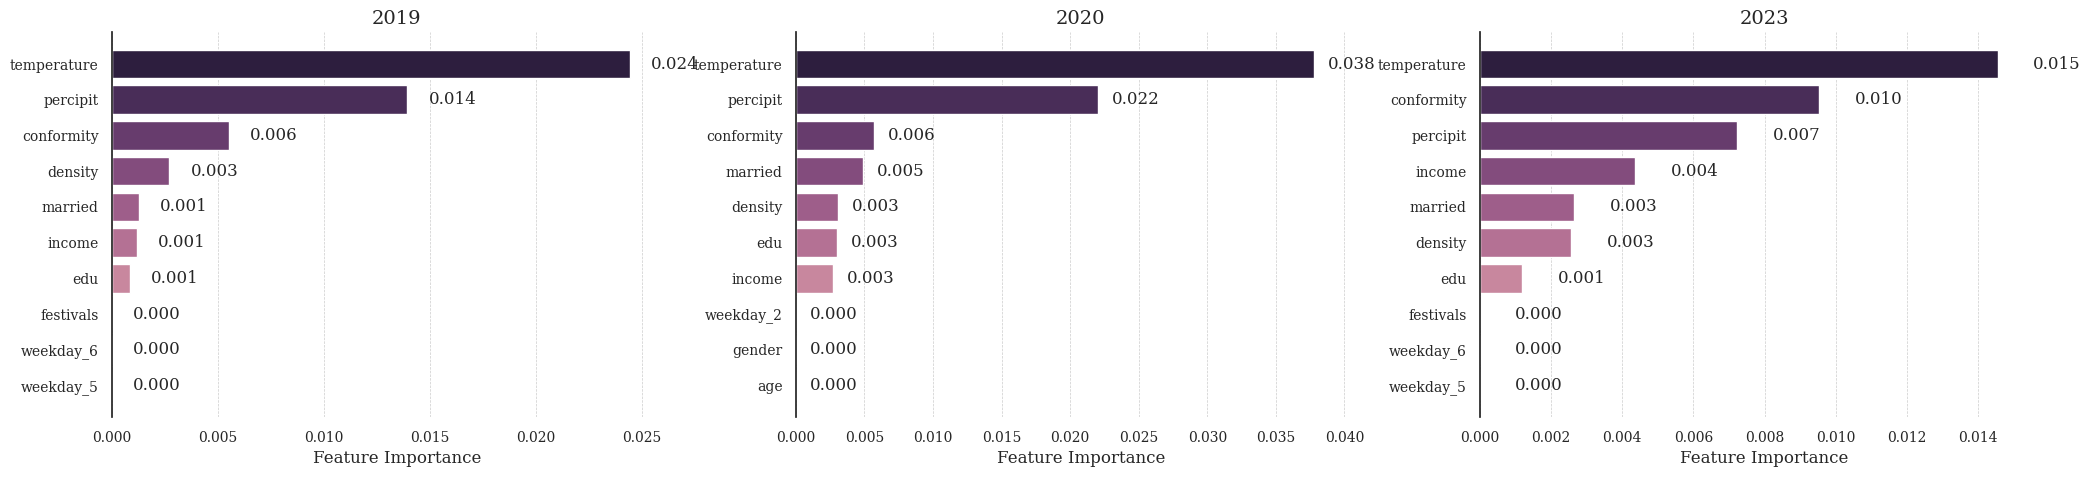

In [11]:
fig

## 本地数据读取绘制
待debug

In [ ]:
def recreate_global_fig(ale_1d_dataset, X, y, model_name="RNN_Model", 
                       figsize=(8, 6), save_path=None):
    """
    重新创建global_fig - 特征重要性水平条形图
    """
    import skexplain
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 创建解释器
    estimators = (model_name,)
    explainer = skexplain.ExplainToolkit(estimators=estimators, X=X, y=y)
    
    # 计算ALE方差（特征重要性）
    ale_var_result = explainer.ale_variance(ale=ale_1d_dataset)
    
    # 获取特征排名和分数
    features_ale_var = ale_var_result[f'ale_variance_rankings__{model_name}']
    scores_ale_var = ale_var_result[f'ale_variance_scores__{model_name}'][:,0]
    
    # 创建图表
    fig, ax = plt.subplots(figsize=figsize)
    
    # 使用调色板
    palette = sns.cubehelix_palette(n_colors=len(features_ale_var), reverse=True)
    
    # 绘制水平条形图
    bars = ax.barh(features_ale_var, scores_ale_var, color=palette)
    
    # 添加数值标签
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f"{width:.3f}", va='center', ha='left')
    
    # 设置图表样式
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance')
    ax.set_xlim(0, float(scores_ale_var.max()) * 1.1 if len(scores_ale_var) else 1.0)
    ax.grid(True, linestyle='--', linewidth=0.5, which='major', axis='x')
    ax.tick_params(axis='both', which='major', labelsize=10, tick1On=False, tick2On=False)
    ax.spines['bottom'].set_visible(False)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
    
    return fig, ax

In [ ]:
def recreate_ale_fig(ale_1d_dataset, features, figsize=(12, 8)):
    """
    重新创建ALE效应图
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    n_features = len(features)
    n_cols = 3  # 每行3个子图
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, feature in enumerate(features):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]
        
        # 获取ALE数据
        ale_values = ale_1d_dataset[f"{feature}__RNN_Model__ale"].values[0]  # 假设只有一个bootstrap
        bin_values = ale_1d_dataset[f"{feature}__bin_values"].values
        
        # 绘制ALE曲线
        ax.plot(bin_values, ale_values, linewidth=2, color='blue')
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        
        # 设置标签和标题
        ax.set_xlabel(feature)
        ax.set_ylabel('ALE')
        ax.set_title(f'ALE for {feature}')
        ax.grid(True, alpha=0.3)
    
    # 隐藏多余的子图
    for i in range(n_features, n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()
    return fig, axes

In [5]:
def ale_variance_and_plot(
    X,
    y,
    ale_1d_dataset,
    *,
    model_name="RNN_Model",
    extra_estimators=(),
    figsize=(8, 6),
    ax=None,
    show_topN=None, # take None or [start:stop]
    ignored_index=None,
    save_path=None,
    show=False,
):
    """
    执行：
      1) 计算 ALE 方差（特征重要性）
      2) 绘制水平条形图并保存
    返回：
      - ale_var_result: skexplain 的结果字典
    """
    estimators = (model_name, *extra_estimators)
    explainer = skexplain.ExplainToolkit(estimators=estimators, X=X, y=y)
    ale_var_result = explainer.ale_variance(ale=ale_1d_dataset)

    # 取排名和分数
    features_ale_var = ale_var_result['ale_variance_rankings__RNN_Model']
    scores_ale_var = ale_var_result['ale_variance_scores__RNN_Model'][:,0]

    if show_topN is not None:
        if isinstance(show_topN, (list, tuple)) and len(show_topN) == 2:
            start, stop = show_topN
            features_ale_var = features_ale_var[start:stop]
            scores_ale_var = scores_ale_var[start:stop]
        else:
            raise ValueError("show_topN 必须是形如 [start, stop] 的列表或元组，例如 [0, 10]")

    if ignored_index is not None:
        if isinstance(ignored_index, int):
            ignored_index = {ignored_index}
        elif isinstance(ignored_index, (list, tuple, set)):
            ignored_index = set(ignored_index)
        else:
            raise TypeError("ignored_index 必须是 int 或 int 的可迭代对象")

        n = len(features_ale_var)
        valid_idx = set(range(n))
        keep_idx = sorted(valid_idx - ignored_index)
        features_ale_var = features_ale_var[keep_idx]
        scores_ale_var = scores_ale_var[keep_idx]
    
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    # 画图（保持你原有风格）
    palette = sns.cubehelix_palette(n_colors=len(features_ale_var), reverse=True)

    bars = ax.barh(features_ale_var, scores_ale_var, color=palette)

    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f"{width:.3f}", va='center', ha='left')

    ax.invert_yaxis()
    ax.set_xlabel('Feature importance')
    ax.set_xlim(0, float(scores_ale_var.max()) * 1.1 if len(scores_ale_var) else 1.0)
    ax.grid(True, linestyle='--', linewidth=0.5, which='major', axis='x')
    # ax.tick_params(axis='both', which='major', labelsize=10, tick1On=False, tick2On=False)
    ax.tick_params(axis='both', which='major', tick1On=False, tick2On=False)
    ax.spines['bottom'].set_visible(False)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
    if show:
        plt.show()

    return ale_var_result, fig, ax

In [6]:
ale_data_dict = pickle.load(open("./figures/figure_data/fig_2a_global_importance.pkl", "rb"))
X = ale_data_dict["X"]
y = ale_data_dict["y"]
ale_ds = ale_data_dict["ale_dataset"]

ale_var_result, global_fig, ax = ale_variance_and_plot(
        X, y, ale_ds,
        model_name='RNN_Model',
        extra_estimators=(RandomForestRegressor(),),
        save_path=False,
        show=False,
        show_topN=[1,12],
        ignored_index=[8],
        ax=ax_a,
    )

Degrees of freedom <= 0 for slice.


<Figure size 1920x1440 with 0 Axes>

# figure 2b
SEI的ALE曲线（整体与分年度）
- ALE是一种模型无关的特征效应解释方法，它通过计算特征在局部区间内的平均边际效应来避免特征相关性的影响。
- 将特征值按分位数分成bins个区间
- 使用np.digitize确定每个样本属于哪个区间
- 对每个样本，创建两个副本，第一个副本：将特征值替换为所在区间的左边界，第二个副本：将特征值替换为所在区间的右边界，计算两个预测结果的差异，这就是局部效应
- 将属于同一区间的所有样本的局部效应取平均，得到每个区间的平均局部效应
- 计算区间中心点的ALE值（通过相邻点的平均），减去加权平均值进行中心化，使ALE的期望值为0
- 从对数转化为倍数尺度：表示特征变化对原始预测值的倍数影响

## 计算生成

In [ ]:
dataset = load_data("../data/sample_3w2_add.h5")

index_to_remove = dataset['covariates'].shape[2] - 5
dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

index_to_remove = dataset['covariates'].shape[2] - 5
dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

# 模型编号
exp_name = "base_model_optimal_v2"

# 生成 cubehelix 调色盘
cubehelix_palette = sns.cubehelix_palette(n_colors=10)

the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
2025-09-28 18:36:51.123 | DEBUG    | ale:_first_order_ale_quant:394 - Quantiles: [ 0.         3.2611444  3.7095845  4.0061593  4.229516   4.4099336
  4.560146   4.6955943  4.8192496  4.9418535  5.064613   5.1871424
  5.3120008  5.4451666  5.5895243  5.7486825  5.9392767  6.1954675
  6.5269103  7.0262747 12.199657 ].


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 16.81it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 16.71it/s]
2025-09-28 18:36:55.793 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [ 0.         3.2611444  3.7095845  4.0061593  4.229516   4.4099336
  4.560146   4.6955943  4.8192496  4.9418535  5.064613   5.1871424
  5.3120008  5.4451666  5.5895243  5.7486825  5.9392767  6.1954675
  6.5269103  7.0262747 12.199657 ].


[1.6305722 3.4853644 3.857872  4.117838  4.319725  4.4850397 4.62787
 4.757422  4.8805513 5.003233  5.1258774 5.249572  5.378584  5.5173454
 5.6691036 5.84398   6.0673723 6.361189  6.7765923 9.612967 ]


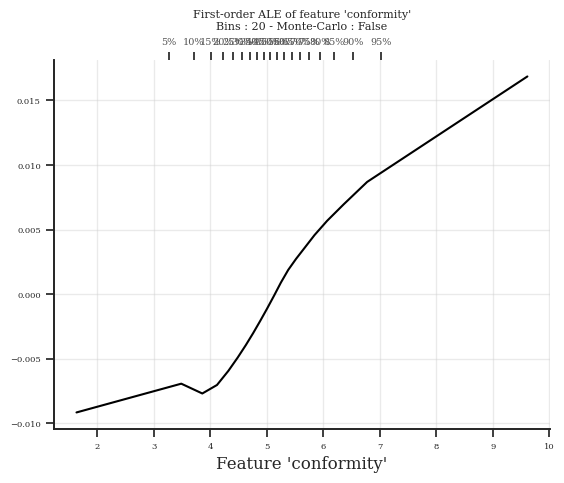

In [46]:
# 计算全局ale，转化成xarray的格式
# 似乎没有固定quantiles，需要再调整一下
bins = 20
quantiles = np.unique(
   np.quantile(
       dataset['treatments'].reshape(-1), np.linspace(0, 1, bins + 1), interpolation="lower"
   )
)
ALE_1ST = {
   'RNN_Model': [],
   }
# n_bootstrap = 30
n_bootstrap = 1

for _ in range(n_bootstrap):
    sub_dataset = dataset_sampling(dataset, 1000)
    ale_fig, ale_1st, _ = compute_ale(sub_dataset, 'rmsn_'+str(exp_name), b_use_predicted_confounders=False, features = ['conformity'], default_quantiles=quantiles)
    ALE_1ST['RNN_Model'].append(ale_1st)
    # window_ale_fig, ale, _ = compute_ale(sub_dataset, 'rmsn_' + str(exp_name), b_use_predicted_confounders=False, features=['week', 'conformity'], default_quantiles=quantiles)
    # ale_1st = np.sum(ale, axis=0)
    # ALE_1ST['RNN_Model'].append(ale_1st)

for key in ALE_1ST.keys():
    ALE_1ST[key] = np.array(ALE_1ST[key])
ale_dataset = create_ale_dataset(ALE_1ST, quantiles, dataset['treatments'], ['RNN_Model'], 'conformity')

ale_dataset.to_netcdf(path='figures/figure_data/fig_1b_noCI.nc')

In [8]:
# 还原SCI的log值
conformity_bin_values_log = ale_dataset['conformity__bin_values'].values
conformity_bin_values_original = np.exp(conformity_bin_values_log)-1
ale_dataset['conformity__bin_values'] = (('n_bins__conformity'), conformity_bin_values_original)

conformity_log = ale_dataset['conformity'].values
conformity_original = np.exp(conformity_log)-1
ale_dataset['conformity'] = (('n_X'), conformity_original)

ale_dataset

<xarray.Dataset>
Dimensions:                     (n_bootstrap: 30, n_bins__conformity: 20,
                                 n_X: 15456000)
Dimensions without coordinates: n_bootstrap, n_bins__conformity, n_X
Data variables:
    conformity__RNN_Model__ale  (n_bootstrap, n_bins__conformity) float64 -0....
    conformity__bin_values      (n_bins__conformity) float32 4.005 ... 3.236e+04
    conformity                  (n_X) float32 126.1 119.3 81.13 ... 235.4 100.5
Attributes:
    estimator_output:  raw
    estimators used:   ['RNN_Model']
    method:            ale
    dimension:         1D
    features used:     ['conformity']

In [9]:
# 将ALE值转换为倍数
ale_values = ale_dataset['conformity__RNN_Model__ale'].values
ale_values_original = np.exp(ale_values)
ale_dataset['conformity__RNN_Model__ale'] = ([('n_bootstrap'),('n_bins__conformity')], ale_values_original)

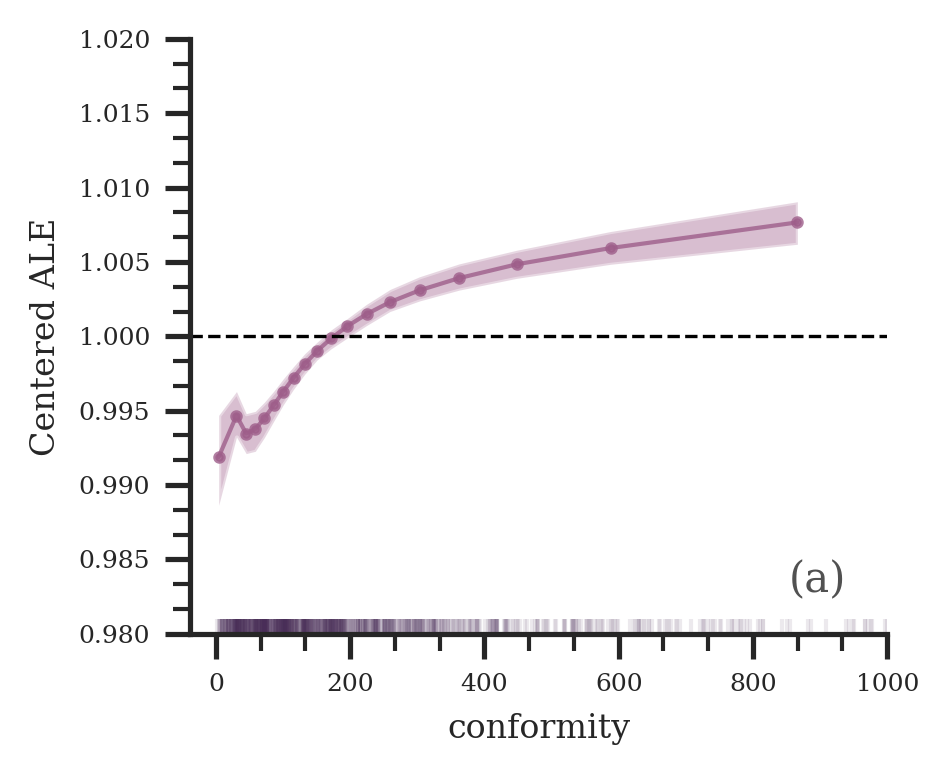

In [11]:
bins_to_keep = ale_dataset['n_bins__conformity'] != ale_dataset['n_bins__conformity'].loc[-1]
ale_dataset_select = ale_dataset.sel(n_bins__conformity=bins_to_keep)

estimator = [('RNN_Model',RandomForestRegressor())]
explainer = skexplain.ExplainToolkit(estimator)

#修改可视化效果
#fig, ax = plt.subplots(dpi=300)
fig, ax = explainer.plot_ale(
                                   ale = ale_dataset_select,
                                   features='conformity',
                                   display_units=plotting_config.display_units,
                                   display_feature_names=plotting_config.display_feature_names,
                                   line_kws={'marker': 'o', 'markersize':2,'linewidth':1, 'line_colors': [cubehelix_palette[5]]},
                                   add_hist = False,
                                  )
ax.axhline(y=1, color='black', ls='--', lw=0.8)

# ax.set_xscale('log')
ax.set_ylabel('Centered ALE', fontsize = 8)
ax.set_xlim(right = 1000)
# ax.set_xlim(left=1)
ax.set_ylim(bottom = 0.98, top = 1.02)


# ax.set_xticks(conformity_bin_values_original)
# ax.set_xticklabels([f'{val:.2f}' for val in conformity_bin_values_original])

data = ale_dataset['conformity'].values
if len(data) > 1000:
    data_sample = np.random.choice(data, size=1000, replace=False)
else:
    data_sample = data
sns.rugplot(data_sample, ax=ax, color=cubehelix_palette[-2], alpha=0.1)

plt.savefig('./figures/fig_1b_SCI_ale_1st_raw-1.png',  dpi=300)

plt.show()


In [ ]:
# 分年度曲线

column_2019 = 12  # index of year 2019 indicator
column_2020 = 13  # index of year 2020 indicator
column_2023 = 14  # index of year 2023 indicator

#dataset19 = obtain_dataset(dataset, column_2019)['treatments'][:,:,0]
#dataset20 = obtain_dataset(dataset, column_2020)['treatments'][:,:,0]
#dataset23 = obtain_dataset(dataset, column_2023)['treatments'][:,:,0]

dataset19 = obtain_dataset(dataset, column_2019)
dataset20 = obtain_dataset(dataset, column_2020)
dataset23 = obtain_dataset(dataset, column_2023)

the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
2025-09-28 18:01:24.391 | DEBUG    | ale:_first_order_ale_quant:394 - Quantiles: [ 0.         3.354312   3.8050478  4.074179   4.2774587  4.4436812
  4.59276    4.7233944  4.8513536  4.9738426  5.096646   5.219431
  5.352123   5.4967713  5.6421633  5.821136   6.0194025  6.2626176
  6.573758   7.0379295 13.370989 ].


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 0it [00:00, ?it/s]2025-09-28 18:01:25.789386: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
Predicting rnn_propensity_weighted: 16it [00:01, 13.02it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 16.76it/s]
2025-09-28 18:01:28.776 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [ 0.         3.354312   3.8050478  4.074179   4.2774587  4.4436812
  4.59276    4.7233944  4.8513536  4.9738426  5.096646   5.219431
  5.352123   5.4967713  5.6421633  5.821136   6.0194025  6.2626176
  6.573758   7.0379295 13.370989 ].


...

results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 16.76it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 16.83it/s]
2025-09-28 18:09:39.318 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [ 0.3551813  3.956017   4.3141494  4.5364814  4.7033305  4.8468547
  4.9745054  5.0906715  5.2039313  5.3174043  5.4261622  5.5362144
  5.6453557  5.7620425  5.8845983  6.0186453  6.193382   6.4119496
  6.7008424  7.167055  12.669338 ].


[2.155599  4.135083  4.4253154 4.619906  4.7750926 4.91068   5.0325885
 5.1473017 5.260668  5.3717833 5.4811883 5.590785  5.703699  5.8233204
 5.951622  6.1060133 6.3026657 6.556396  6.9339485 9.918197 ]


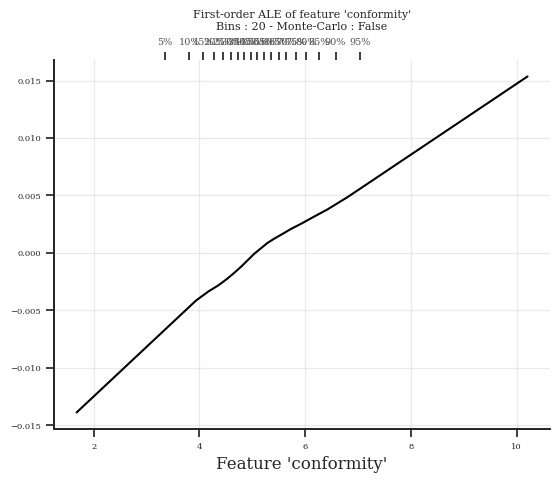

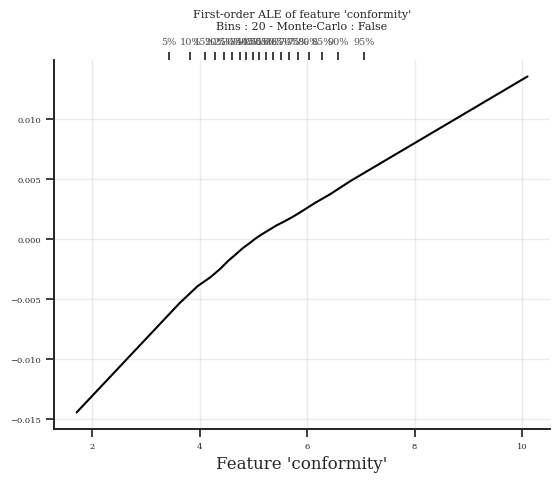

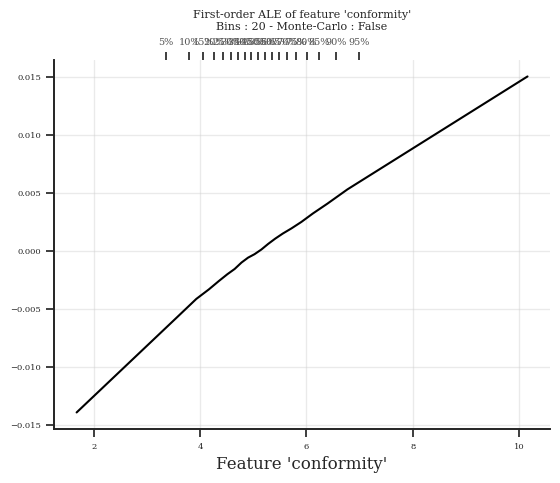

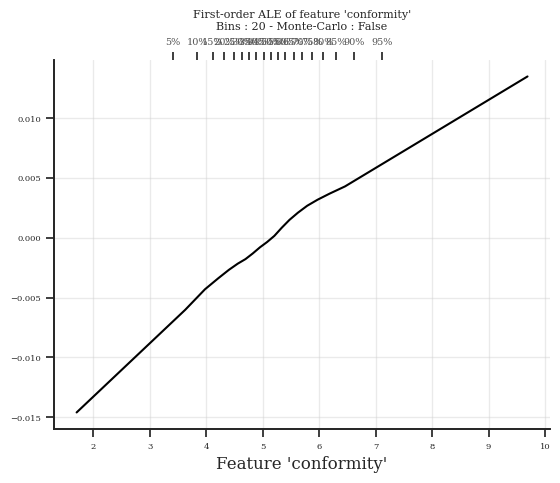

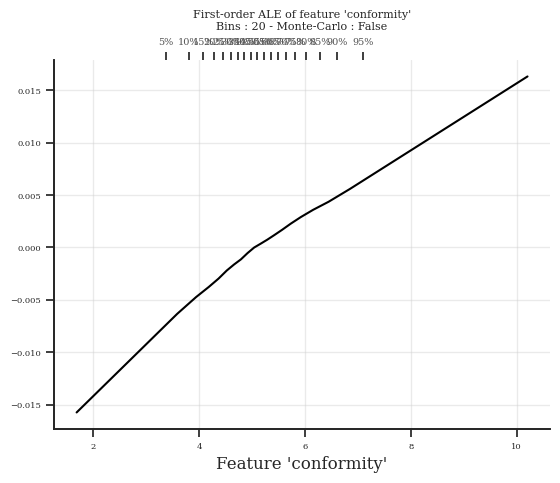

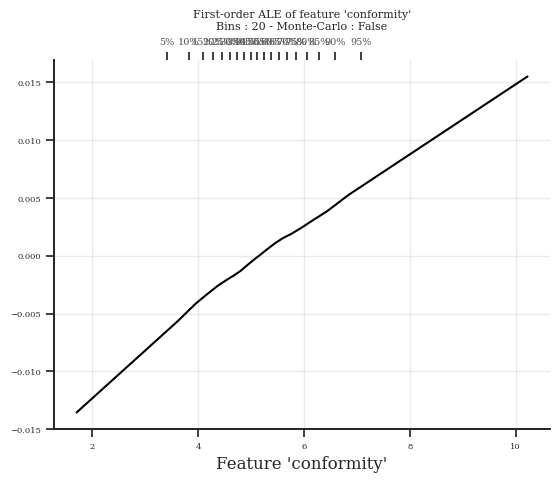

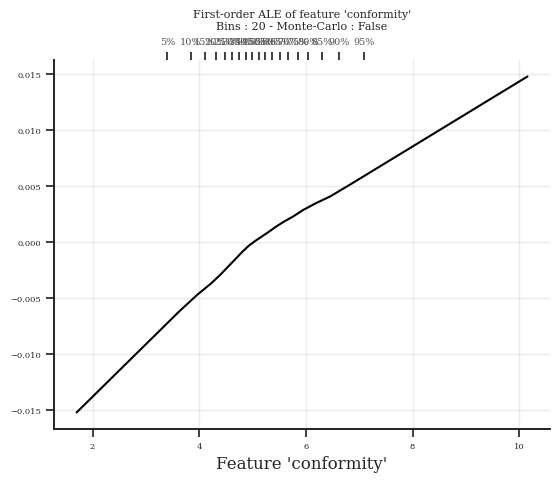

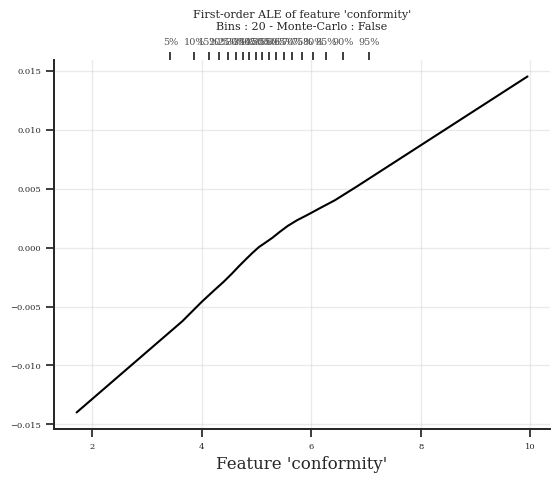

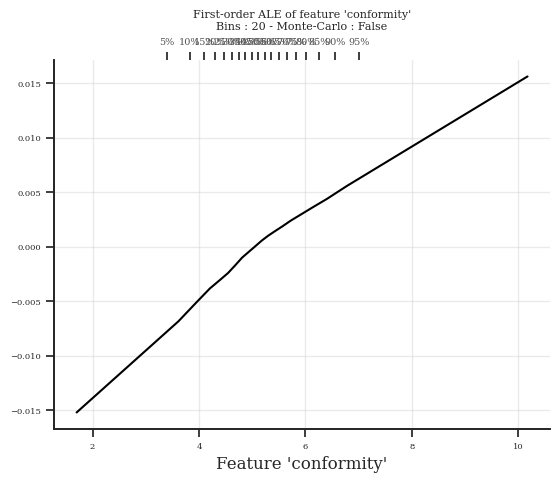

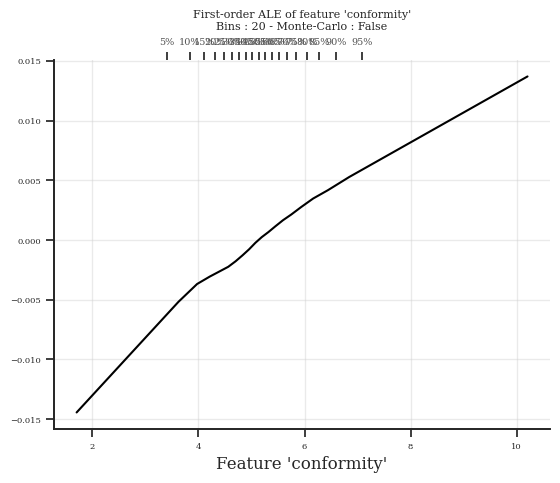

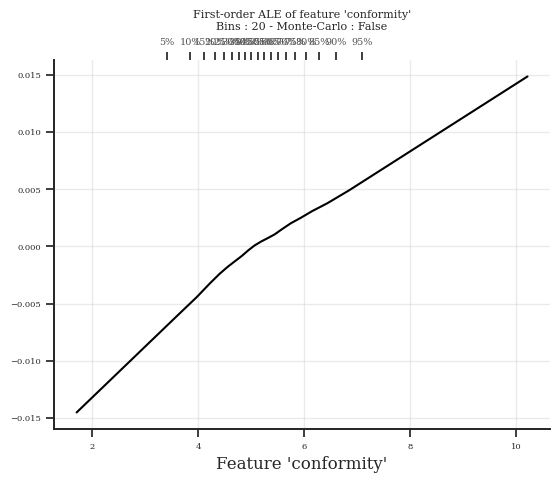

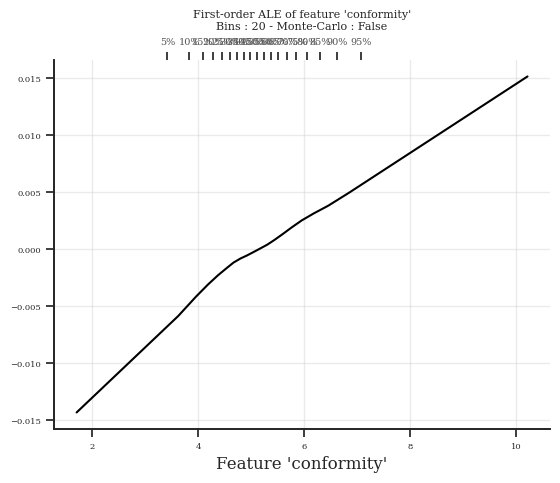

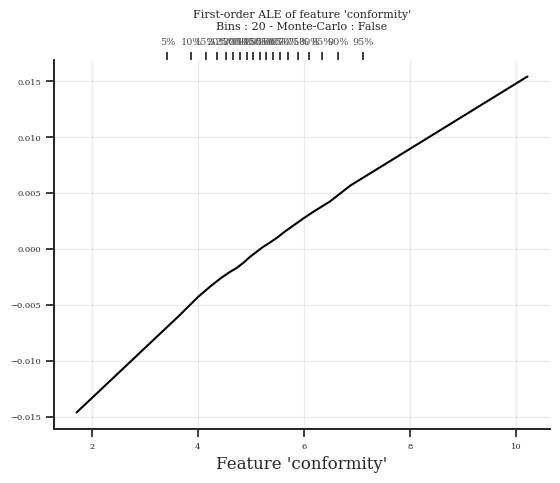

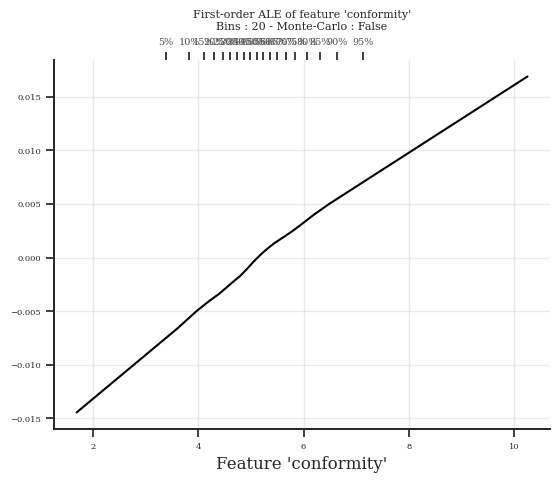

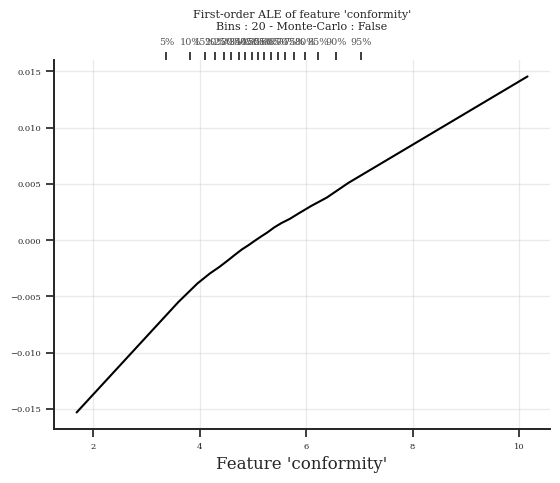

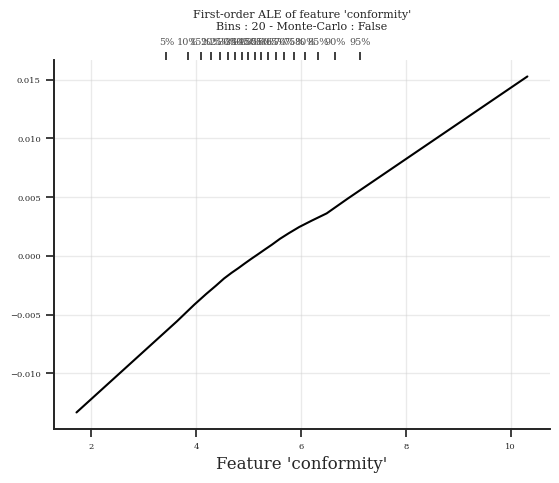

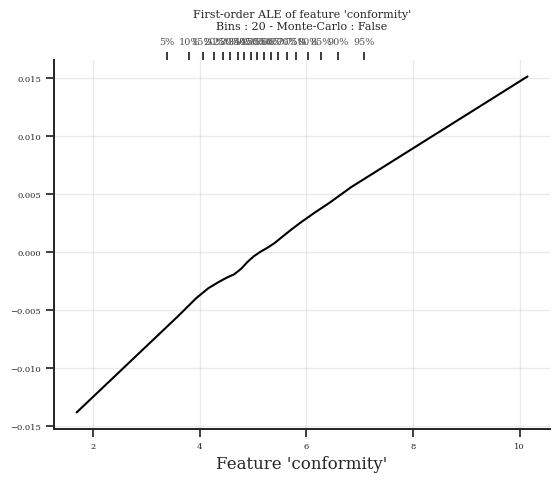

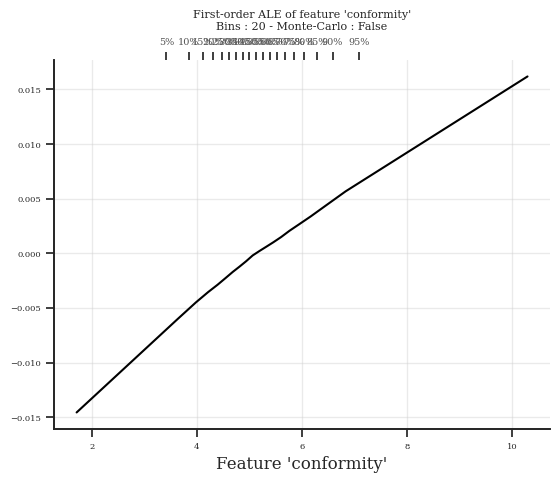

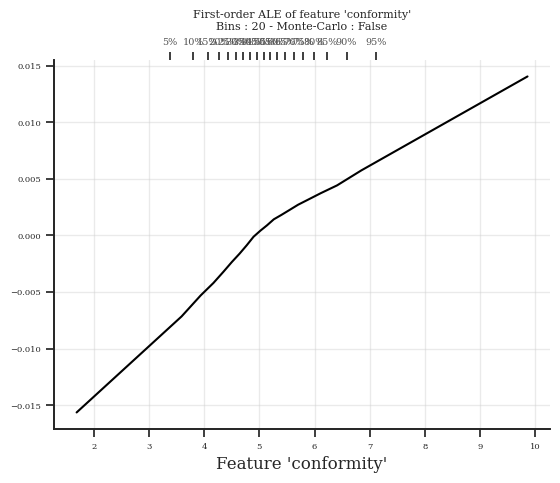

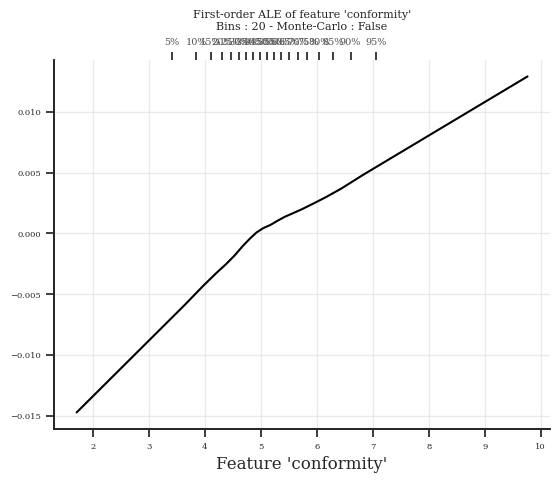

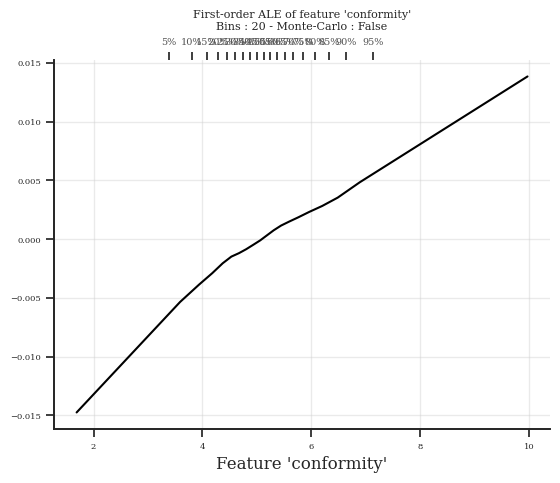

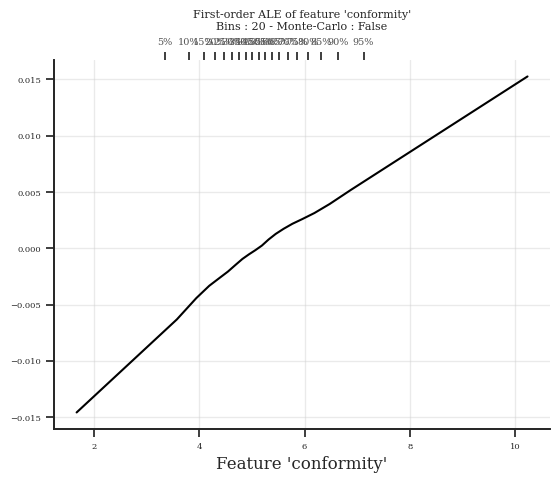

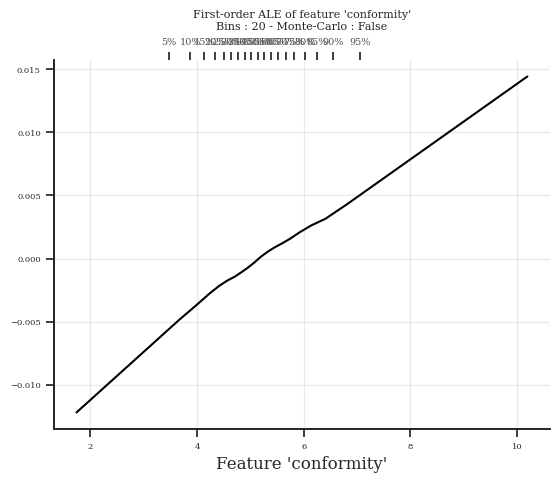

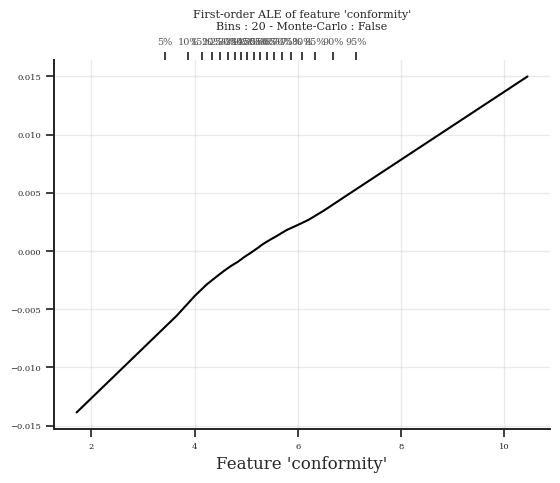

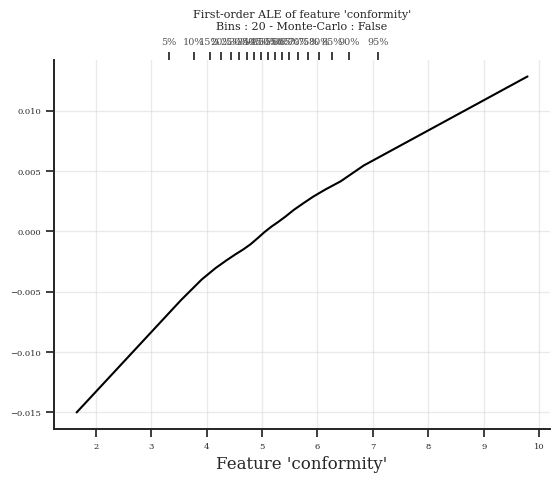

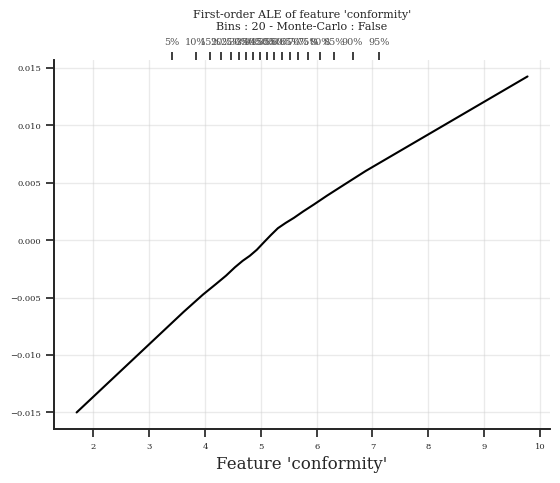

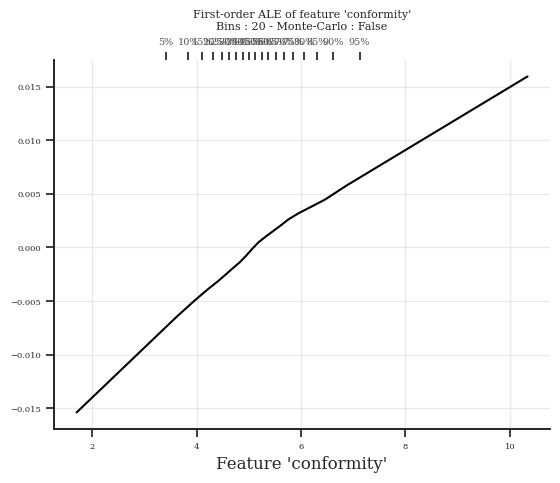

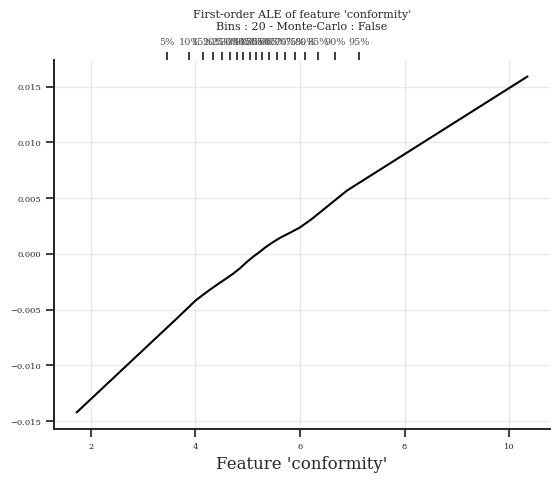

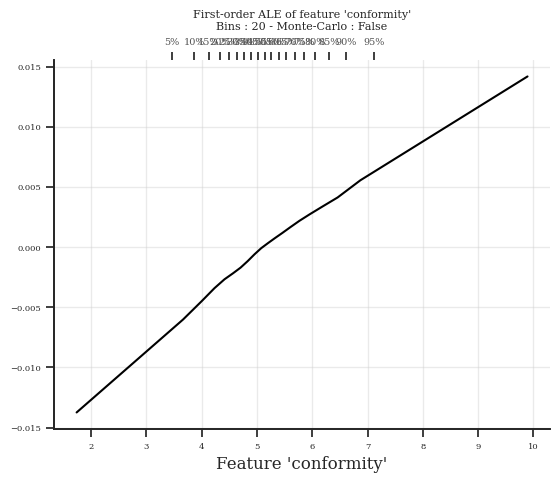

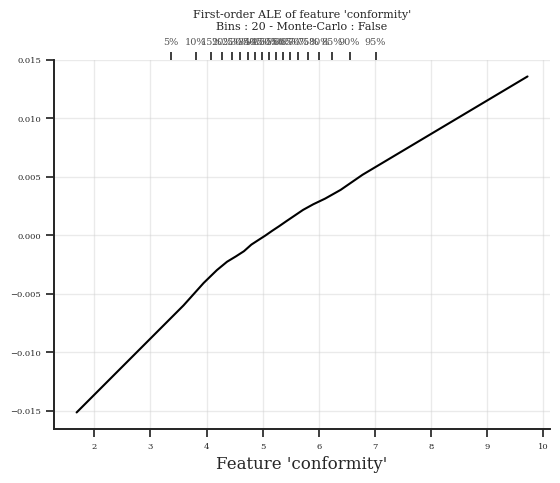

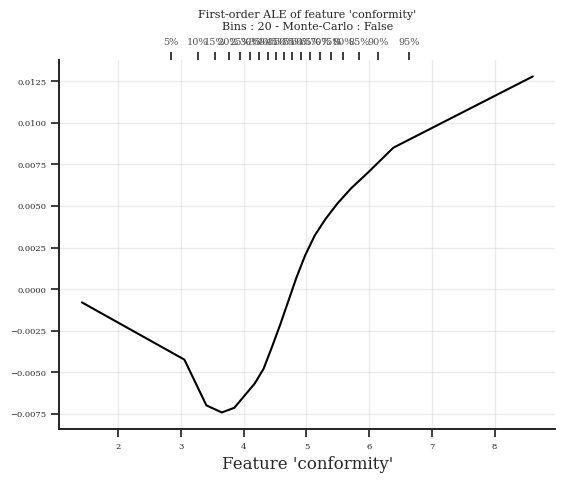

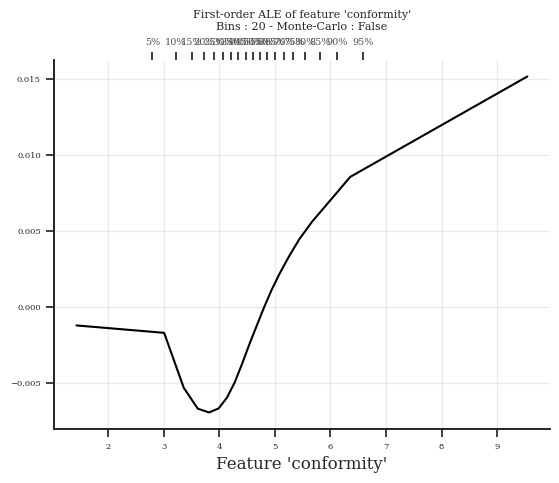

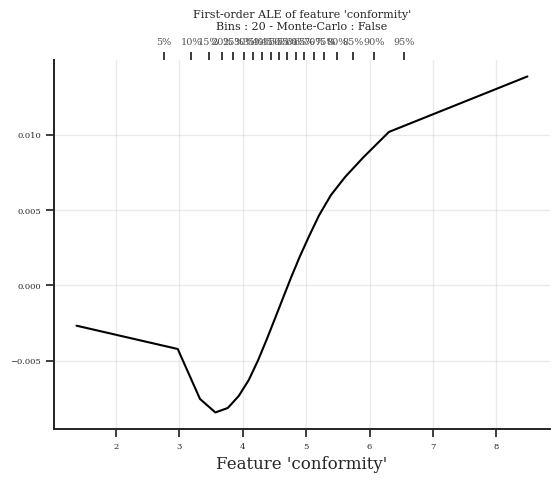

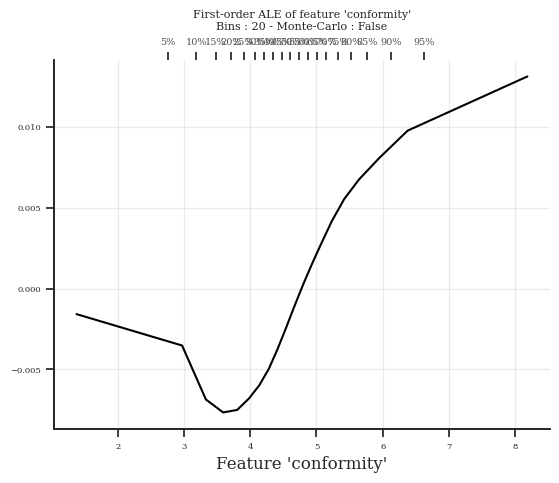

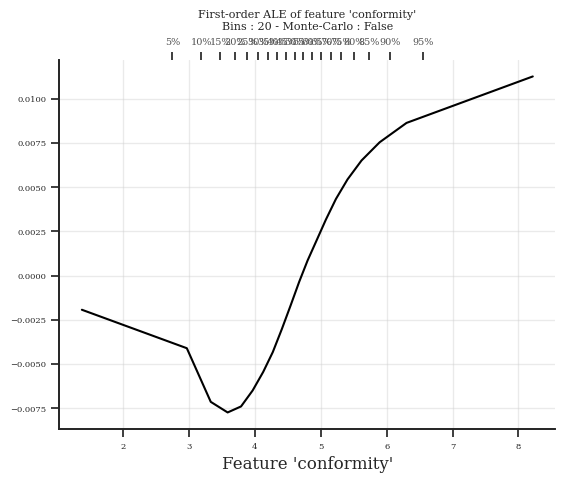

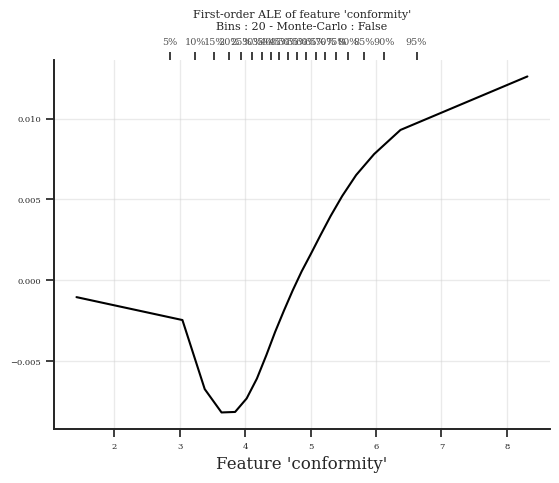

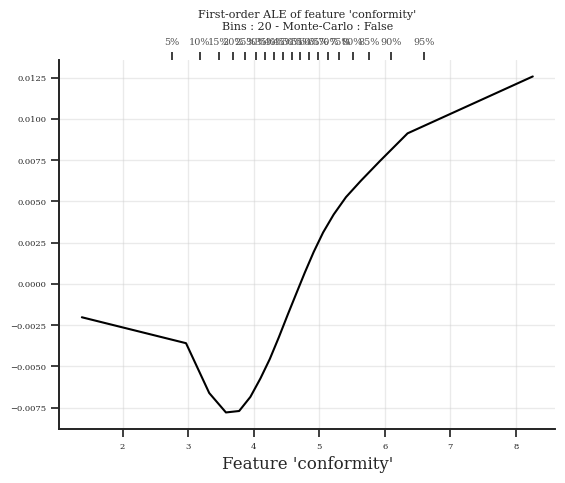

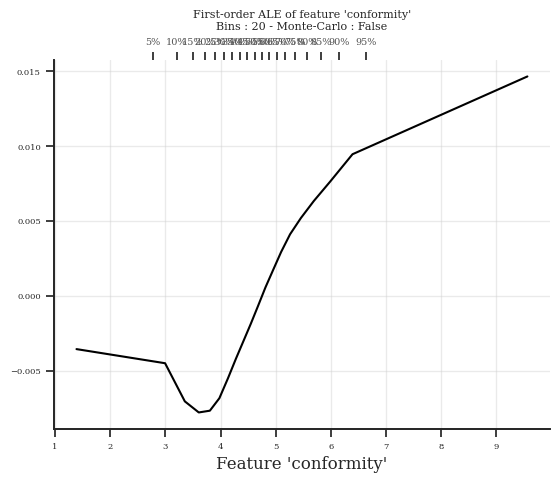

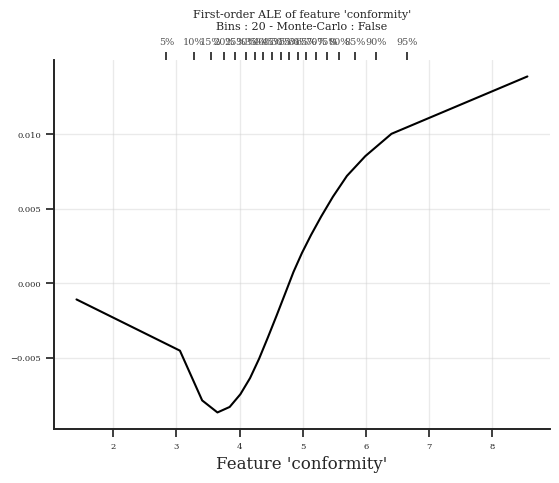

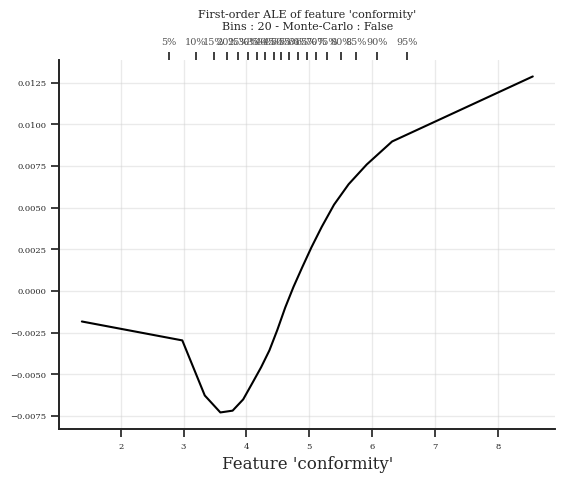

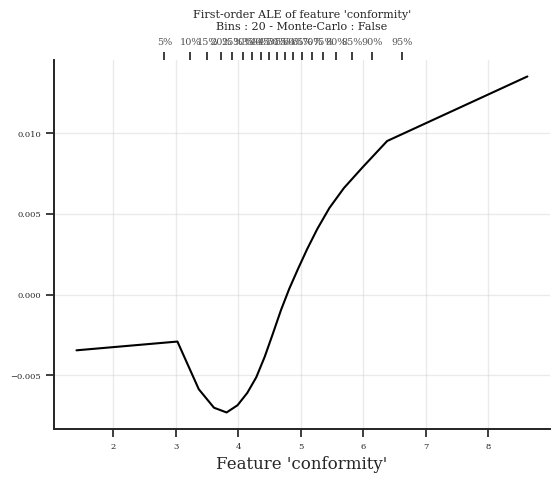

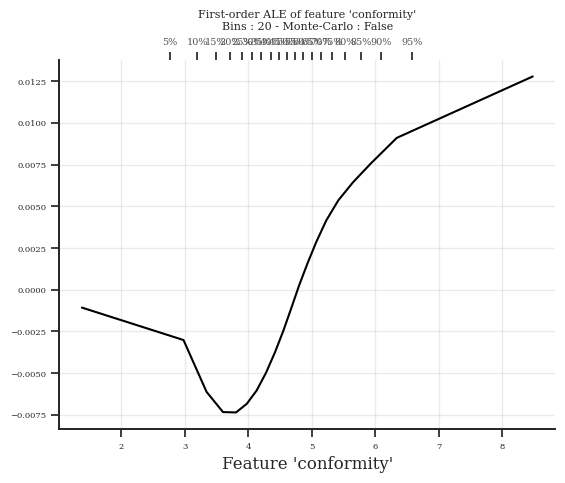

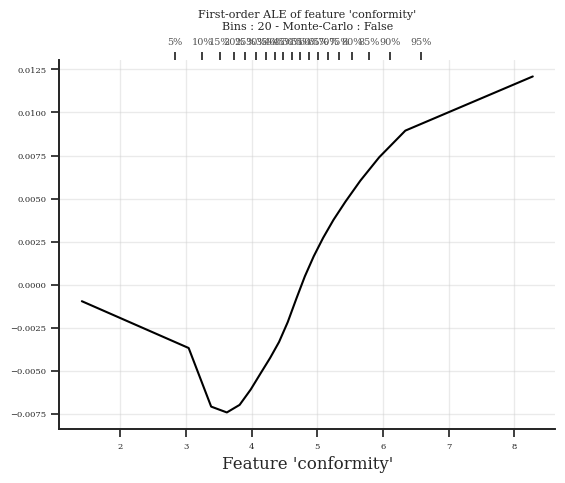

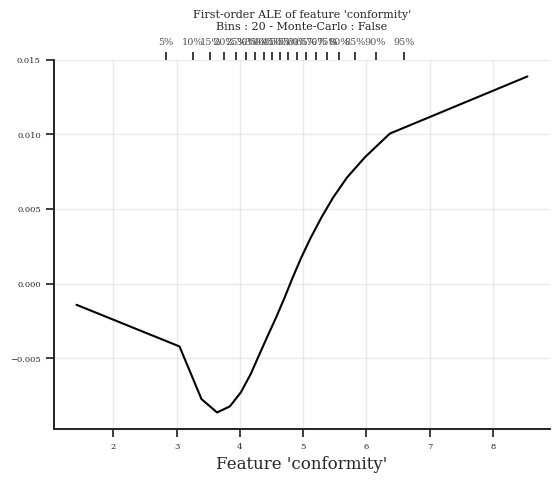

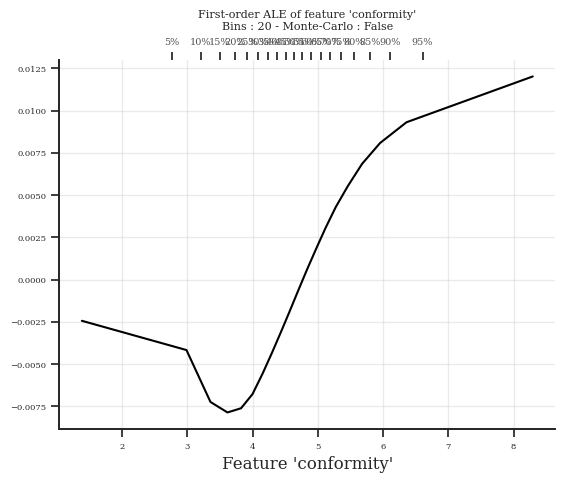

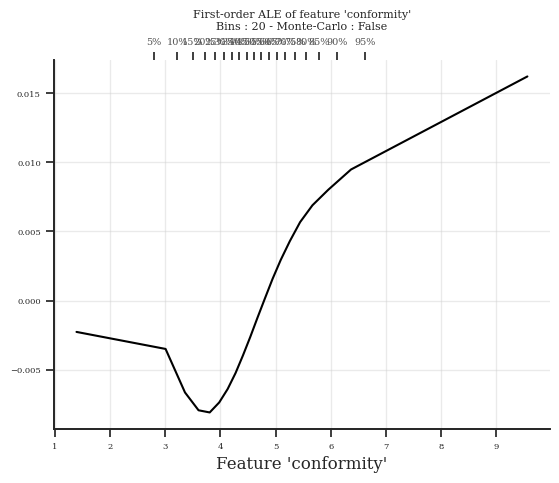

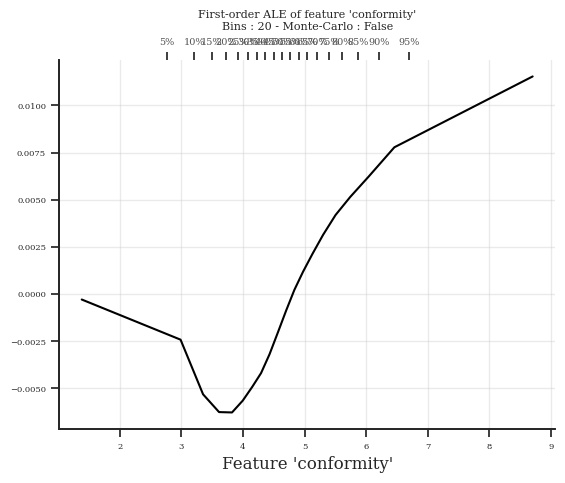

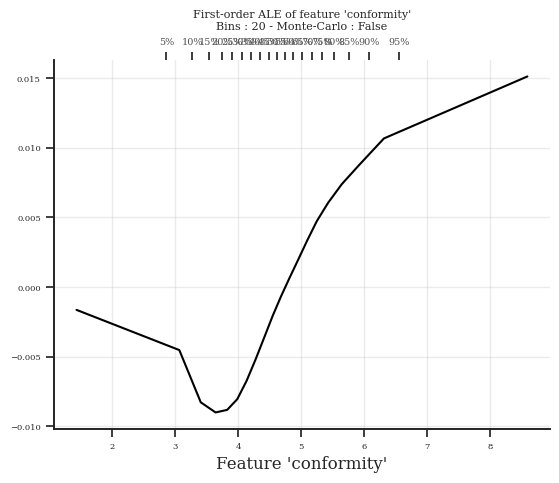

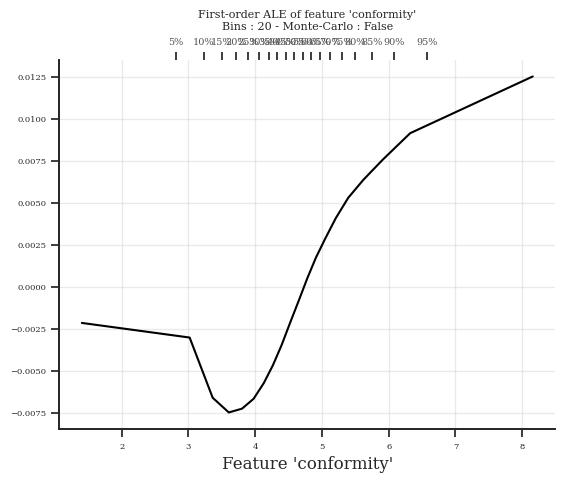

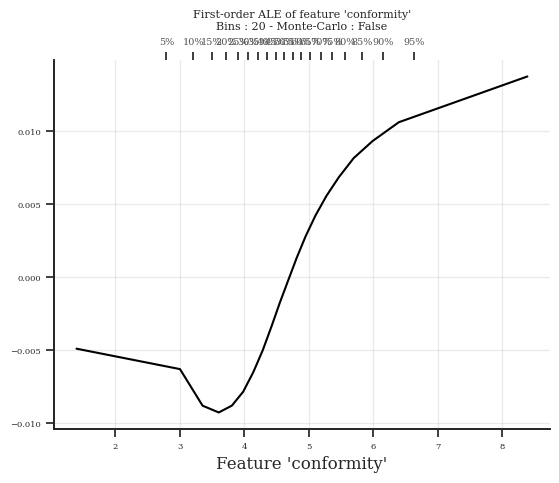

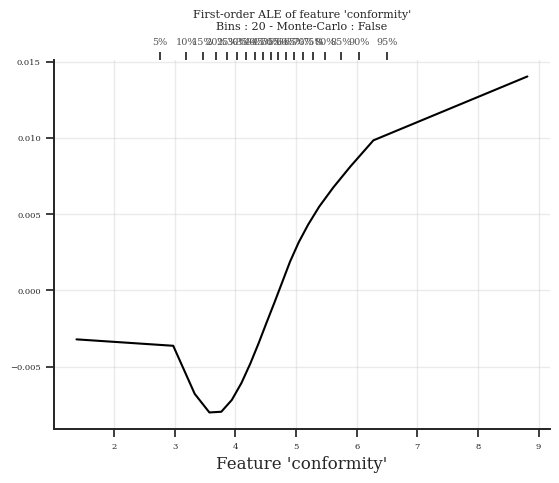

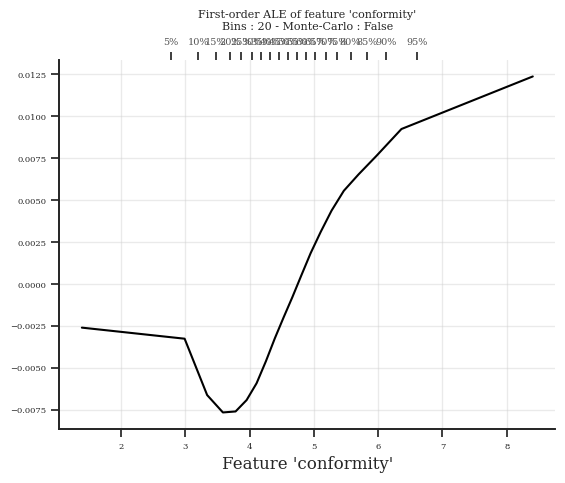

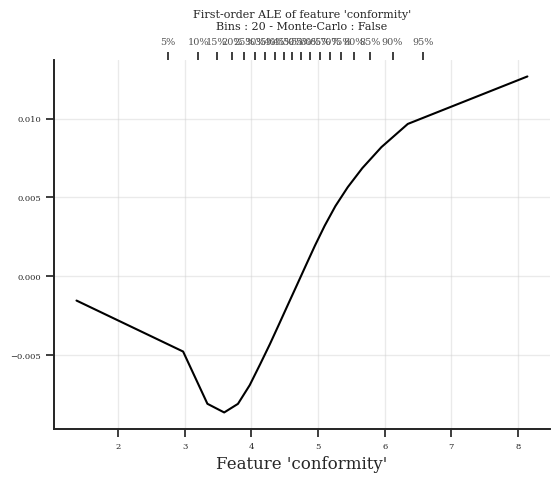

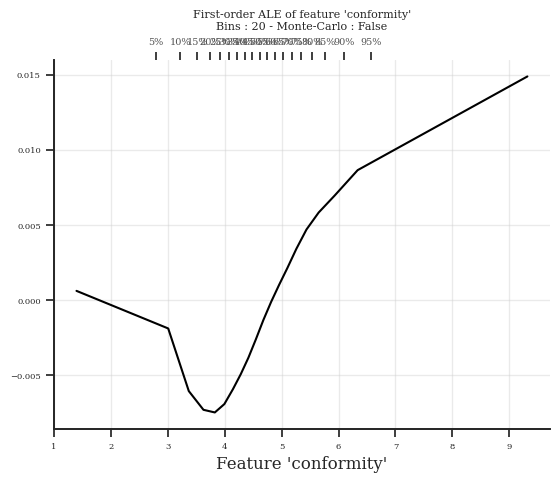

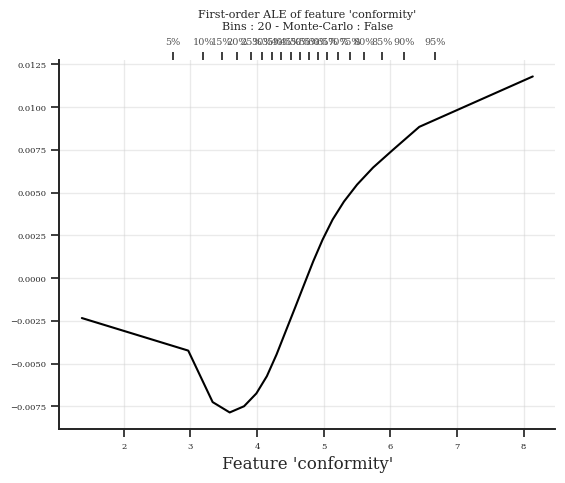

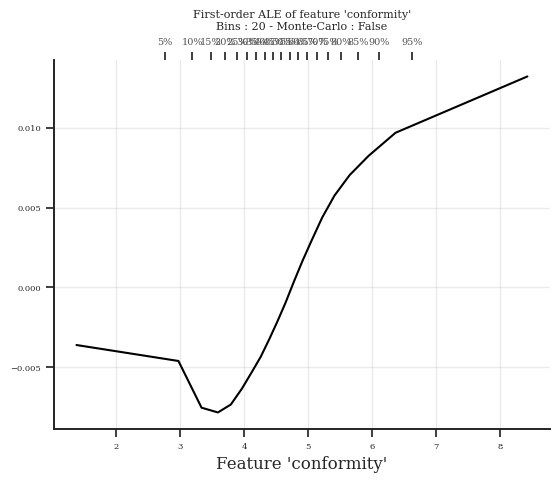

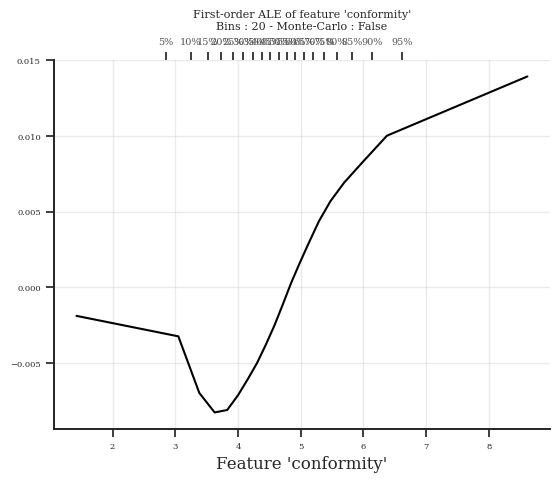

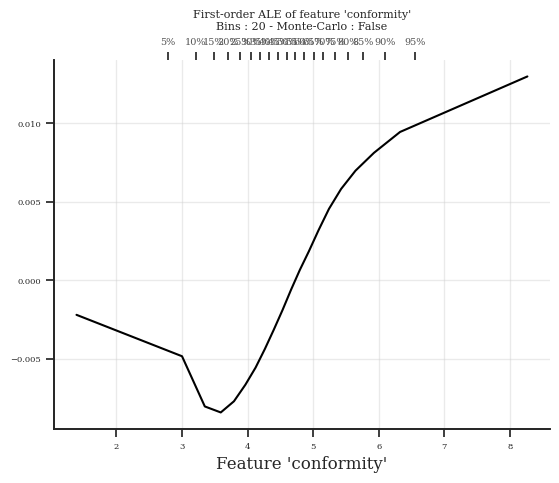

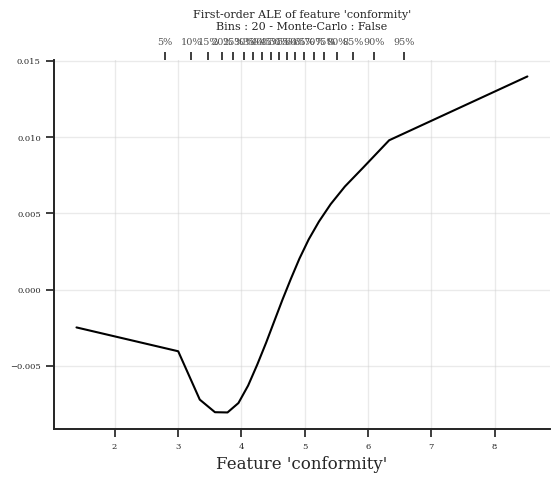

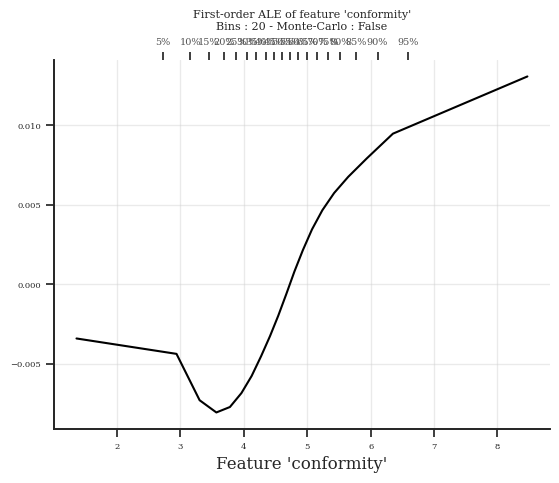

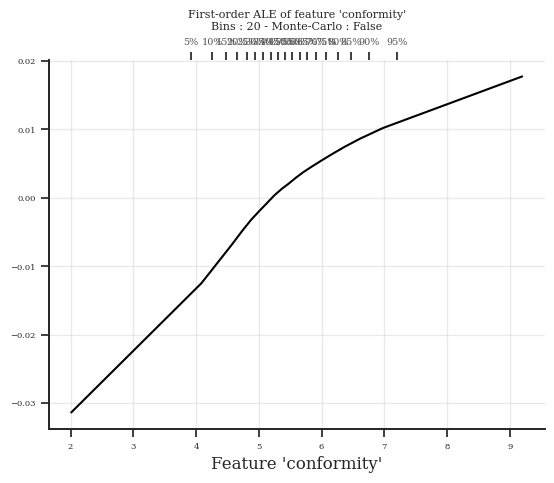

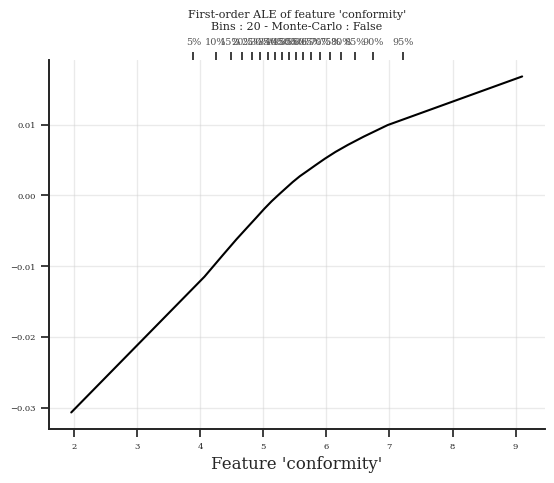

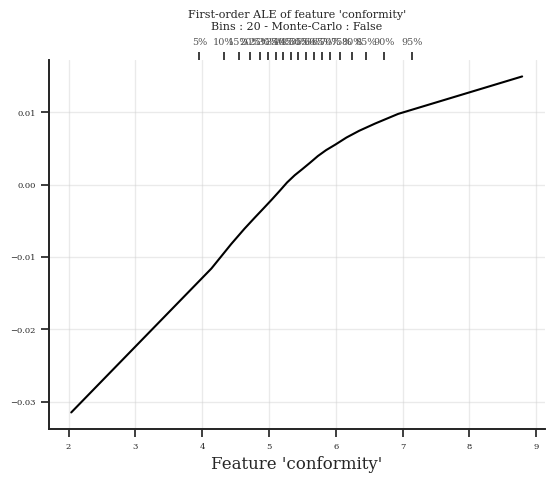

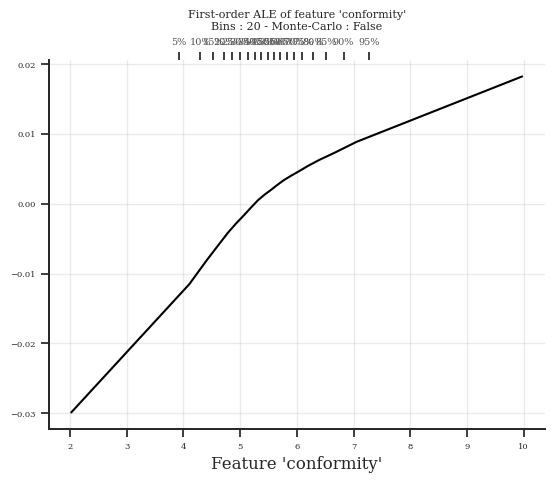

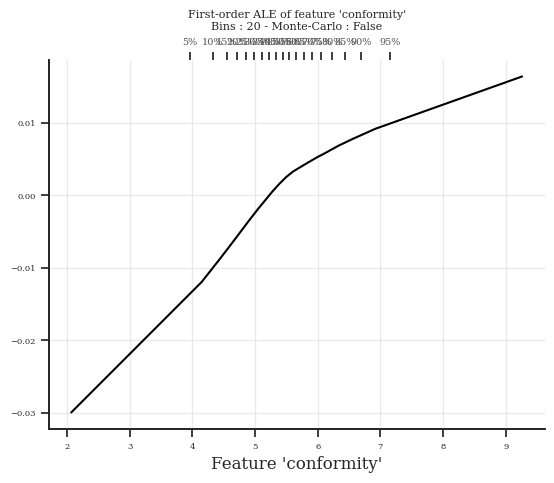

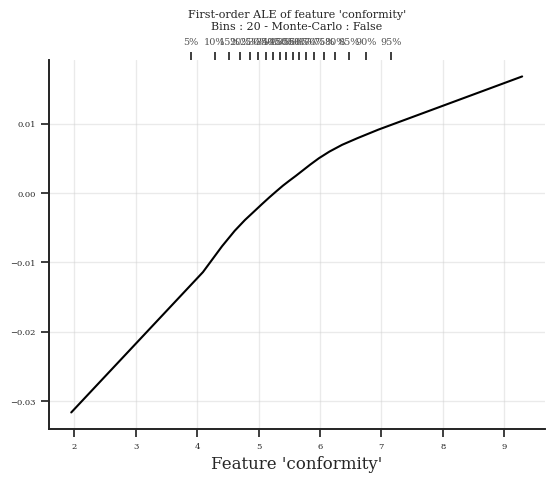

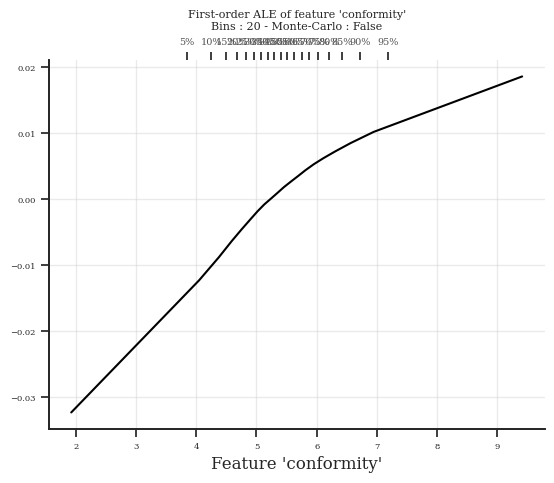

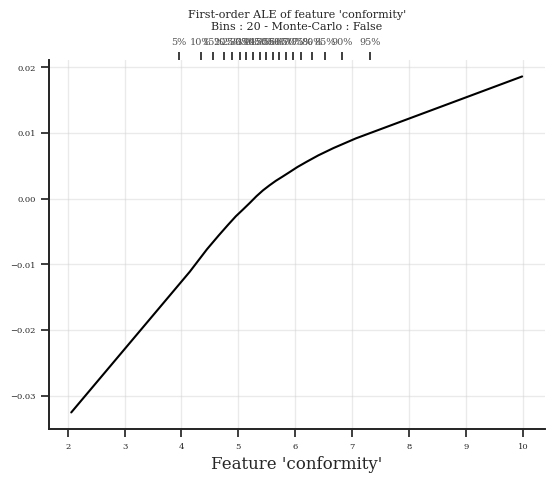

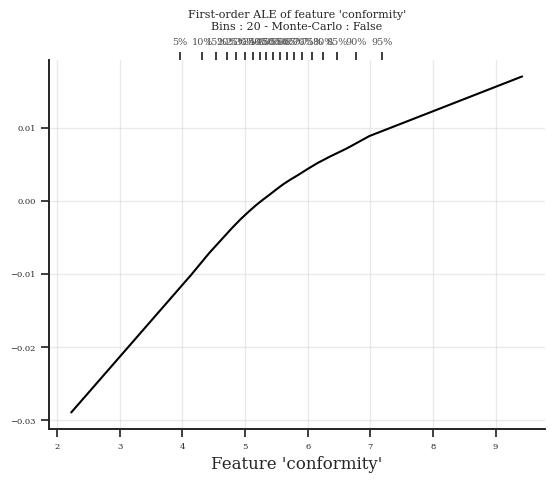

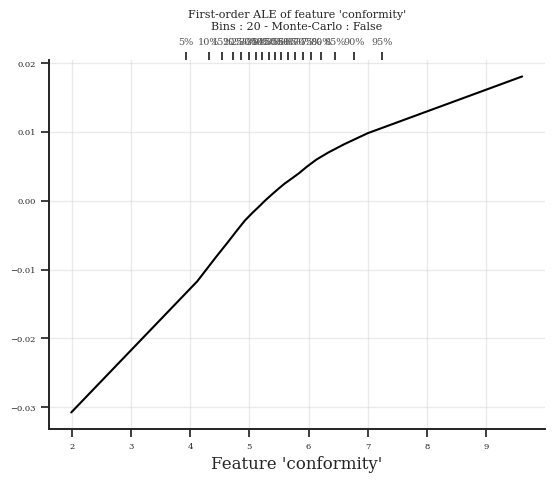

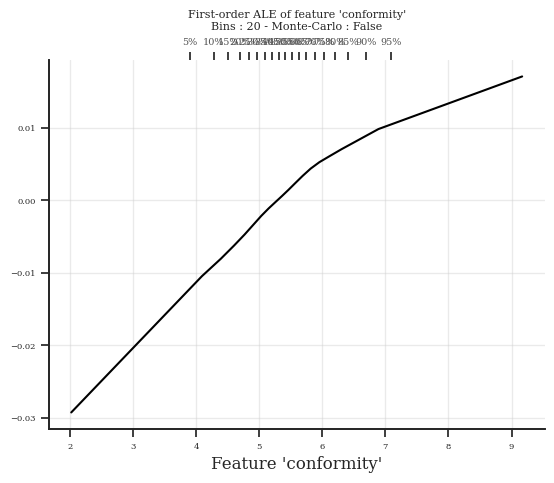

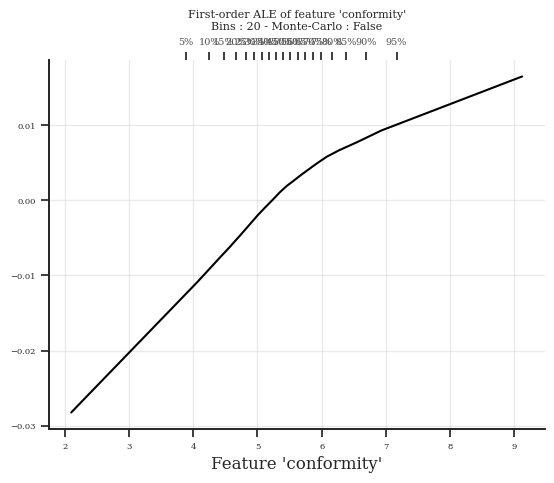

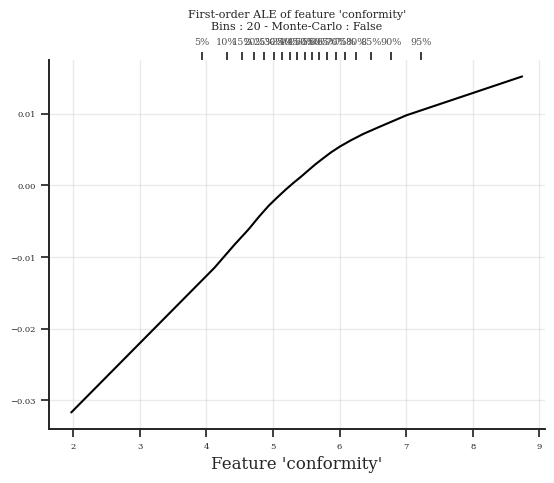

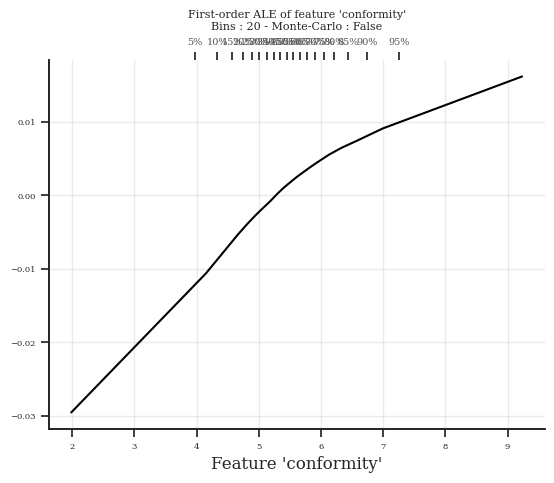

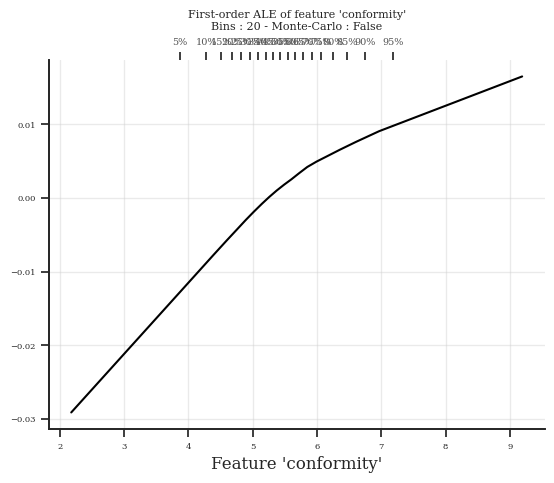

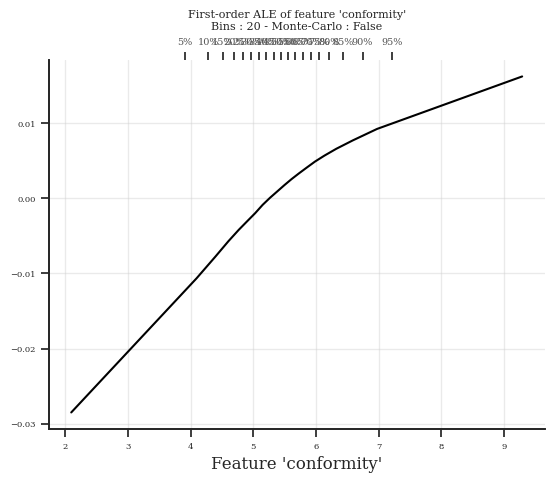

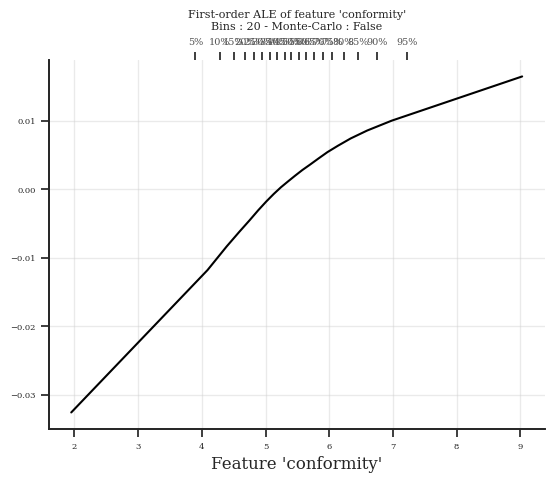

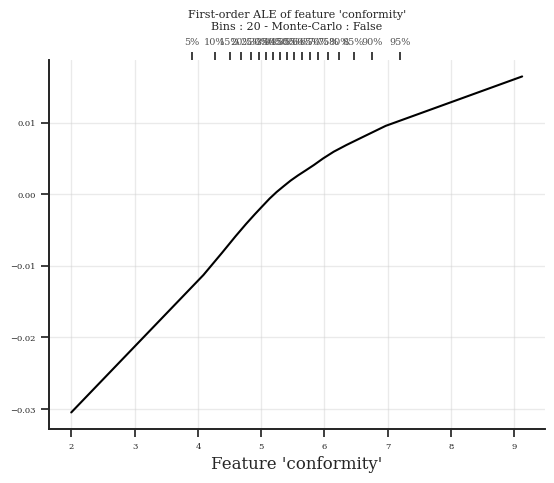

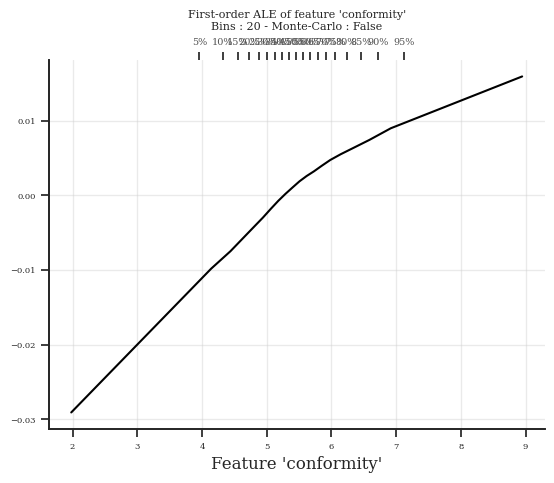

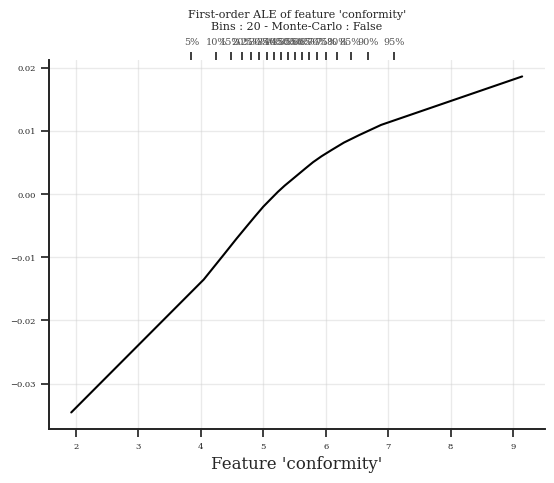

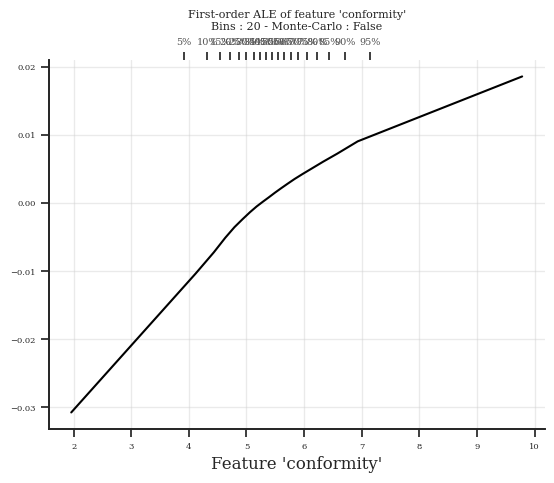

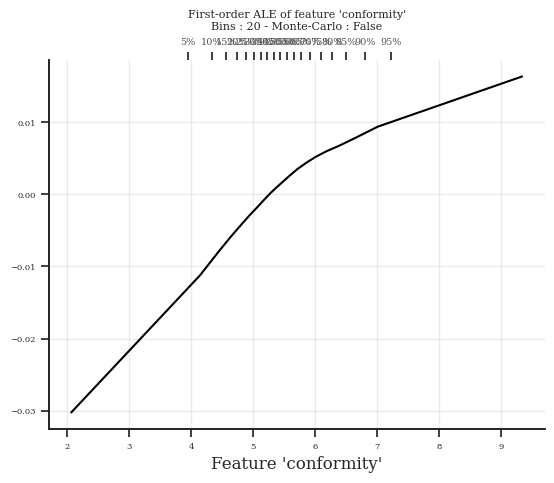

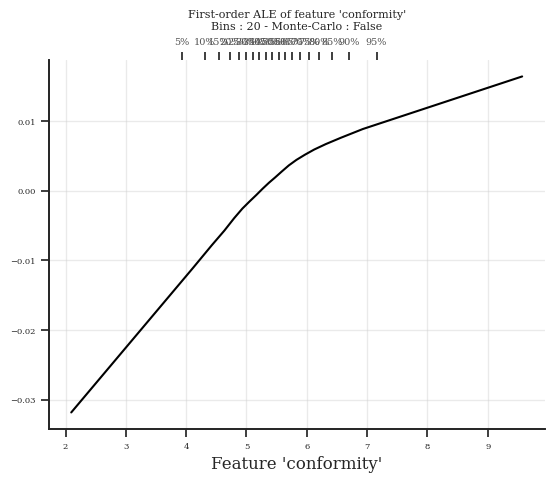

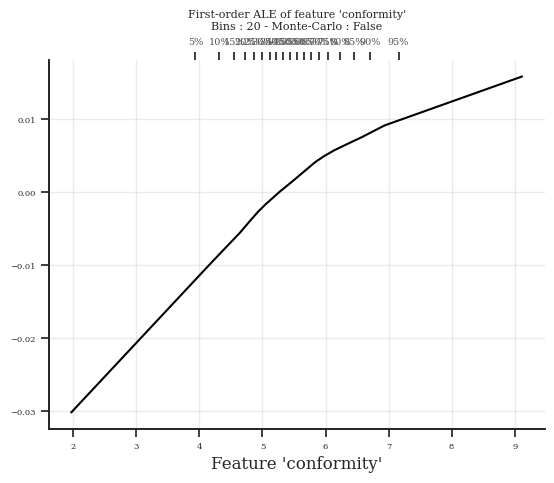

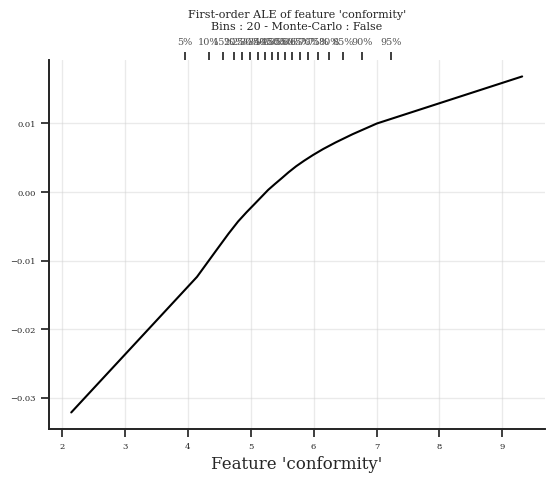

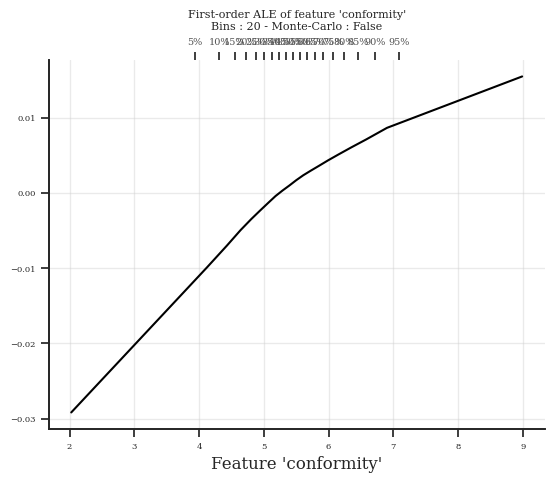

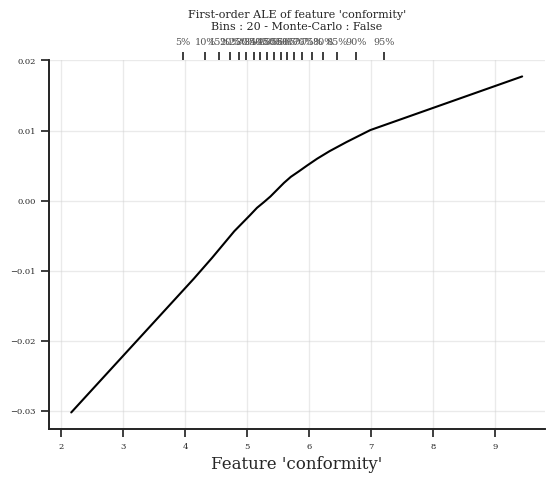

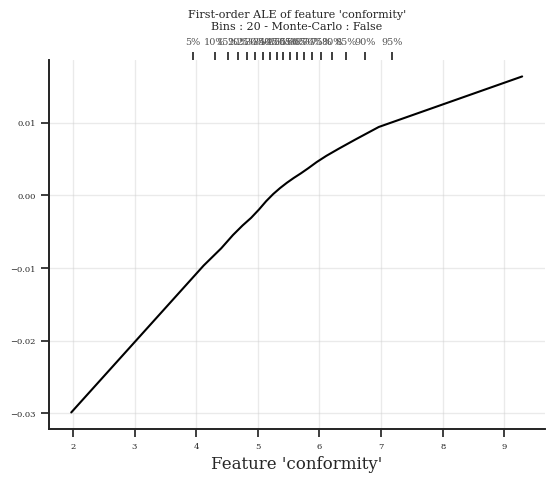

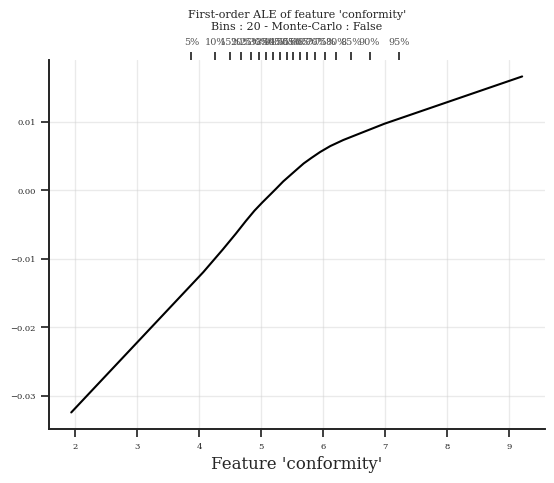

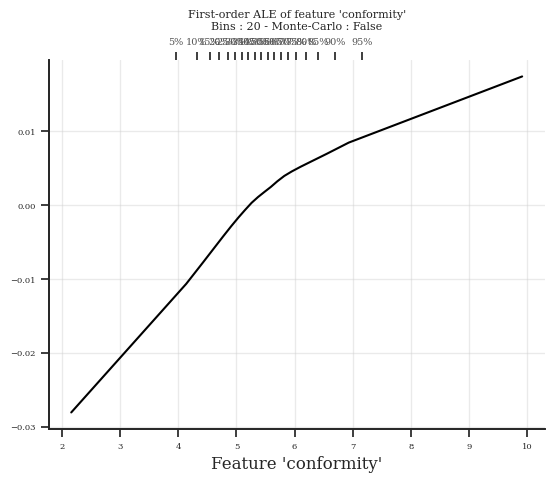

In [10]:
# 计算全局ale，转化成xarray的格式
bins = 20
quantiles = np.unique(
   np.quantile(
       dataset['treatments'].reshape(-1), np.linspace(0, 1, bins + 1), interpolation="lower"
   )
)

bins = (quantiles[1:] + quantiles[:-1]) / 2

data_vars = {}
n_bootstrap = 30


for i in [0,1,2]:
    dataset_year = [dataset19, dataset20, dataset23][i]
    year = [2019, 2020, 2023][i]
    ale = []
    
    for _ in range(n_bootstrap):
        sub_dataset = dataset_sampling(dataset_year, 1000)
        ale_fig, ale_1st, _ = compute_ale(sub_dataset, 'rmsn_'+str(exp_name), b_use_predicted_confounders=False, features = ['conformity'], default_quantiles=quantiles)
        ale.append(ale_1st)
    data_vars[f"conformity__RNN_Model_{year}__ale"] = (["n_bootstrap", f"n_bins__conformity"], ale)

data_vars[f"conformity__bin_values"] = (["n_bins__conformity"], bins)

data_vars[f"conformity"] = (["n_X"],dataset['treatments'][:,:,0].flatten())
    
ale_dataset = xr.Dataset(
    data_vars=data_vars,
    #coords={
    #    "n_bootstrap": np.arange(ale.shape[0]), 
    #    f"n_bins__{feature_name}": np.arange(quantiles.shape[0]),  
    #    "n_X": np.arange(flattened_values.shape[0]),  
    #},
    attrs={
        "estimator_output": "raw",
        "estimators used": ['RNN_Model_2019', 'RNN_Model_2020', 'RNN_Model_2023'],
        "method": "ale",
        "dimension": "1D",
        "features used": "conformity",
    }
)

ale_dataset.to_netcdf(path='figures/figure_data/fig_1c.nc')

In [12]:
# 还原SCI的log值
conformity_bin_values_log = ale_dataset['conformity__bin_values'].values
conformity_bin_values_original = np.exp(conformity_bin_values_log)-1
ale_dataset['conformity__bin_values'] = (('n_bins__conformity'), conformity_bin_values_original)

conformity_log = ale_dataset['conformity'].values
conformity_original = np.exp(conformity_log)-1
ale_dataset['conformity'] = (('n_X'), conformity_original)

# 将ALE值转换为倍数
ale_values = ale_dataset['conformity__RNN_Model_2019__ale'].values
ale_values_original = np.exp(ale_values)
ale_dataset['conformity__RNN_Model_2019__ale'] = ([('n_bootstrap'),('n_bins__conformity')], ale_values_original)

ale_values = ale_dataset['conformity__RNN_Model_2020__ale'].values
ale_values_original = np.exp(ale_values)
ale_dataset['conformity__RNN_Model_2020__ale'] = ([('n_bootstrap'),('n_bins__conformity')], ale_values_original)

ale_values = ale_dataset['conformity__RNN_Model_2023__ale'].values
ale_values_original = np.exp(ale_values)
ale_dataset['conformity__RNN_Model_2023__ale'] = ([('n_bootstrap'),('n_bins__conformity')], ale_values_original)

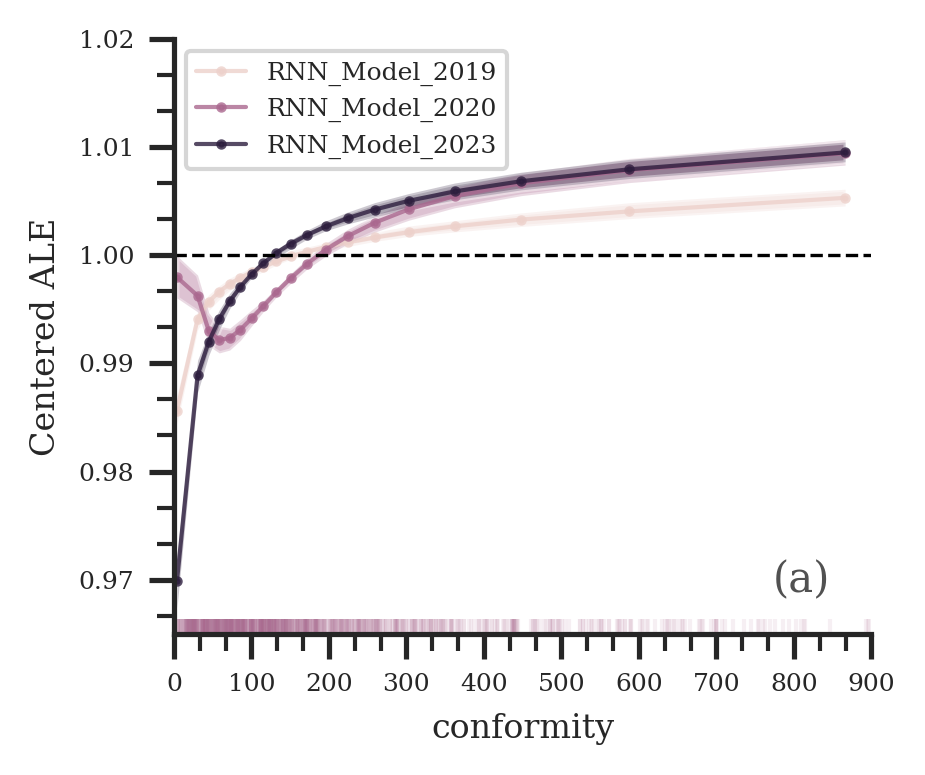

In [13]:
bins_to_keep = ale_dataset['n_bins__conformity'] != ale_dataset['n_bins__conformity'].loc[-1]
ale_dataset_select = ale_dataset.sel(n_bins__conformity=bins_to_keep)

estimator = [('RNN_Model_2019',RandomForestRegressor()),
            ('RNN_Model_2020',RandomForestRegressor()),
            ('RNN_Model_2023',RandomForestRegressor())]

explainer = skexplain.ExplainToolkit(estimator)

# 生成 cubehelix 调色盘
cubehelix_palette = sns.cubehelix_palette(n_colors=3)


fig, ax = explainer.plot_ale(
                                   ale = ale_dataset_select,
                                   features='conformity',
                                   display_units=plotting_config.display_units,
                                   display_feature_names=plotting_config.display_feature_names,
                                   line_kws={'marker': 'o', 'markersize':1.5,'linewidth':1, 'line_colors': cubehelix_palette},
hist_color = 'white', 
    edge_color= 'white'

                                  )

# ax.set_xscale('log')
ax.set_xlim(left = 0, right = 900)
# ax.set_xlim(left=1, right = 10 ** 5)
# ax.set_xlim(left=1, right = 11)
ax.set_ylim(bottom = 0.965, top = 1.02)

ax.axhline(y=1, color='black', ls='--', lw=0.8)

# ax.tick_params(axis='y', right=False, labelright=False)
# ax.tick_params(axis='y', tick1On=False, tick2On=False)
# ax.spines['bottom'].set_visible(False)
# ax.set_xticks(conformity_bin_values_original)
# ax.set_xticklabels([f'{val:.2f}' for val in conformity_bin_values_original])
ax.set_ylabel('Centered ALE', fontsize = 8)
ax.legend()

fig.axes[3].remove()
fig.axes[2].remove()
fig.axes[1].remove()



data = ale_dataset['conformity'].values
if len(data) > 1000:
    data_sample = np.random.choice(data, size=1000, replace=False)
else:
    data_sample = data
sns.rugplot(data_sample, ax=ax, color=cubehelix_palette[-2], alpha=0.1)

# plt.savefig('./figures/fig_1c_yearly_SCI_ale_1st_log_log.png',  dpi=300)
plt.savefig('./figures/fig_1c_yearly_SCI_ale_1st_SCI_log.png',  dpi=300)
# plt.savefig('./figures/fig_1c_yearly_SCI_ale_1st_raw-1.png',  dpi=300)
plt.show()

## 本地数据读取绘制&整体+三年绘制在一起

In [7]:
ale_dataset_select = xr.open_dataset('figures/figure_data/fig_2b_noCI.nc')
ale_dataset_yearly = xr.open_dataset('figures/figure_data/fig_2c.nc')

# 还原SCI的log值
conformity_bin_values_log = ale_dataset_select['conformity__bin_values'].values
conformity_bin_values_original = np.exp(conformity_bin_values_log)-1
ale_dataset_select['conformity__bin_values'] = (('n_bins__conformity'), conformity_bin_values_original)

conformity_log = ale_dataset_select['conformity'].values
conformity_original = np.exp(conformity_log)-1
ale_dataset_select['conformity'] = (('n_X'), conformity_original)

# 将ALE值转换为倍数
ale_values = ale_dataset_select['conformity__RNN_Model__ale'].values
ale_values_original = np.exp(ale_values)
ale_dataset_select['conformity__RNN_Model__ale'] = ([('n_bootstrap'),('n_bins__conformity')], ale_values_original)

# 还原SCI的log值
conformity_bin_values_log = ale_dataset_yearly['conformity__bin_values'].values
conformity_bin_values_original = np.exp(conformity_bin_values_log)-1
ale_dataset_yearly['conformity__bin_values'] = (('n_bins__conformity'), conformity_bin_values_original)

conformity_log = ale_dataset_yearly['conformity'].values
conformity_original = np.exp(conformity_log)-1
ale_dataset_yearly['conformity'] = (('n_X'), conformity_original)

# 将ALE值转换为倍数
ale_values = ale_dataset_yearly['conformity__RNN_Model_2019__ale'].values
ale_values_original = np.exp(ale_values)
ale_dataset_yearly['conformity__RNN_Model_2019__ale'] = ([('n_bootstrap'),('n_bins__conformity')], ale_values_original)

ale_values = ale_dataset_yearly['conformity__RNN_Model_2020__ale'].values
ale_values_original = np.exp(ale_values)
ale_dataset_yearly['conformity__RNN_Model_2020__ale'] = ([('n_bootstrap'),('n_bins__conformity')], ale_values_original)

ale_values = ale_dataset_yearly['conformity__RNN_Model_2023__ale'].values
ale_values_original = np.exp(ale_values)
ale_dataset_yearly['conformity__RNN_Model_2023__ale'] = ([('n_bootstrap'),('n_bins__conformity')], ale_values_original)

# === 1) 预处理（保持不变）===
last_val_overall = ale_dataset_select['n_bins__conformity'].isel(n_bins__conformity=-1)
mask_overall = ale_dataset_select['n_bins__conformity'] != last_val_overall
ale_dataset_select_trim = ale_dataset_select.isel(n_bins__conformity=mask_overall)

last_val_yearly = ale_dataset_yearly['n_bins__conformity'].isel(n_bins__conformity=-1)
mask_yearly = ale_dataset_yearly['n_bins__conformity'] != last_val_yearly
ale_dataset_yearly_trim = ale_dataset_yearly.isel(n_bins__conformity=mask_yearly)

In [8]:
ale_dataset_yearly_trim

<xarray.Dataset>
Dimensions:                          (n_bootstrap: 30, n_bins__conformity: 19,
                                      n_X: 15456000)
Dimensions without coordinates: n_bootstrap, n_bins__conformity, n_X
Data variables:
    conformity__RNN_Model_2019__ale  (n_bootstrap, n_bins__conformity) float64 ...
    conformity__RNN_Model_2020__ale  (n_bootstrap, n_bins__conformity) float64 ...
    conformity__RNN_Model_2023__ale  (n_bootstrap, n_bins__conformity) float64 ...
    conformity__bin_values           (n_bins__conformity) float32 4.005 ... 8...
    conformity                       (n_X) float32 126.1 119.3 ... 235.4 100.5
Attributes:
    estimator_output:  raw
    estimators used:   ['RNN_Model_2019', 'RNN_Model_2020', 'RNN_Model_2023']
    method:            ale
    dimension:         1D
    features used:     conformity

In [8]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, ConnectionPatch

In [9]:
# 绘图
# === 2) explainer（保持不变）===
estimator_overall = [('RNN_Model', RandomForestRegressor())]
explainer_overall = skexplain.ExplainToolkit(estimator_overall)

estimator_yearly = [
    ('RNN_Model_2019', RandomForestRegressor()),
    ('RNN_Model_2020', RandomForestRegressor()),
    ('RNN_Model_2023', RandomForestRegressor()),
]
explainer_yearly = skexplain.ExplainToolkit(estimator_yearly)

# === 3) 调色盘 ===
# cubehelix_palette = sns.cubehelix_palette(n_colors=3)
custom_palette = ['#F2C909', '#00B9AB', '#FD605C']

# === 4) 绘图 ===
# fig, ax = plt.subplots(figsize=(4,3), dpi=300)
ax = ax_b

# 1. 整体三年 ALE —— 关键改动：用 line_colors=['black']，不要用 color='black'
explainer_overall.plot_ale(
    ale=ale_dataset_select_trim,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    line_kws={'linewidth':2.5, 'line_colors':['#364548'], 'alpha':0.8},
    add_hist=False,
    plot_confidence=False,
    ax=ax
)

# 2. 分年度三条 ALE —— 仍然用 line_colors=cubehelix_palette
explainer_yearly.plot_ale(
    ale=ale_dataset_yearly_trim,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    line_kws={'marker': 'o', 'markersize': 1.5, 'linewidth': 1.3, 'line_colors': custom_palette},
    add_hist=False,
    ax=ax
)

# === 5) 统一外观 ===
ax.axhline(y=1, color='black', ls='--', lw=0.8)
ax.set_xlabel('SEI')
ax.set_xlim(left=0, right=900)
ax.set_ylim(bottom=0.985, top=1.012)
ax.set_ylabel('Centered ALE')

# === 6) 图例（手工）===
from matplotlib.lines import Line2D
legend_lines = [
    Line2D([0], [0], linewidth=2, color='#364548', markersize=2, label='Overall'), # [0.8, 0.1, 0.1]
    Line2D([0], [0], marker='o', linewidth=1.1, color=custom_palette[0], markersize=1.5, label='2019'),
    Line2D([0], [0], marker='o', linewidth=1.1, color=custom_palette[1], markersize=1.5, label='2020'),
    Line2D([0], [0], marker='o', linewidth=1.1, color=custom_palette[2], markersize=1.5, label='2023'),
]

ax.legend(handles=legend_lines, loc='lower right', frameon=False)
# plt.tight_layout()
# plt.savefig('./figures/fig_1b_global_and_yearly_SCI_ale_1st_SCI_log.png',  dpi=300)
# plt.show()


In [10]:
x1, x2, y1, y2 = 0, 50, 0.96, 0.99  # subregion of the original image
axins = ax.inset_axes(
    [0.35, 0.18, 0.20, 0.30],
    xlim=(x1, x2), ylim=(y1, y2))

explainer_yearly.plot_ale(
    ale=ale_dataset_yearly_trim,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    line_kws={'marker': 'o', 'markersize': 1.5, 'linewidth': 1.3, 'line_colors': custom_palette},
    add_hist=False,
    ax=axins
)

# ax.indicate_inset_zoom(axins, edgecolor="black")
for spine in axins.spines.values():
    spine.set_edgecolor('grey')
axins.set_xlabel('')
axins.tick_params(
    axis='both',
    colors='grey',      # 刻度线 & 刻度文字
    which='both'
)
axins.patch.set_facecolor('none')   # 背景透明
axins.patch.set_edgecolor('grey')  # 边框黑色
axins.patch.set_linewidth(0.6)

x1_box, x2_box, y1_box, y2_box = 0, 50, 0.985, 0.99

rect = Rectangle(
    (x1_box, y1_box),
    x2_box - x1_box,
    y2_box - y1_box,
    fill=False,
    edgecolor='grey',
    linewidth=0.6
)

ax.add_patch(rect)



con1 = ConnectionPatch(
    xyA=(x1_box, y2_box), coordsA=ax.transData,
    xyB=(0, 1), coordsB=axins.transAxes,
    color='grey', linewidth=0.4
)

con2 = ConnectionPatch(
    xyA=(x2_box, y1_box), coordsA=ax.transData,
    xyB=(1, 0), coordsB=axins.transAxes,
    color='grey', linewidth=0.4
)

ax.add_artist(con1)
ax.add_artist(con2)

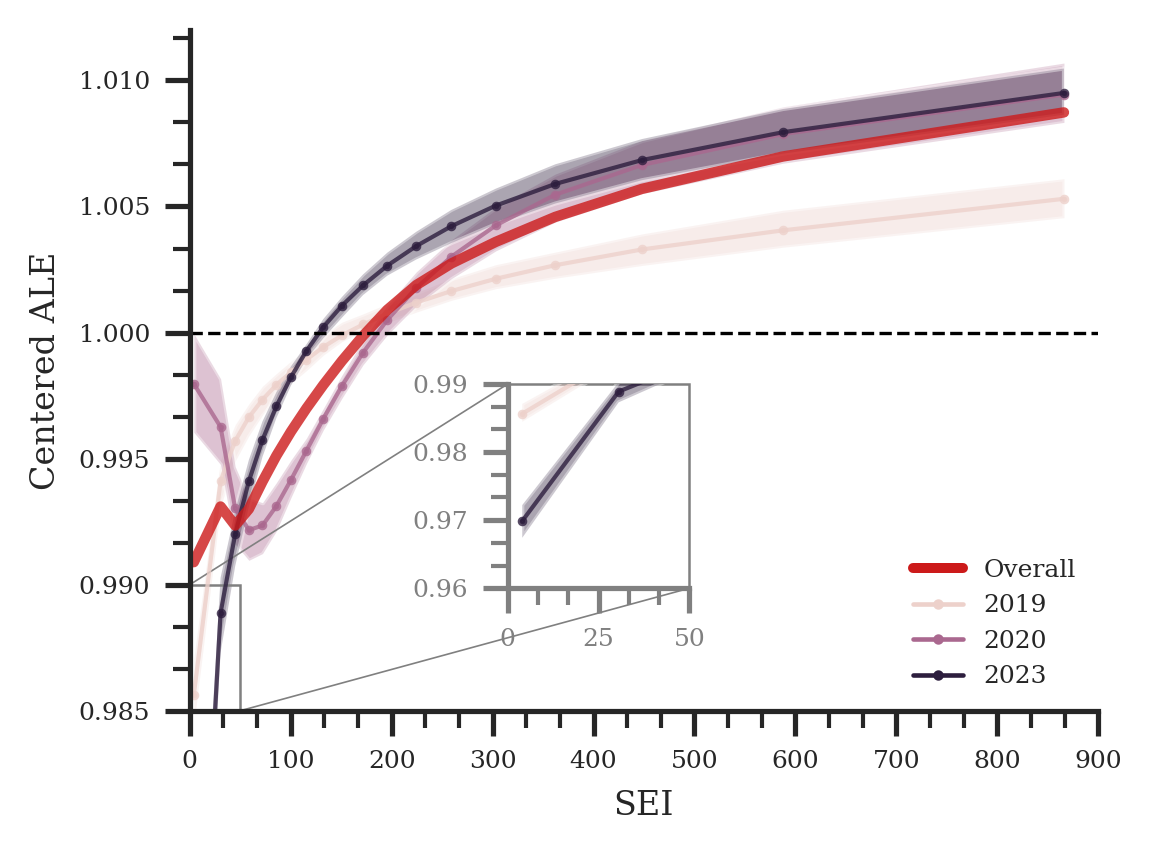

In [26]:
fig

# figure 2c
- ALER是ALE值的极值范围，反映了特征对模型预测的最大变化范围
- ALED是ALE的平均绝对值，衡量特征对模型预测的平均影响强度
- 通过比较不同年份的ALER和ALED，可以了解特征效应的年度变化

In [11]:
ale_all_dataset = xr.open_dataset('./figures/figure_data/fig_2b.nc')
ale_year_dataset = xr.open_dataset('./figures/figure_data/fig_2c.nc')

In [14]:
ale_year_dataset

<xarray.Dataset>
Dimensions:                          (n_bootstrap: 30, n_bins__conformity: 20,
                                      n_X: 15456000)
Dimensions without coordinates: n_bootstrap, n_bins__conformity, n_X
Data variables:
    conformity__RNN_Model_2019__ale  (n_bootstrap, n_bins__conformity) float64 ...
    conformity__RNN_Model_2020__ale  (n_bootstrap, n_bins__conformity) float64 ...
    conformity__RNN_Model_2023__ale  (n_bootstrap, n_bins__conformity) float64 ...
    conformity__bin_values           (n_bins__conformity) float32 ...
    conformity                       (n_X) float32 ...
Attributes:
    estimator_output:  raw
    estimators used:   ['RNN_Model_2019', 'RNN_Model_2020', 'RNN_Model_2023']
    method:            ale
    dimension:         1D
    features used:     conformity

In [12]:
ale_all = ale_all_dataset['conformity__RNN_Model__ale'].values.mean(axis=0)
ale_19 = ale_year_dataset['conformity__RNN_Model_2019__ale'].values.mean(axis=0)
ale_20 = ale_year_dataset['conformity__RNN_Model_2020__ale'].values.mean(axis=0)
ale_23 = ale_year_dataset['conformity__RNN_Model_2023__ale'].values.mean(axis=0)

In [13]:
# 计算ALER和ALED(基于全ALE数据)
ALER = []
ALED = []

ale_value_list = [ale_all,ale_19,ale_20,ale_23]
for i in range(4):  
    # Calculate ALER (min and max of ale_y)
    ale_y = ale_value_list[i]
    #counts = ale_n[i]

    aler = [np.min(ale_y), np.max(ale_y)]
    ALER.append(aler)

    # Calculate ALED (mean absolute deviation of ale_y)
    #aled = np.sum(np.abs(ale_y) * counts * ale_range[i]) / np.sum(counts * ale_range[i])
    aled = np.mean(np.abs(ale_y))
    ALED.append(aled)

In [33]:
ax_c.clear()

In [14]:
cubehelix_palette = sns.cubehelix_palette(n_colors=4)
# Create a figure and a single subplot
# fig, ax = plt.subplots(figsize=(6, 3))
ax = ax_c

# Define the positions on the y-axis for each year
positions = [0, 1, 2, 3]
# define offset value
offsets = [[-0.005,-0.005],[0, -0.005],[0,-0.005],[0.01,-0.005]]
years = ['All', 'Year 2019', 'Year 2020', 'Year 2023']

# Draw lines for ALER and ALED for each year
for pos, aler, aled in zip(positions,ALER, [x/2 for x in ALED]):
    ax.plot(aler, [pos, pos], color=cubehelix_palette[3], lw=2)  # ALER line
    ax.plot([0, aled *2], [pos, pos], color=cubehelix_palette[2], lw=6)  # ALED line segment
    ax.plot([aler[0], aler[0]], [pos - 0.1, pos + 0.1], color=cubehelix_palette[3], lw=2)  # ALER left cap
    ax.plot([aler[1], aler[1]], [pos - 0.1, pos + 0.1], color=cubehelix_palette[3], lw=2)  # ALER right cap
    # Annotate the ALED value at the center
    ax.annotate(f'ALED={aled*2:.3f}', xy=(0, pos), xytext=(0, pos - 0.2),
                ha='center', va='center', color=cubehelix_palette[2], fontsize=5)
    # Annotate the ALER range at the ends
    ax.annotate(f'ALER min={aler[0]:.3f}', xy=(aler[0], pos), xytext=(aler[0]+offsets[pos][0], pos + 0.2),
                ha='center', va='center', color=cubehelix_palette[3], fontsize=5)
    ax.annotate(f'ALER max={aler[1]:.3f}', xy=(aler[1], pos), xytext=(aler[1]+offsets[pos][1], pos + 0.2),
                ha='center', va='center',color=cubehelix_palette[3], fontsize=5)

ax.axvline(x=0,lw=1,c=cubehelix_palette[2],ls='--')
# Set y-axis to display years
ax.set_yticks(positions)
ax.set_yticklabels(years)



# Set limits for x-axis
# ax.set_xlim(-0.15, 0.05)

# Remove x-axis and ticks
# ax.xaxis.set_ticks([])

# # Hide the spines and x-axis
# for spine in ax.spines.values():
#     spine.set_visible(False)
# ax.xaxis.set_visible(False)

# Show the plot
# plt.show()

[Text(0, 0, 'All'),
 Text(0, 1, 'Year 2019'),
 Text(0, 2, 'Year 2020'),
 Text(0, 3, 'Year 2023')]

# figure 2d
- ICE用于可视化单个样本在特征变化时预测结果的变化
- 揭示不同样本对特征变化的不同响应，展示模型预测的复杂性
- 超越全局平均效应，显示个体预测的特殊模式，识别模型在不同子群体的表现
- 


## 计算生成

In [4]:
def build_individual_dataset_random(dataset, n_bootstrap=1000, seed=None):
    """
    从 dataset 中随机选取 n_bootstrap 个样本，返回新数据集和选中索引。
    
    参数：
      dataset: dict[str, np.ndarray]，每个字段形如 (N, ...)。
      n_bootstrap: int，要抽取的样本数量。
      seed: int，可选，随机种子保证复现。

    返回：
      indiv_dataset: dict[str, np.ndarray]，形状 (n_bootstrap, ...)。
      chosen_idx: np.ndarray[int]，形状 (n_bootstrap,)。
    """
    if seed is not None:
        np.random.seed(seed)
    
    # 推断样本总数
    N = min(arr.shape[0] for arr in dataset.values())
    if n_bootstrap > N:
        raise ValueError(f"n_bootstrap={n_bootstrap} 超过数据集大小 N={N}")
    
    # 随机抽样索引（无放回）
    chosen_idx = np.random.choice(N, size=n_bootstrap, replace=False)
    
    # 根据索引切片每个字段
    indiv_dataset = {k: v[chosen_idx] for k, v in dataset.items()}
    
    return indiv_dataset, chosen_idx

In [5]:
def construct_relevant_dataframe(dataset, model_name, b_use_predicted_confounders,):
    model_name = model_name + '_use_confounders_' + str(b_use_predicted_confounders)
    model_root = os.path.join('results', model_name)
    config = {'covariate_cols':['gender','age','income','weekday_0','weekday_1','weekday_2','weekday_3','weekday_4', 'weekday_5', 'weekday_6',
           'voluntary','festivals','year_0','year_1','year_2','edu','married','dist_yes','density',
                           'temperature','percipit','E1','E2'],
            'treatment_cols':['conformity'],
             }
    
    # shape of data
    num_samples, length, num_covariates = dataset['covariates'].shape
    _, _, num_treatments = dataset['treatments'].shape
    FE_predict = Feature_Engineering(dataset, for_factor_model = False)
    X = FE_predict.construct_dataframe(config)
    dataset['output_means'] = FE_predict.scale_params['outcomes'][:, 0]
    dataset['output_stds'] = FE_predict.scale_params['outcomes'][:, 1]
    # add timeline and week column
    X['timeline'] = np.tile(np.arange(length), num_samples)
    start_date = pd.Timestamp('2019-12-21')
    X['date'] = X['timeline'].apply(lambda x: start_date + pd.Timedelta(days=x))
    X['week'] = ((X['date'] - start_date).dt.days / 7).astype(int)
    # X['pid'] = np.repeat(np.arange(int(num_samples/3)), length*3)
    X['pid'] = np.repeat(np.arange(num_samples), length)
    
    # ############################################################################################
    def ale_use_predict(X, dataset, config, model_root, FE_predict, b_use_predicted_confounders):
        # change data
        mod_dataset = dataset.copy()
        # 将修改完的值添加到mod_dataset
        covariate_shapes = dataset['covariates'].shape
        mod_dataset['covariates'] = X[config['covariate_cols']].values.reshape(covariate_shapes[0],covariate_shapes[1],covariate_shapes[2])
        treatment_shapes = dataset['treatments'].shape
        mod_dataset['treatments'] = X[config['treatment_cols']].values.reshape(treatment_shapes[0],treatment_shapes[1],treatment_shapes[2])

        # 使用原来的参数做标准化
        mod_dataset = FE_predict.get_dataset_normalize(mod_dataset, num_covariates, num_treatments)
        # 调用函数预测
        predictions, _ = \
        rnn_predict(dataset=mod_dataset, MODEL_ROOT=model_root,
                    b_use_predicted_confounders=b_use_predicted_confounders)
        outputs = predictions.reshape(-1)
        del mod_dataset; gc.collect()
        return outputs
    # ############################################################################################
    # define predictor
    predictor = lambda x: ale_use_predict(x, dataset, config, model_root, FE_predict, b_use_predicted_confounders)
    
    return X, predictor

In [6]:
def compute_ice(predictor, train_set, feature, bins, default_quantiles=None):
    
    if default_quantiles is None:
        quantiles, real_bins = _get_quantiles(train_set, feature, bins)
    else:
        quantiles, real_bins = default_quantiles, len(default_quantiles) - 1
    # adjust week to match index
    #adjusted_weeks_list = [week - 1 for week in sorted(train_set['week'].unique())]

    num_quantiles = len(quantiles)
    num_samples = len(train_set)
    predictions = np.zeros((num_quantiles, num_samples))

    # 对每个个体的数据都换成bins去预测（类似pdp的做法）
    for i in range(num_quantiles):
        # 复制整个训练集
        mod_train_set = train_set.copy()
        # 只更新当前 week 的特定特征值
        mod_train_set[feature] = quantiles[i]
        # 对整个训练集进行预测并记录
        predictions[i] = predictor(mod_train_set)

        del mod_train_set; gc.collect()

    effects = np.diff(predictions, axis=0)

    # 获取每个样本的分位数位置
    indices = np.zeros((num_samples, num_quantiles - 1))

    for i in range(num_samples):
        indices[i] = (np.arange(num_quantiles - 1)).astype("int")

    indiv_groups = pd.DataFrame(
        {"pid": train_set["pid"].values.repeat(num_quantiles - 1),  
         "index": indices.flatten(), 
         "effects": effects.flatten()}
    )
    
    ale_list = []
    for _, group in indiv_groups.groupby("pid"):
        mean_effects = group.groupby("index")["effects"].mean().to_numpy().flatten()
        ale = np.array([0, *np.cumsum(mean_effects)])
        ale = _get_centres(ale)
        ale -= np.mean(ale)
        ale_list.append(ale)
        
    return np.array(ale_list)

In [7]:
def create_ice_dataset(ice_dict, quantiles, model_names, feature_name):
  
    # quantiles取平均
    quantiles = (quantiles[:-1] + quantiles[1:]) / 2

    # 创建data_vars字典
    data_vars = {}
    for model_name in model_names:
        ice = ice_dict[model_name]
        # 如果 ale 是一维数组，则添加一个维度
        if ice.ndim == 1:
            ice = ice[np.newaxis, :]
        
        data_vars[f"{feature_name}__{model_name}__ice"] = (["n_bootstrap", f"n_bins__{feature_name}"], ice)

    data_vars[f"{feature_name}__bin_values"] = ([f"n_bins__{feature_name}"], quantiles)

    # 创建 xarray.Dataset
    dataset = xr.Dataset(
        data_vars=data_vars,
        attrs={
            "estimator_output": "raw",
            "estimators used": model_names,
            "method": "ale",
            "dimension": "1D",
            "features used": [feature_name],
        }
    )
    
    # === 新增部分：提取 first_values 并添加到 X_sampled 和 features 中 ===
    # 提取 'conformity__RNN_Model__ice' 中每条 ICE 曲线的第一个值
    first_values = dataset[f"{feature_name}__{model_name}__ice"].values[:, 0]

    # 将 first_values 转换为 X_sampled 格式
    X_sampled = np.expand_dims(first_values, axis=1)  # 将一维数组转换为二维数组

    # 将 X_sampled 和 features 添加到数据集
    dataset = dataset.assign(X_sampled=(['n_bootstrap', 'feature'], X_sampled))
    dataset = dataset.assign(features=(['feature'], ['first_values']))

    return dataset

In [ ]:
dataset = load_data("../data/sample_32w_add.h5")
# dataset = load_data("../data/sample_32w.h5")

index_to_remove = dataset['covariates'].shape[2] - 5
dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

index_to_remove = dataset['covariates'].shape[2] - 5
dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

bins = 20
quantiles = np.unique(
   np.quantile(
       dataset['treatments'].reshape(-1), np.linspace(0, 1, bins + 1), interpolation="lower"
   )
)

column_2019 = 12  # index of year 2019 indicator
column_2023 = 14  # index of year 2023 indicator
# dataset19 = obtain_dataset(dataset, column_2019)
# dataset19_sample = dataset_sampling(dataset19, num_select=300000)

dataset23 = obtain_dataset(dataset, column_2023)
# dataset23_sample = dataset_sampling(dataset23, num_select=300000)

del dataset; gc.collect()

2025-10-11 18:22:34.751 | DEBUG    | ale:_first_order_ale_quant:394 - Quantiles: [ 0.         3.3735008  3.8086805  4.0829086  4.2900248  4.4586077
  4.6060205  4.736468   4.8608804  4.977294   5.0965376  5.2240458
  5.3543816  5.4910717  5.6413393  5.81414    6.0182695  6.25239
  6.5501475  7.011656  12.370489 ].


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 0it [00:00, ?it/s]2025-10-11 18:22:35.968821: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
Predicting rnn_propensity_weighted: 16it [00:01, 15.94it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 18.38it/s]
2025-10-11 18:22:38.709 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [ 0.         3.3735008  3.8086805  4.0829086  4.2900248  4.4586077
  4.6060205  4.736468   4.8608804  4.977294   5.0965376  5.2240458
  5.3543816  5.4910717  5.6413393  5.81414    6.0182695  6.25239
  6.5501475  7.011656  12.370489 ].


...

results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 18.15it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 18.29it/s]
2025-10-11 18:24:13.212 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [ 0.26402307  3.9537804   4.3081393   4.5338974   4.7059255   4.852238
  4.9786367   5.0953045   5.2002244   5.304856    5.406666    5.5091634
  5.620968    5.7347393   5.8582745   5.9944935   6.170487    6.391103
  6.679711    7.1525345  11.1046715 ].


[2.1089017 4.13096   4.4210186 4.619911  4.779082  4.9154377 5.0369706
 5.147764  5.25254   5.3557606 5.4579144 5.5650654 5.6778536 5.796507
 5.926384  6.08249   6.280795  6.535407  6.9161224 9.128603 ]


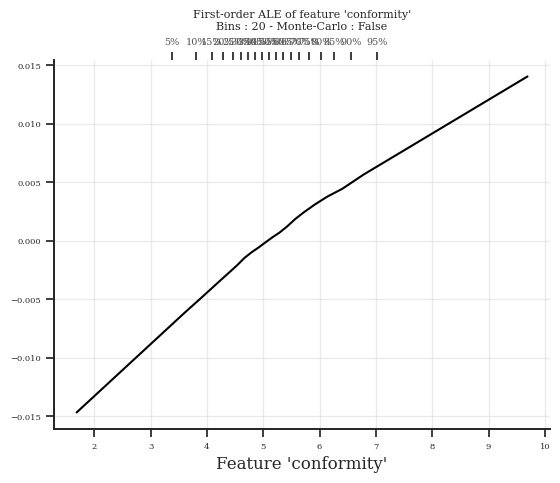

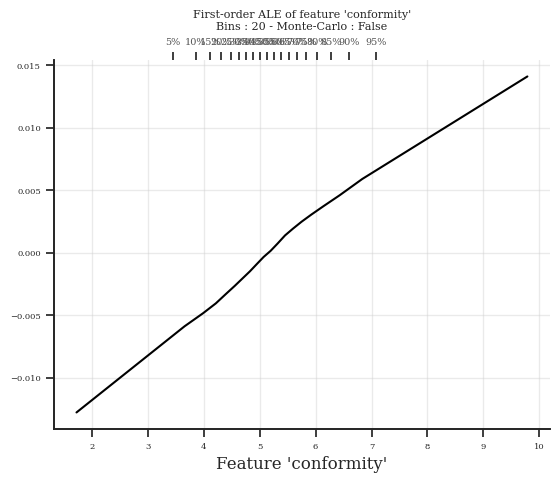

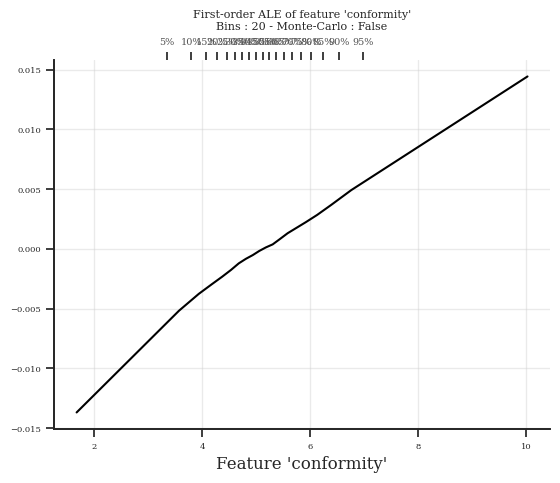

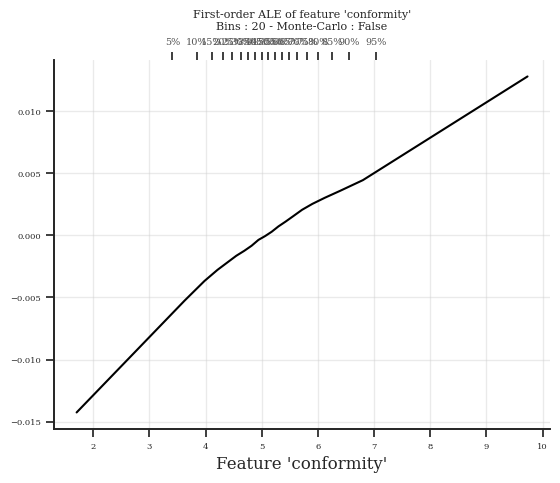

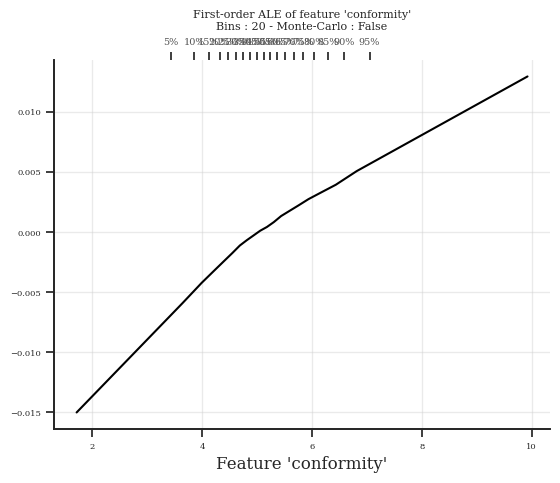

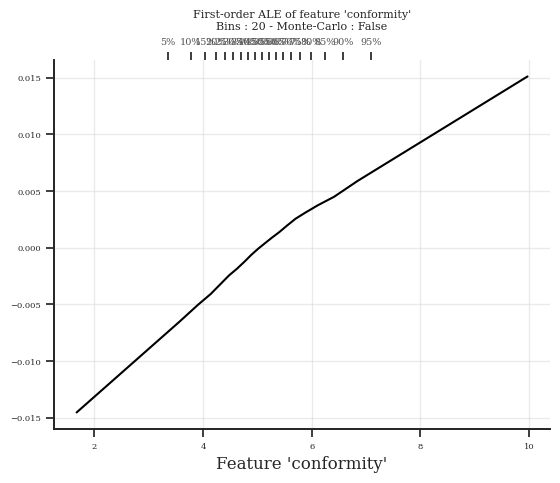

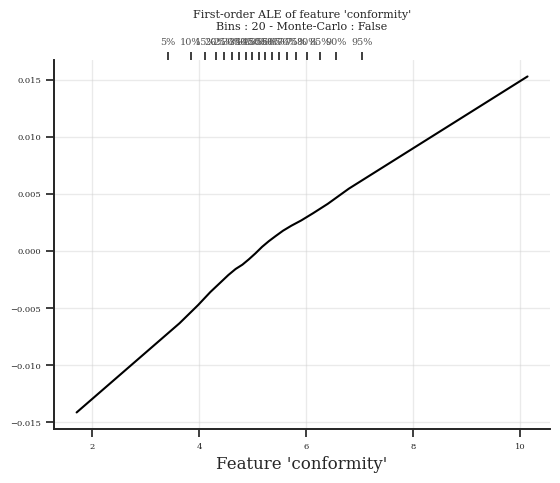

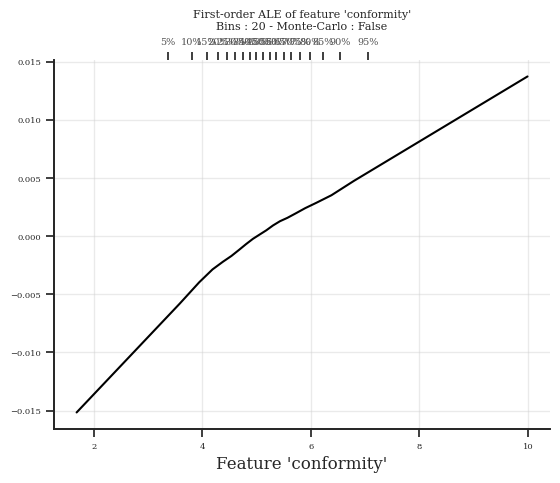

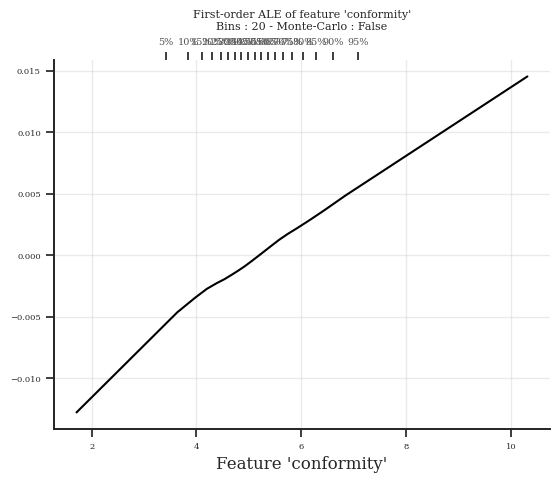

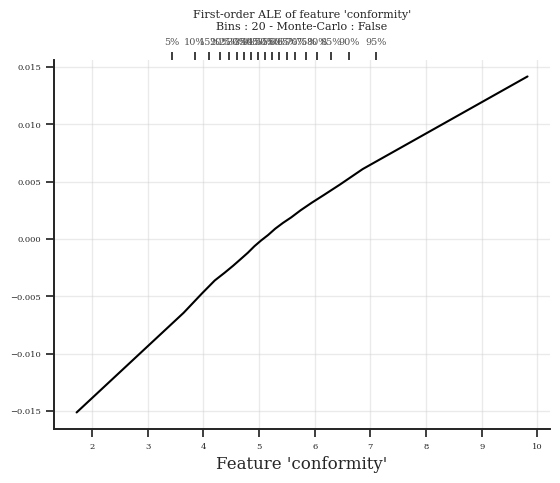

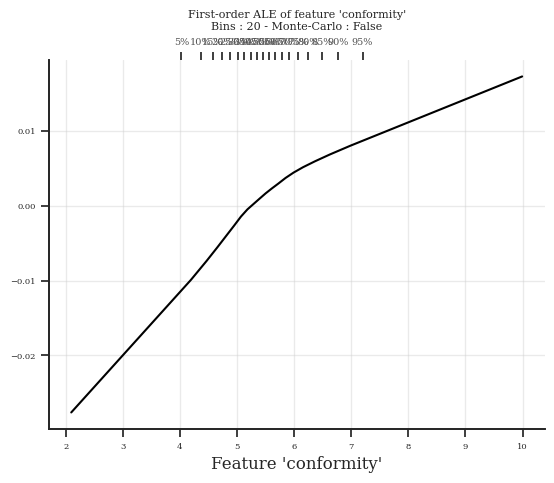

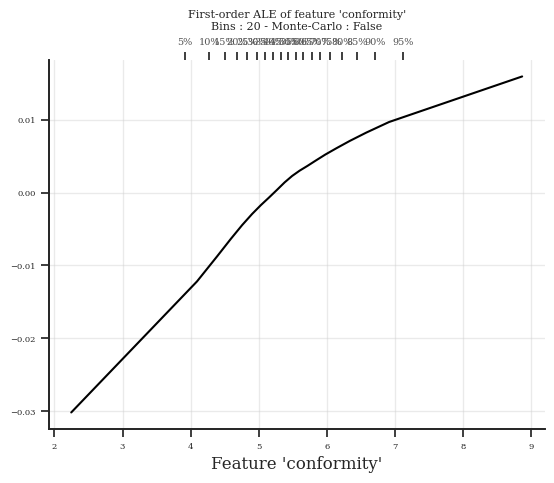

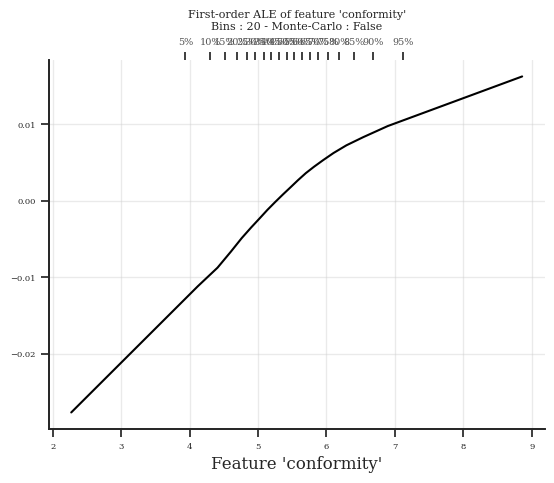

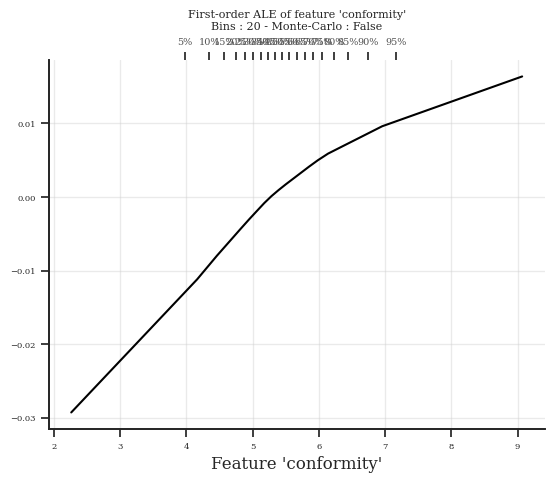

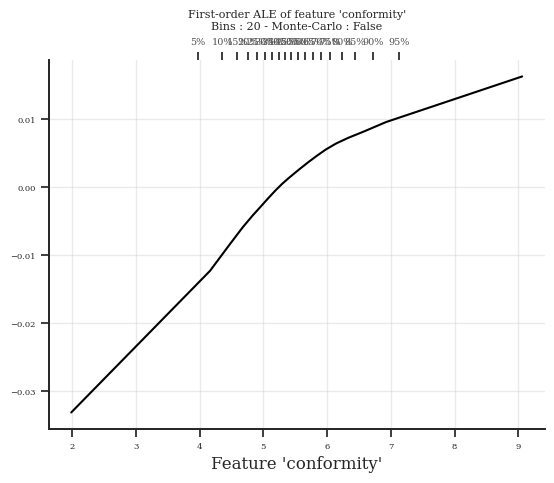

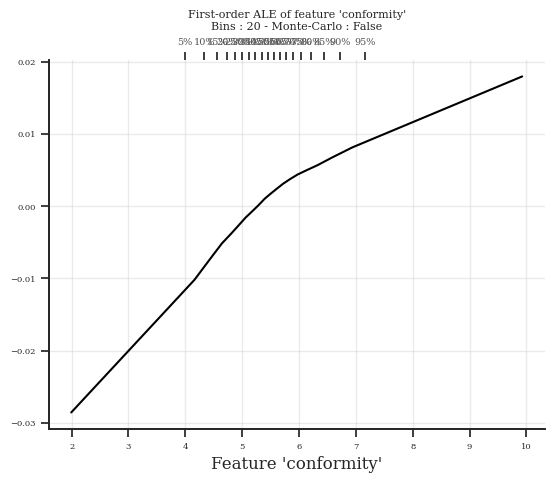

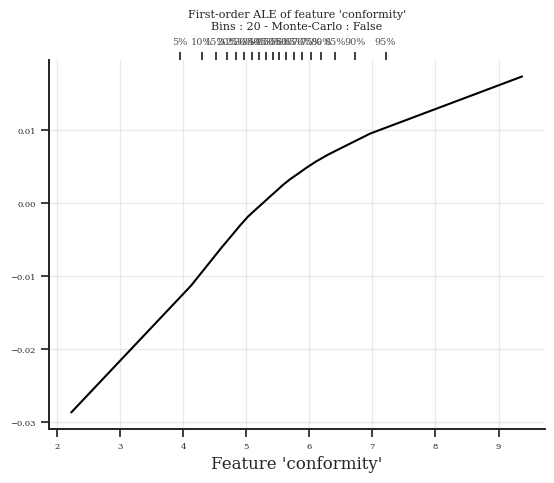

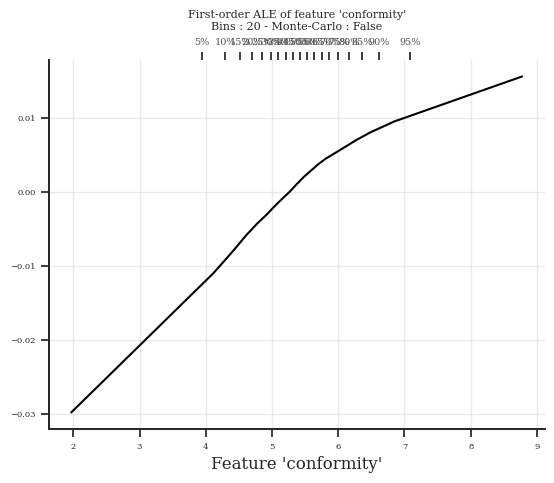

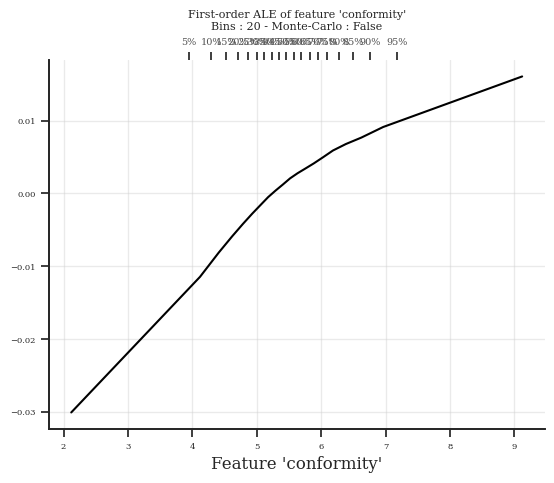

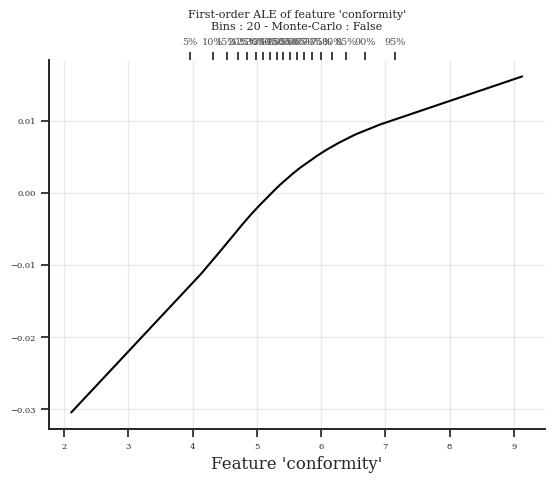

In [12]:
exp_name = "base_model_optimal_v2"

ALE_1ST_19 = {'RNN_Model': []}
ALE_1ST_23 = {'RNN_Model': []}
n_bootstrap = 10

for dataset, year in zip([dataset19, dataset23], ['19', '23']):
    for _ in range(n_bootstrap):
        sub_dataset = dataset_sampling(dataset, 1000)
        _, ale_1st, _ = compute_ale(sub_dataset, 'rmsn_' + str(exp_name), b_use_predicted_confounders=False, features=['conformity'], default_quantiles=quantiles)
        eval(f'ALE_1ST_{year}')['RNN_Model'].append(ale_1st)


ALE_1ST_19['RNN_Model'] = np.array(ALE_1ST_19['RNN_Model'])
ALE_1ST_23['RNN_Model'] = np.array(ALE_1ST_23['RNN_Model'])
ale_dataset_19 = create_ale_dataset(ALE_1ST_19, quantiles, dataset19['treatments'], ['RNN_Model'], 'conformity')
ale_dataset_23 = create_ale_dataset(ALE_1ST_23, quantiles, dataset23['treatments'], ['RNN_Model'], 'conformity')

In [12]:
# 获取个体数据集
n_bootstrap = 110000
dataset = dataset23
ICE = {
    'ICE_19': [],
    'ICE_23': []
}
ice_name = 'ICE_23'
 
# 初始化新数据集
indiv_dataset = {
    'covariates': np.zeros((n_bootstrap, 161, 23), dtype='float32'),
    'outcomes': np.zeros((n_bootstrap, 161, 1), dtype='float32'),
    'sequence_length': np.zeros((n_bootstrap,), dtype='int64'),
    'treatments': np.zeros((n_bootstrap, 161, 1), dtype='float32')
}
# for index in range(n_bootstrap):
indiv_dataset, chosen_idx = build_individual_dataset_random(
dataset,
n_bootstrap=n_bootstrap,   # 若不需要强行 32000，可用 overall=None 自动推断
)
print("样本选取成功")
#         indiv_data = select_indiviudal_from_dataset(dataset, index)
#         start_idx = index * 3
#         end_idx = start_idx + 3

#         indiv_dataset['covariates'][start_idx:end_idx] = indiv_data['covariates']
#         indiv_dataset['outcomes'][start_idx:end_idx] = indiv_data['outcomes']
#         indiv_dataset['sequence_length'][start_idx:end_idx] = indiv_data['sequence_length']
#         indiv_dataset['treatments'][start_idx:end_idx] = indiv_data['treatments']

indiv_dataframe, predictor = construct_relevant_dataframe(indiv_dataset,'rmsn_' + str(exp_name), b_use_predicted_confounders=False)
print("dataframe构建成功")

ice = compute_ice(predictor, 
                  indiv_dataframe, 
                  ['conformity'], 
                  20, 
                  quantiles)
ICE[ice_name] = ice

样本选取成功
dataframe构建成功
results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 0it [00:00, ?it/s]2025-10-11 20:29:12.463238: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
Predicting rnn_propensity_weighted: 1719it [00:45, 37.93it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 1719it [00:44, 38.95it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


...

INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 1719it [00:44, 38.85it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 1719it [00:43, 39.29it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 1719it [00:45, 37.82it/s]


In [ ]:
# ice_dataset_19 = create_ice_dataset({'RNN_Model':ICE['ICE_19']}, quantiles, ['RNN_Model'], 'conformity')
ice_dataset_23 = create_ice_dataset({'RNN_Model':ICE['ICE_23']}, quantiles, ['RNN_Model'], 'conformity')

# save the sample ice data
# ale_dataset_19.to_netcdf(path='figures/figure_data/fig_1d_ale19.nc')
# ale_dataset_23.to_netcdf(path='figures/figure_data/fig_1d_ale23.nc')
# ice_dataset_19.to_netcdf(path='figures/figure_data/fig_1d_ice19_11w.nc')
ice_dataset_23.to_netcdf(path='figures/figure_data/fig_1d_ice23_11w.nc')


## 本地数据绘图

In [15]:
ale_dataset_19 = xr.open_dataset('figures/figure_data/fig_2d_ale19.nc')
ale_dataset_23 = xr.open_dataset('figures/figure_data/fig_2d_ale23.nc')

ice_dataset_19 = xr.open_dataset('figures/figure_data/fig_2d_ice19_11w_new.nc')
ice_dataset_23 = xr.open_dataset('figures/figure_data/fig_2d_ice23_11w_new.nc')

### 聚类做法

In [16]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

In [17]:
# what about clustering via slope?
def compute_global_slope(ice, x):
    x = np.asarray(x)
    # 为了数值稳定，可以对 x 做标准化（不改 y，只改坐标系）
    x_scaled = (x - x.mean()) / x.std()
    
    # 设计矩阵： [x_scaled, 1]
    X = np.vstack([x_scaled, np.ones_like(x_scaled)]).T      # shape (n_bins, 2)

    # 最小二乘闭式解：beta = (X^T X)^(-1) X^T Y
    # Y 是所有曲线堆成的矩阵: shape (n_bins, n_samples)
    Y = ice.T                                                # (n_bins, n_samples)
    
    XtX_inv = np.linalg.inv(X.T @ X)                         # (2, 2)
    beta = XtX_inv @ X.T @ Y                                 # (2, n_samples)
    
    slopes = beta[0, :]                                      # 第一行是斜率
    return slopes

In [18]:
# adopt K-means to classify ice curves
ice19 = ice_dataset_19["conformity__RNN_Model__ice"].values  # shape (110000, 20)
ice23 = ice_dataset_23["conformity__RNN_Model__ice"].values
bins19 = ice_dataset_19["conformity__bin_values"].values
bins23 = ice_dataset_23["conformity__bin_values"].values 

In [19]:
slopes19 = compute_global_slope(ice19, bins19)
slopes23 = compute_global_slope(ice23, bins23)

# --------- 首先划分出 反从众（斜率 < 0） ----------
anti_mask_19 = slopes19 < 0
anti_mask_23 = slopes23 < 0

# 给 2019 的初始标签
labels19 = np.full(len(slopes19), -1)
labels19[anti_mask_19] = 0   # 0 → 反从众

# 给 2023 初始标签
labels23 = np.full(len(slopes23), -1)
labels23[anti_mask_23] = 0   # 0 → 反从众

# 2019 的正斜率部分（候选从众）

# --------- 在正斜率样本中做 2 类 GMM ----------
# --------- 1. 对 2019 正斜率做模型训练并映射 ---------
slopes19_pos = slopes19[~anti_mask_19].reshape(-1, 1)

# gmm_pos = GaussianMixture(n_components=2, random_state=0)
# gmm_pos.fit(slopes19_pos)
# labels_pos_19 = gmm_pos.predict(slopes19_pos)

kmeans = KMeans(n_clusters=2, random_state=0).fit(slopes19_pos)
labels_pos_19 = kmeans.labels_

# 计算 2019 两个 cluster 的平均斜率
means19 = [
    (0, slopes19_pos[labels_pos_19 == 0].mean()),
    (1, slopes19_pos[labels_pos_19 == 1].mean())
]
means19_sorted = sorted(means19, key=lambda x: x[1])

# 2019 映射（小斜率=一般从众=1，大斜率=强从众=2）
mapping19 = {
    means19_sorted[0][0]: 1,
    means19_sorted[1][0]: 2
}

# 应用到 2019
labels19[~anti_mask_19] = [mapping19[l] for l in labels_pos_19]


# --------- 2. 对 2023 做预测，并独立确定含义 ---------
slopes23_pos = slopes23[~anti_mask_23].reshape(-1, 1)

# labels_pos_23 = gmm_pos.predict(slopes23_pos)
labels_pos_23 = kmeans.predict(slopes23_pos)

# 计算 2023 两类的平均斜率
means23 = [
    (0, slopes23_pos[labels_pos_23 == 0].mean()),
    (1, slopes23_pos[labels_pos_23 == 1].mean())
]
means23_sorted = sorted(means23, key=lambda x: x[1])

# 2023 映射（按 2023 的均值自己排序！）
mapping23 = {
    means23_sorted[0][0]: 1,
    means23_sorted[1][0]: 2
}

labels23[~anti_mask_23] = [mapping23[l] for l in labels_pos_23]

In [20]:
# 计算比例值
def print_cluster_ratio(labels, year):
    total = len(labels)
    print(f"\n===== {year} 年类别比例 =====")
    for k, name in {0:"反从众", 1:"一般从众", 2:"强从众"}.items():
        count = np.sum(labels == k)
        ratio = count / total * 100
        print(f"{name}({k}): {count} 个，占 {ratio:.2f}%")

# 输出
print_cluster_ratio(labels19, 2019)
print_cluster_ratio(labels23, 2023)


===== 2019 年类别比例 =====
反从众(0): 4125 个，占 3.75%
一般从众(1): 100278 个，占 91.16%
强从众(2): 5597 个，占 5.09%

===== 2023 年类别比例 =====
反从众(0): 771 个，占 0.70%
一般从众(1): 99254 个，占 90.23%
强从众(2): 9975 个，占 9.07%


In [21]:
# 不渐变做法
cluster_colors = {
    0: "#1f8ea3",
    1: "#ffdab9",
    2: "#ffa3ac" 
}


In [22]:
def get_curve_colors(initial_values, labels, my_cmap, cluster_cmap_ranges):
    """
    根据 initial values 和簇标签生成颜色列表
    """
    n = len(labels)
    colors = [None] * n

    unique_clusters = sorted(cluster_cmap_ranges.keys())

    for cls in unique_clusters:
        idx = np.where(labels == cls)[0]
        vals = initial_values[idx]

        # 类内归一化
        vmin, vmax = vals.min(), vals.max()
        norm_vals = (vals - vmin) / (vmax - vmin + 1e-8)

        # 该类的 colormap 区段
        left, right = cluster_cmap_ranges[cls]

        for i, nv in zip(idx, norm_vals):
            # 把 norm_val 映射到整体 colormap 的子区间
            global_pos = left + nv * (right - left)
            colors[i] = my_cmap(global_pos)

    return colors

def get_twinx(ax):
    for ax2 in ax.figure.axes:
        if ax2 is not ax and ax.get_shared_x_axes().joined(ax, ax2):
            return ax2
    return None

In [23]:
# fig, axs = plt.subplots(1, 2, figsize=(16, 6))
for ax in list(fig.axes):  # 必须用 list 拷贝
    ss = ax.get_subplotspec()
    if ss is None:
        continue

    if ss.get_topmost_subplotspec() == gs[1, 1]:
        ax.remove()

gs_d = GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=gs[1, 1],
    hspace=0.40
)

ax_d0 = fig.add_subplot(gs_d[0, 0])
ax_d1 = fig.add_subplot(gs_d[1, 0])

estimator = [('RNN_Model',RandomForestRegressor())]
explainer = skexplain.ExplainToolkit(estimator)

# ---------- 2019 ----------
# ax0 = axs[0]
ax0 = ax_d0

# (1) 先画聚类后的 ICE 曲线
for i in range(ice19.shape[0]):
    c = cluster_colors[labels19[i]]
    ax0.plot(
        bins19,
        ice19[i],
        # color=colors19[i], # 渐变做法
        color=c,
        alpha=0.05,      # 你可以根据需要调节
        linewidth=0.5
    )

# (2) 再用 plot_ale 画 ALE + 直方图，ALE 曲线会盖在 ICE 上
explainer.plot_ale(
    ale=ale_dataset_19,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    # 不再让 plot_ale 自动画 ICE，所以不传 ice_curves
    line_kws={"line_colors": 'm'},  # ALE 颜色保持为洋红 'm'
    hist_color='w',
    yscale='symlog',
    y_linscale=1.1,
    show_colorbar=False,
    wspace=0.15,
    ax=ax0
)

ax0.set_xlabel('')
ax0.set_ylabel('')
ax0.set_title('ICE curve before pandemic', loc='left')
ax0.tick_params(axis='x')
ax0.tick_params(axis='y')

ax0_right = get_twinx(ax0)
if ax0_right:
    ax0_right.set_visible(False)

# ------------- 2023 -------------
# ax1 = axs[1]
ax1 = ax_d1

# (1) 先画聚类后的 ICE 曲线（使用同一个 KMeans 的标签）
for i in range(ice23.shape[0]):
    c = cluster_colors[labels23[i]]
    ax1.plot(
        bins23,
        ice23[i],
        color=c,
        # color=colors23[i],
        alpha=0.05,
        linewidth=0.5
    )

# (2) 再画 ALE 保持在 ICE 之上
explainer.plot_ale(
    ale=ale_dataset_23,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    line_kws={"line_colors": 'm'},
    hist_color='w',
    yscale='symlog',
    y_linscale=1.1,
    show_colorbar=False,
    wspace=0.15,
    ax=ax1
)

ax1.set_xlabel('SEI (log scale)')
ax1.set_ylabel('')
ax1.set_title('ICE curve after pandemic', loc='left')
ax1.tick_params(axis='x')
ax1.tick_params(axis='y')

# 定位共用y轴标签
# 计算两个子图的中点（figure 坐标）

# 以fig b的y label作参考
bbox0 = ax0.get_position()
bbox1 = ax1.get_position()

x_left = min(bbox0.x0, bbox1.x0)
y_mid = 0.5 * (bbox0.y0 + bbox1.y1)

fig.text(
    x_left-0.067,            
    y_mid,        
    'Centered ALE (log scale)',
    rotation='vertical',
    va='center',
    ha='center',
    fontsize=7,
    fontfamily='sans-serif'
)

ax1_right = get_twinx(ax1)
if ax1_right:
    ax1_right.set_visible(False)

# plt.tight_layout()
# plt.show()


In [46]:
ax_d0.clear()
ax_d1.clear()

In [47]:
for ax in fig.axes:
    if ax.get_subplotspec() == gs[1, 1]:
        ax.remove()

### 渐变做法

In [25]:
replace_num = 1000
feature = "conformity"
model_name = "RNN_Model"

# 1) 先检查 features 顺序一致
feat_23 = list(ice_dataset_23["features"].values)
feat_19 = list(ice_dataset_19["features"].values)
if feat_23 != feat_19:
    raise ValueError("features 顺序不一致，无法直接替换。请先对齐列顺序。")

# 2) 替换 ICE 曲线
da_name = f"{feature}__{model_name}__ice"
ice_23_vals = ice_dataset_23[da_name].values.copy()
ice_19_vals = ice_dataset_19[da_name].values
ice_23_vals[:replace_num, :] = ice_19_vals[:replace_num, :]
ice_dataset_23 = ice_dataset_23.assign(
    {da_name: (["n_bootstrap", f"n_bins__{feature}"], ice_23_vals)}
)

# 3) 同步替换 X_sampled（供 color_by 上色用）
X19 = ice_dataset_19["X_sampled"].values
ice_dataset_23 = ice_dataset_23.copy()  # 避免就地视图问题
ice_dataset_23["X_sampled"].loc[dict(n_bootstrap=slice(0, replace_num))] = X19[:replace_num, :]

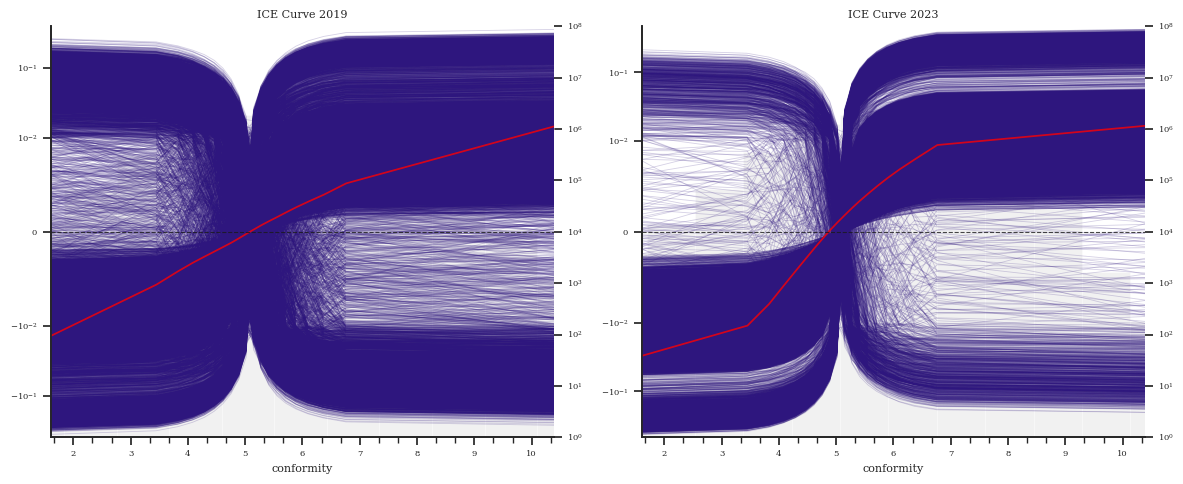

In [26]:
# 创建1×2的图窗
fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1行2列的图窗，尺寸为12×6
estimator = [('RNN_Model',RandomForestRegressor())]
explainer = skexplain.ExplainToolkit(estimator)

# 绘制 RNN_Model_19 的 ALE 和 ICE 曲线

explainer.plot_ale(
    ale=ale_dataset_19,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    ice_curves=ice_dataset_19,
    hist_color = 'lightgrey',
    ice_color = '#2E167E',
    # ice_cmap='cool',
    # color_by='first_values',
    yscale='symlog',
    y_linscale=1.2, # 越小零附近放大越强
    show_colorbar=False, 
    ice_alpha=0.2,
    ice_linewidth=0.6,
    wspace=0.25,
    ax=axs[0]  # 绘制在第一个子图中
)
axs[0].set_title('ICE Curve 2019')  # 设置标题

# 绘制 RNN_Model_23 的 ALE 和 ICE 曲线
explainer.plot_ale(
    ale=ale_dataset_23,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    ice_curves=ice_dataset_23,
    hist_color = 'lightgrey',
    ice_color = '#2E167E',
    # ice_cmap='cool',
    # color_by='first_values',
    yscale='symlog',
    y_linscale=1.2, # 越小零附近放大越强
    show_colorbar=False, 
    ice_alpha=0.2, # 0.05
    ice_linewidth=0.6, #0.1
    # ice_split_threshold = [-0.05,-0.02],
    # ice_alpha=[0.01,0.2],
    # ice_linewidth=[0.05,0.6],
    wspace=0.25,
    ax=axs[1]  # 绘制在第二个子图中
)
axs[1].set_title('ICE Curve 2023')  # 设置标题

# 调整图窗布局
plt.tight_layout()

# 显示图窗
plt.show()

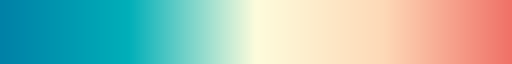

In [6]:
# colors_2 = ["#0081a7", "#00afb9", "#fdfcdc", "#fed9b7", "#f07167"]
colors_2 = ["#0081a7", "#00afb9", "#fdfcdc","#fed9b7", "#f07167"]

# 从颜色列表生成一个连续 colormap 对象
my_cmap_2 = mcolors.LinearSegmentedColormap.from_list("111", colors_2)
my_cmap_2

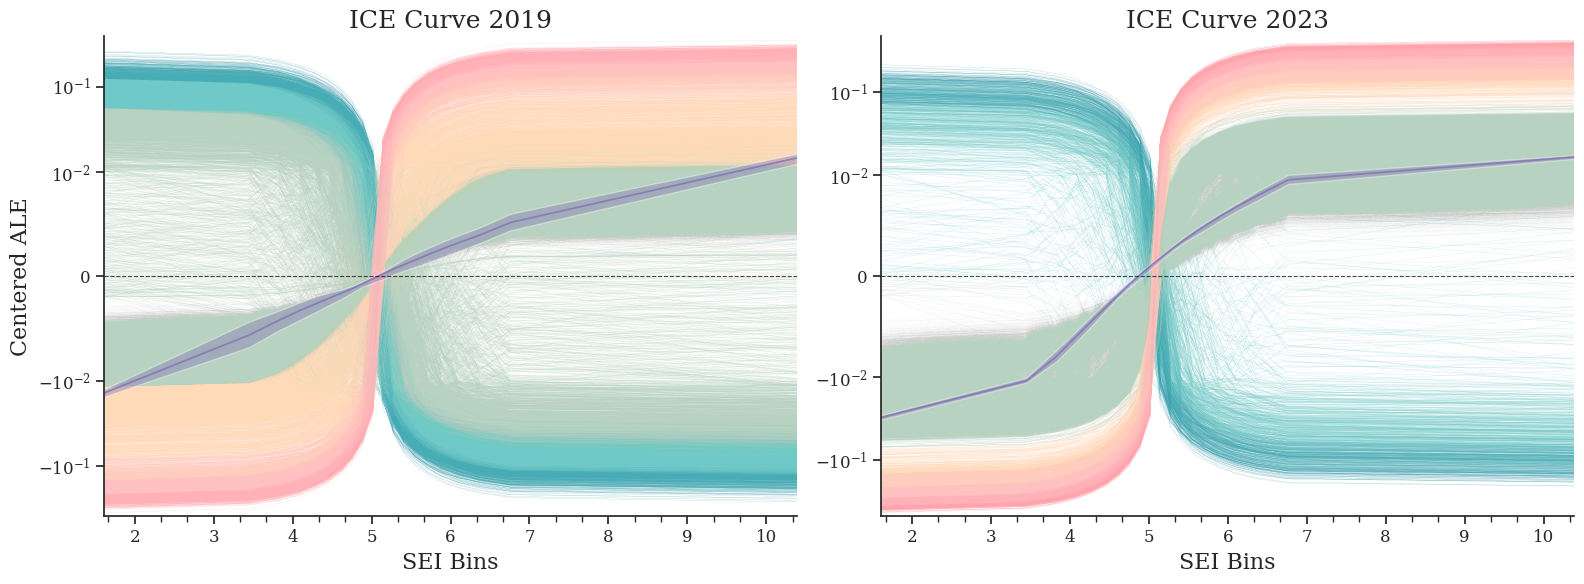

In [35]:
# new_test
# 创建1×2的图窗
fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 1行2列的图窗，尺寸为12×6
estimator = [('RNN_Model',RandomForestRegressor())]
explainer = skexplain.ExplainToolkit(estimator)

# 绘制 RNN_Model_19 的 ALE 和 ICE 曲线
explainer.plot_ale(
    ale=ale_dataset_19,
    features='conformity',  # x轴名字
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    ice_curves=ice_dataset_19,
    line_kws =  {"line_colors": 'm'} ,  # ale曲线颜色
    hist_color = 'w',  # 直方图颜色
    # ice_color = '#2E167E',  # ice曲线颜色
    ice_cmap = my_cmap_6,  # colorbar颜色
    color_by='first_values', # 按哪里的数值着色
    yscale='symlog',
    y_linscale=1.1, # 越小零附近放大越强
    show_colorbar=False, 
    # ice_alpha=0.05,
    # ice_linewidth=0.6,
    ice_split_threshold = [-0.02,-0.002],  # 区间设置
    ice_alpha=[0.9,0.8],  #[区间内透明度，区间外透明度]
    ice_linewidth=[0.0005,0.1],
    wspace=0.15,
    ax=axs[0]  # 绘制在第一个子图中
)
axs[0].set_xlabel('SEI Bins', fontsize=16)
axs[0].set_ylabel('Centered ALE', fontsize=16)
axs[0].set_title('ICE Curve 2019', fontsize=18)  # 设置标题
axs[0].tick_params(axis='x', labelsize=12)          # x 轴刻度字体
axs[0].tick_params(axis='y', labelsize=12) 
ax0_right = get_twinx(axs[0])
if ax0_right:
    ax0_right.set_visible(False) 
    # ax0_right.tick_params(axis='y', labelsize=12)

# 绘制 RNN_Model_23 的 ALE 和 ICE 曲线
explainer.plot_ale(
    ale=ale_dataset_23,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    ice_curves=ice_dataset_23,
    line_kws = {"line_colors":'m'},  # ale曲线颜色
    hist_color = 'w',
    # ice_cmap='cool',
    ice_cmap = my_cmap_6,  # colorbar颜色
    color_by='first_values',
    yscale='symlog',
    y_linscale=1.1, # 越小零附近放大越强
    show_colorbar=False, 
    ice_split_threshold = [-0.02,-0.002],  # 区间设置
    ice_alpha=[0.9,0.8],  #[区间内透明度，区间外透明度]
    ice_linewidth=[0.0002,0.1],
    wspace=0.15,
    ax=axs[1]  # 绘制在第二个子图中
)

axs[1].set_xlabel('SEI Bins', fontsize=16)
axs[1].set_title('ICE Curve 2023', fontsize=18)  # 设置标题
axs[1].tick_params(axis='x', labelsize=12)          # x 轴刻度字体1
axs[1].tick_params(axis='y', labelsize=12) 
ax1_right = get_twinx(axs[1])
if ax1_right:
    ax1_right.set_visible(False) 
    # ax1_right.tick_params(axis='y', labelsize=12)
    # ax1_right.set_ylabel('Histogram Density of SEI', fontsize=16, color='gray')

# 调整图窗布局
plt.tight_layout()

# 显示图窗
plt.show()

## 整图输出

In [24]:
from matplotlib import font_manager as fm
from matplotlib.text import Text

In [25]:
# 统一加 panel 标签
# def panel_label(ax, label, x=-0.10, y=1.05):
#     ax.text(
#         x, y,
#         label,
#         transform=ax.transAxes,
#         fontsize=7,
#         fontweight='bold',
#         fontfamily='sans-serif',
#         va='top',
#         ha='left'
#     )

def panel_label(fig, axes, label, x_offset=0.04, y_offset=0.04):
    
    if not isinstance(axes, (list, tuple)):
        axes = [axes]
        
    bboxes = [ax.get_position() for ax in axes]  # figure 坐标
    x0 = min(b.x0 for b in bboxes)
    y1 = max(b.y1 for b in bboxes)

    fig.text(
        x0 - x_offset,
        y1 + y_offset,
        label,
        fontsize=7,
        fontweight='bold',
        fontfamily='sans-serif',
        ha='left',
        va='top'
    )

panel_label(fig, ax_a, 'a')
panel_label(fig, ax_b, 'b')
panel_label(fig, ax_c, 'c')
panel_label(fig, ax_d0, 'd')

In [26]:
def _get_sans_font(prefer=("Arial", "Helvetica", "Nimbus Sans", "DejaVu Sans")):
    """返回系统中可用的 sans-serif 字体名"""
    available = {f.name for f in fm.fontManager.ttflist}
    for name in prefer:
        if name in available:
            return name
    return None


def enforce_font(
    ax,
    *,
    tick_size=6,
    label_size=7,
    title_size=7,
    text_size=5,
    font_family="sans-serif",
):
    """
    强制统一单个 axes 的字体样式与字号（Nature figure 标准）

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        目标子图
    tick_size : int
        坐标轴刻度字号（推荐 5–6）
    label_size : int
        x/y label 字号（推荐 6–7）
    title_size : int
        title 字号（推荐 6–7）
    font_family : str
        字体族，默认 'sans-serif'
    """

    # 1. 选择具体 sans-serif 字体（避免 backend 默认）
    font_name = _get_sans_font()
    if font_name is not None:
        fp = fm.FontProperties(family=font_family, fname=None, size=tick_size)
        fp.set_family(font_family)
        fp.set_name(font_name)
    else:
        fp = fm.FontProperties(family=font_family, size=tick_size)
    
    def _apply_text(t, size):
        if font_name:
            t.set_fontname(font_name)
        t.set_fontfamily(font_family)
        t.set_fontsize(size)

    # 2. ticks（最容易被 plot_ale 污染的地方）
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        _apply_text(t, tick_size)
        # label.set_fontproperties(fp)
        # label.set_fontsize(tick_size)

    # 3. axis labels
    if ax.xaxis.label.get_text():
        _apply_text(ax.xaxis.label, label_size)
        # ax.xaxis.label.set_fontsize(label_size)
        # ax.xaxis.label.set_fontfamily(font_family)
        # if font_name:
            # ax.xaxis.label.set_fontname(font_name)

    if ax.yaxis.label.get_text():
        _apply_text(ax.yaxis.label, label_size)
        # ax.yaxis.label.set_fontsize(label_size)
        # ax.yaxis.label.set_fontfamily(font_family)
        # if font_name:
        #     ax.yaxis.label.set_fontname(font_name)

    # 4. title
    if ax.title.get_text():
        _apply_text(ax.title, title_size)
        # ax.title.set_fontsize(title_size)
        # ax.title.set_fontfamily(font_family)
        # if font_name:
        #     ax.title.set_fontname(font_name)

    # 5. legend（如果存在）
    leg = ax.get_legend()
    if leg is not None:
        for text in leg.get_texts():
            _apply_text(text, tick_size)
            # text.set_fontsize(tick_size)
            # text.set_fontfamily(font_family)
            # if font_name:
            #     text.set_fontname(font_name)
                
    
    for child in ax.get_children():
        if isinstance(child, Text):
            if child not in (
                ax.title,
                ax.xaxis.label,
                ax.yaxis.label,
            ):
                _apply_text(child, text_size)
                # if font_name:
                #     child.set_fontname(font_name)
                # child.set_fontfamily(font_family)
                # child.set_fontsize(text_size)


In [27]:
for ax in fig.axes:
    enforce_font(ax)
    
ax_d0.set_title(
    'ICE curve before pandemic',
    fontsize=7,
    loc='left',
)

ax_d1.set_title(
    'ICE curve after pandemic',
    fontsize=7,
    loc='left',
)

Text(0.0, 1.0, 'ICE curve after pandemic')

In [28]:
gs.update(hspace=0.27, wspace=0.27)

fig.subplots_adjust(
    left=0.11,
    right=0.98,
    bottom=0.10,
    top=0.94
)

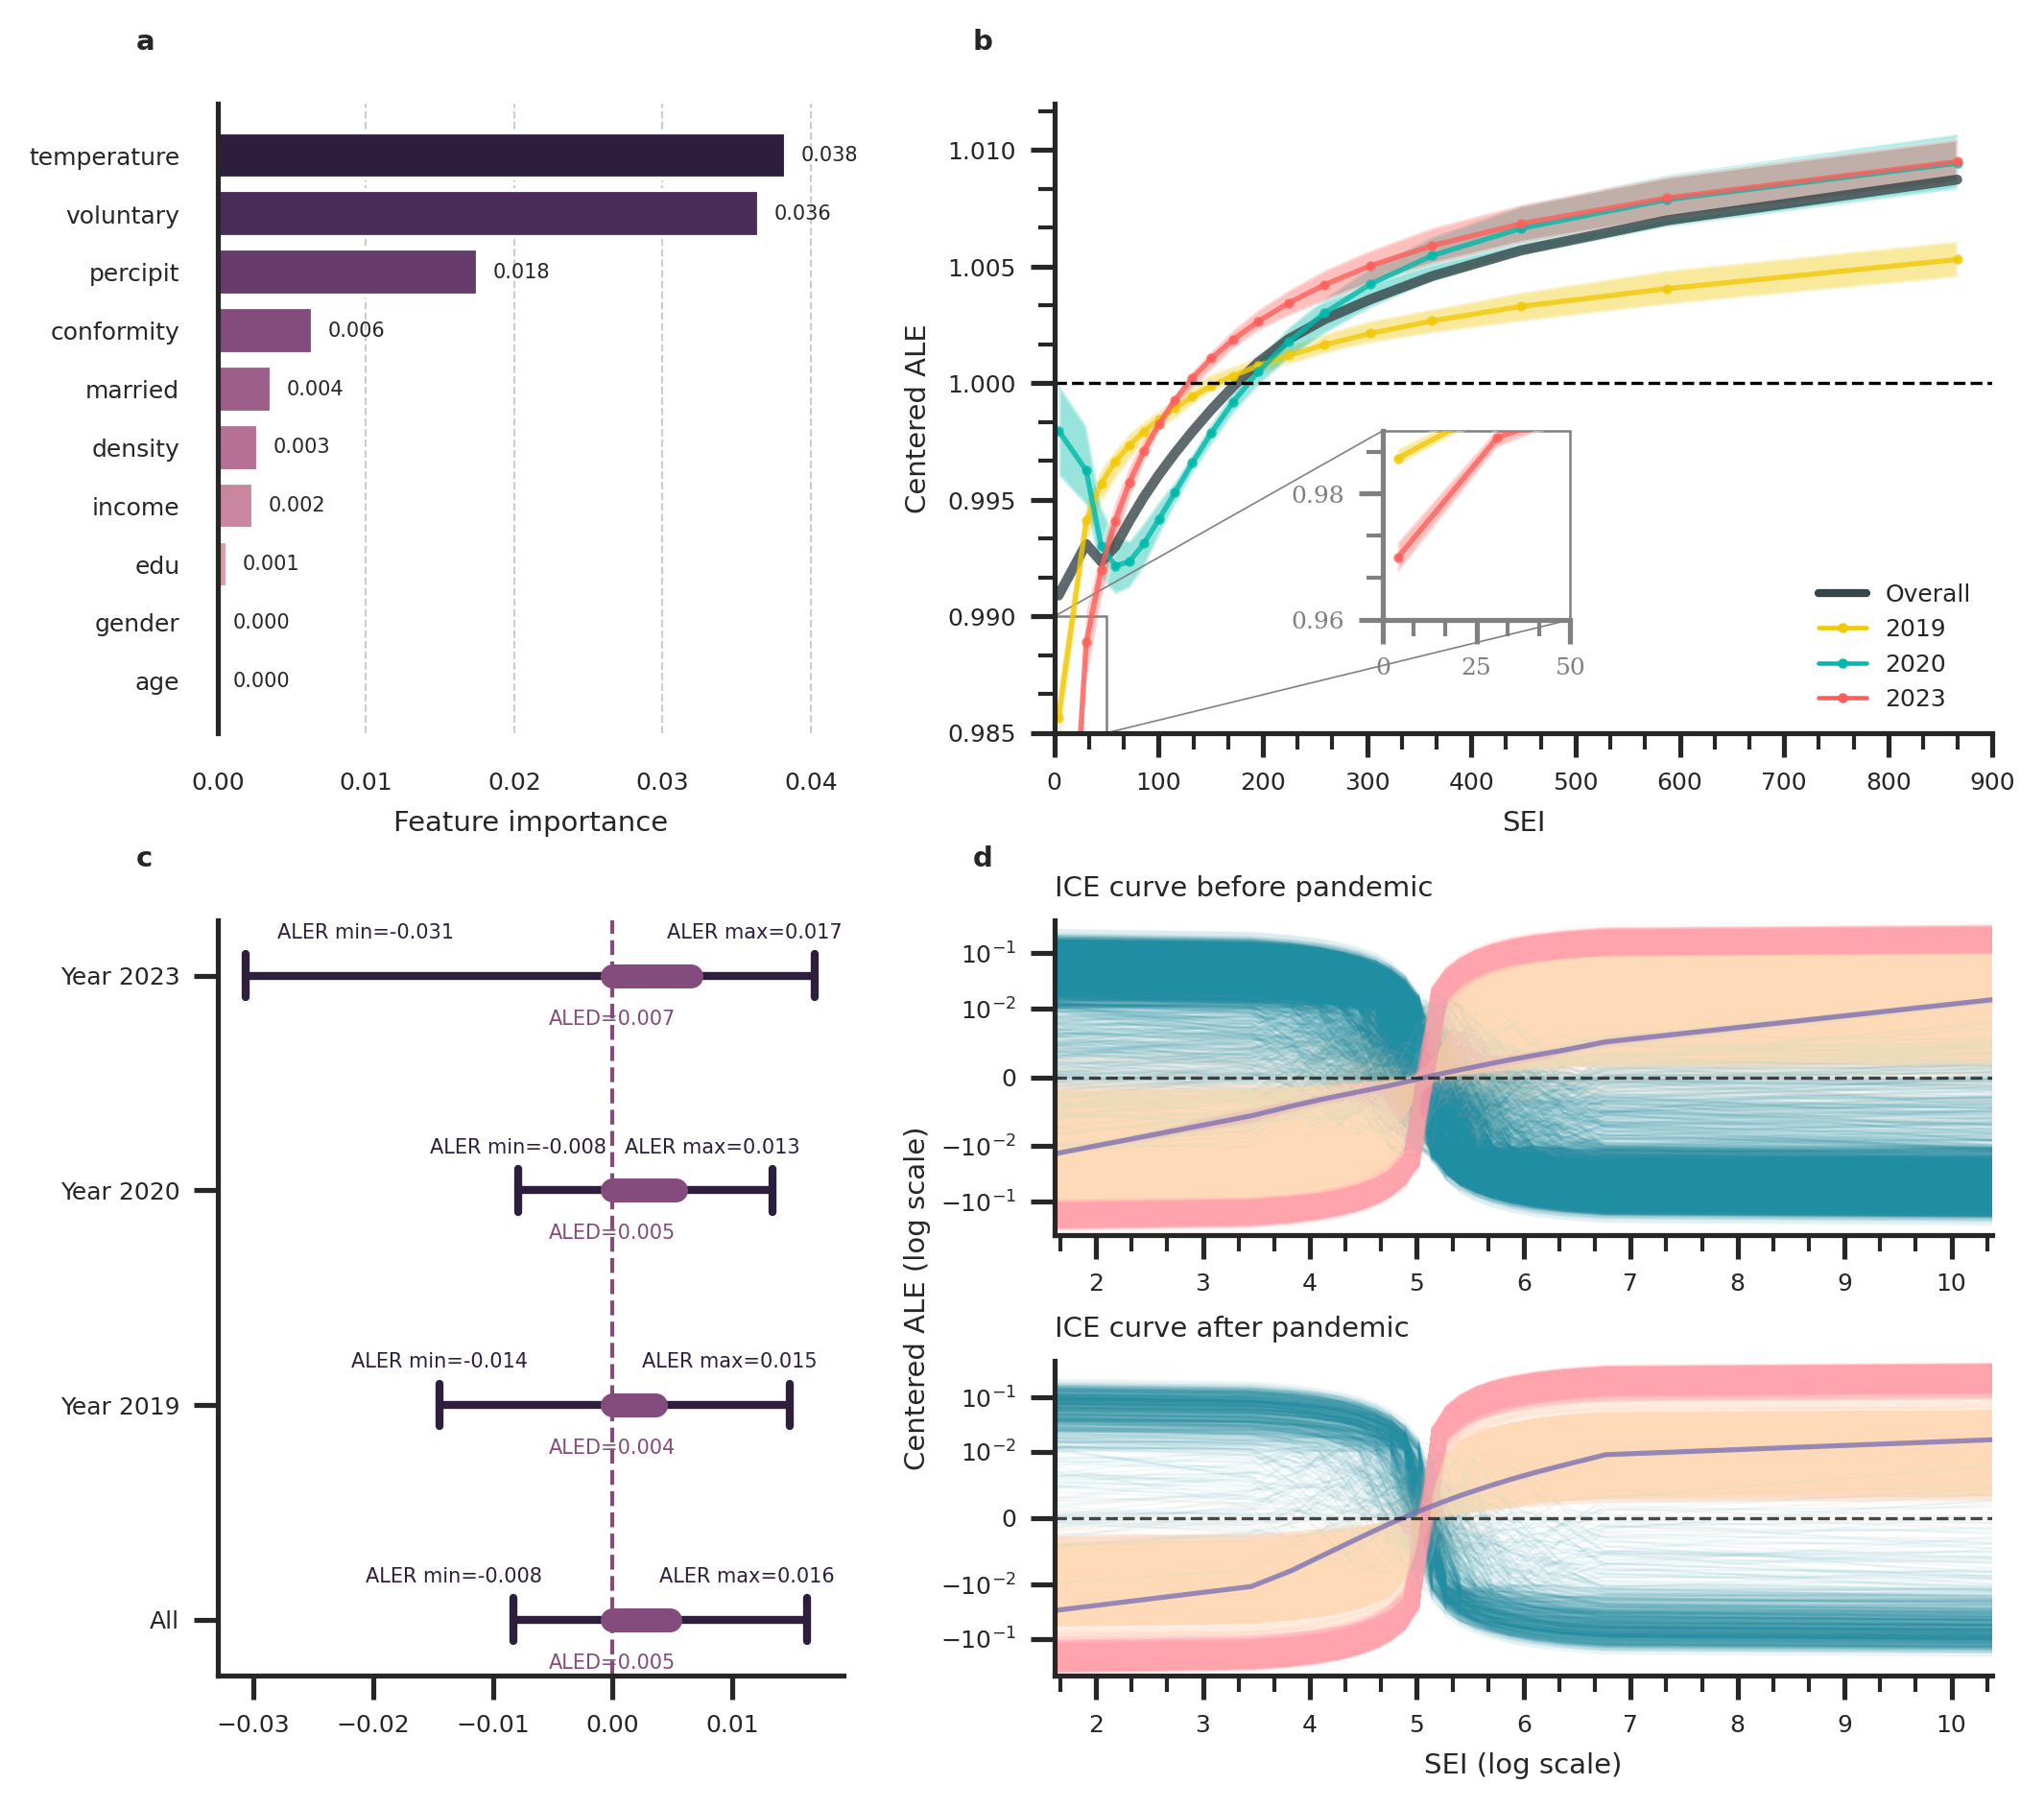

In [28]:
fig

In [29]:
fig.savefig(
    './figures/Fig2_combined_v2.png',
    dpi=300,
    bbox_inches='tight'
)